# **FASE #1: Ingesta y Preprocesamiento Físico**

In [1]:
# 1. Librerías Estándar de Python
import os
import sys
import math
import concurrent.futures
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple, Union

# 2. Análisis de Datos y Cómputo Científico
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, hilbert, welch

# 3. Procesamiento Digital de Señales (Audio)
import librosa
import librosa.display
import soundfile as sf

# 4. Visualización
import matplotlib.pyplot as plt
import seaborn as sns


## **Analisis Exploratorio de Datos**

El estudio consiste en extraer la física y de amortiguamiento real de los impactos a partir del dataset de grabaciones reales de la **Zona Cero** utilizando el transductor piezoeléctrico de contacto **HIKMICRO AD21P**.

1. Métricas de Frecuencia del Golpe (Métrica Rítmica) **Extracción:** La tasa instantánea de golpes por segundo es el recíproco del intervalo (\\(1/\Delta t\\)). Usando funciones vectoriales de NumPy (`np.min`, `np.max`, `np.mean`), calcularemos los valores mínimos, máximos y promedio de la cadencia de la víctima.

2. Métricas Espectrales del Impacto (Tono/Resonancia) **Micro-ventanas de Transitorios:** Para cada onset detectado, extraeremos un segmento temporal muy corto para aislar la colisión rígida del ruido ambiental estacionario de fondo. **Frecuencia Fundamental (\\(f_0\\)):** Emplearemos el estimador de pitch por autocorrelación de alta precisión `librosa.yin`. Restringiremos la búsqueda espectral de forma estricta entre 800 Hz y 7500 Hz. Esto se alinea con la respuesta física real del sensor de contacto (que suprime el siseo e inestabilidad estructural sub-800 Hz) y evitará estimaciones erróneas de pitch debido al ruido estructural. **Distribución del Centroide Espectral:** Calcularemos el centro del espectro frame a frame mediante `librosa.feature.spectral_centroid` exclusivamente en el rango transitorio. Extraeremos el Min, Max y Promedio en Hz para medir el "brillo" y amortiguamiento espectral real del concreto/vigas.

3. Métricas de Amplitud (Dinámica) **Valor de Pico:** Buscaremos el valor absoluto máximo en el dominio del tiempo para cada transitorio: \\(\text{pico} = \text{np.max}(\text{np.abs}(x_{\text{transitorio}}))\\). Convertiremos este valor a escala logarítmica de decibelios fondo de escala:
    \\[\text{Pico}_{\text{dBFS}} = 20 \log_{10}(\text{pico} + 1e-10)\\] **Valor RMS del Golpe:** Calcularemos el valor cuadrático medio frame a frame con `librosa.feature.rms` (o directamente con \\(\text{np.sqrt}(\text{np.mean}(x_{\text{transitorio}}^2))\\)) dentro de la ventana de impacto. **Extracción:** Consolidaremos los valores (Min, Max, Promedio) a través de todos los transitorios válidos detectados.

4. Métricas de Relación Señal/Ruido (SNR)
**Ventana de Señal (\\(S\\)):** Calcularemos el RMS de la porción transitoria de impacto de 35 ms.
**Ventana de Ruido (\\(N\\)):** Definiremos el "valle de silencio" de manera adaptativa. Identificaremos el punto medio temporal exacto entre dos golpes sucesivos (\\((t_i + t_{i+1})/2\\)) y extraeremos una ventana de 50 ms a su alrededor, garantizando el alejamiento físico de la cola de decaimiento del primer golpe y el pre-ataque del segundo.
**Cálculo de SNR:** Aplicaremos la definición en decibelios:
    \\[\text{SNR}_{\text{dB}} = 20 \log_{10}\left(\frac{\text{RMS}_{\text{Señal}}}{\text{RMS}_{\text{Ruido}} + 1e-10}\right)\\]
    
5. Morfología del Transitorio (Tiempo de Decaimiento)
**Extracción de Envolvente:** Para obtener una envolvente de amplitud continua de alta resolución sin el rizado de la fase de audio, utilizaremos la **Transformada de Hilbert** (`scipy.signal.hilbert`) para extraer la amplitud instantánea (magnitud del espectro analítico):
    \\[A[n] = \sqrt{x[n]^2 + \hat{x}[n]^2}\\]
**Medición del Decaimiento:**
    1. Localizaremos el pico máximo de la envolvente \\(A_{\text{max}}\\) (ataque).
    2. Calcularemos el piso de ruido RMS de la ventana de silencio inter-golpe inmediata.
    3. Mediremos el delta de tiempo exacto (en milisegundos) desde el índice del pico hasta el índice de la muestra donde la curva de decaimiento \\(A[n]\\) cruza hacia abajo de forma estable y permanece por debajo de un umbral relativo (por ejemplo, \\(-20\text{ dB}\\) respecto al pico, o el nivel de siseo RMS de fondo). Esto cuantificará científicamente el tiempo de disipación elástica del escombro.


In [2]:
def analizar_y_extraer_verdad_base_impactos(
    ruta_audio: Union[str, Path],
    sr: int = 16000,
    top_db: float = 20.0
) -> Dict[str, Dict[str, float]]:
    """Realiza una auditoría física sobre un audio real de impactos.

    Aplica técnicas de DSP para aislar cada transitorio y cuantificar la morfología temporal,
    dinámica, relación señal-ruido y el decaimiento de energía en el concreto.

    Parameters
    ----------
    ruta_audio : Union[str, Path]
        Ruta del archivo de audio real (.wav) de la Zona Cero a analizar.
    sr : int, optional
        Frecuencia de muestreo en Hz. Por defecto es 16000.
    top_db : float, optional
        Umbral en dB para separar zonas de actividad espectral. Por defecto es 20.0.

    Returns
    -------
    Dict[str, Dict[str, float]]
        Diccionario anidado con estadísticas descriptivas (min, max, promedio)
        de las 5 dimensiones físicas del impacto real.
    """
    path_audio = Path(ruta_audio)

    # Estructura por defecto en caso de que el archivo resulte corrupto o ilegible
    resultado_vacio = {
        "ritmo_impactos_por_segundo": {"min": 0.0, "max": 0.0, "promedio": 0.0},
        "resonancia_f0_hz": {"min": 0.0, "max": 0.0, "promedio": 0.0},
        "centroide_espectral_hz": {"min": 0.0, "max": 0.0, "promedio": 0.0},
        "dinamica_pico_dbfs": {"min": -100.0, "max": -100.0, "promedio": -100.0},
        "dinamica_rms_lineal": {"min": 0.0, "max": 0.0, "promedio": 0.0},
        "relacion_senal_ruido_snr_db": {"min": 0.0, "max": 0.0, "promedio": 0.0},
        "morfologia_decaimiento_ms": {"min": 0.0, "max": 0.0, "promedio": 0.0}
    }

    try:
        # 1. Ingesta y Acondicionamiento (Remuestreo forzado a mono, 16 kHz)
        y, _ = librosa.load(path_audio, sr=sr, mono=True)
        if len(y) == 0:
            print(f"[ADVERTENCIA] Archivo de audio vacio: {path_audio.name}")
            return resultado_vacio

        # 2. Localización de Transitorios mediante Diferencia Espectral
        onset_frames = librosa.onset.onset_detect(
            y=y,
            sr=sr,
            backtrack=True,
            hop_length=160,
            wait=10,        # Ignora cualquier otro golpe durante los siguientes 10 ms
            delta=0.05      # Filtra fluctuaciones menores de ruido
        )

        onset_samples = librosa.frames_to_samples(onset_frames, hop_length=160)
        onset_times = librosa.frames_to_time(onset_frames, sr=sr, hop_length=160)
        num_impactos = len(onset_samples)

        if num_impactos == 0:
            print(f"[ADVERTENCIA] No se detectaron transitorios en: {path_audio.name}")
            return resultado_vacio

        # 3. Métrica de Frecuencia del Golpe 
        if num_impactos > 1:
            intervalos_segundos = np.diff(onset_times)
            intervalos_validos = intervalos_segundos[intervalos_segundos > 0.08]

            if len(intervalos_validos) > 0:
                tasas_ritmo = 1.0 / intervalos_validos
                ritmo_min = float(np.min(tasas_ritmo))
                ritmo_max = float(np.max(tasas_ritmo))
                ritmo_mean = float(np.mean(tasas_ritmo))
            else:
                ritmo_min, ritmo_max, ritmo_mean = 0.0, 0.0, 0.0
        else:
            ritmo_min, ritmo_max, ritmo_mean = 0.0, 0.0, 0.0

        muestra_transitorio = int(0.10 * sr)

        f0_totales = []
        centroides_totales = []
        picos_dbfs_totales = []
        rms_lineales_totales = []
        snr_db_totales = []
        decaimiento_ms_totales = []

        # 4. Análisis Segmentado por Impacto Individual
        for i, idx in enumerate(onset_samples):
            limite_superior = min(idx + muestra_transitorio, len(y))
            transitorio = y[idx:limite_superior]

            # Descartar segmentos residuales excesivamente cortos
            if len(transitorio) < int(0.04 * sr):  # Mínimo de 40 ms requerido
                continue

            # A. Métricas de Amplitud (Dinámica)
            pico_abs = np.max(np.abs(transitorio))
            pico_dbfs = 20 * np.log10(pico_abs + 1e-10)
            rms_transitorio = np.sqrt(np.mean(transitorio ** 2) + 1e-10)

            picos_dbfs_totales.append(pico_dbfs)
            rms_lineales_totales.append(rms_transitorio)

            # B. Métricas Espectrales (Pitch acotado a la banda segura del HIKMICRO AD21P)
            f0_yin = librosa.yin(
                transitorio,
                fmin=150.0,
                fmax=7500.0,
                sr=sr,
                hop_length=160
            )
            f0_validos = f0_yin[np.isfinite(f0_yin)]
            if len(f0_validos) > 0:
                f0_totales.append(float(np.mean(f0_validos)))

            centroide = librosa.feature.spectral_centroid(y=transitorio, sr=sr, hop_length=160)
            centroides_totales.append(float(np.mean(centroide)))

            # C. Relación Señal/Ruido Adaptativa (SNR)
            if i < num_impactos - 1:
                idx_siguiente = onset_samples[i + 1]
                punto_medio = (idx + idx_siguiente) // 2
                inicio_ruido = max(idx + int(0.05 * sr), punto_medio - int(0.025 * sr))
                fin_ruido = min(idx_siguiente - int(0.01 * sr), inicio_ruido + int(0.05 * sr))
            else:
                # Si es el último transitorio, se evalúa en el extremo final de la señal
                inicio_ruido = max(0, len(y) - int(0.10 * sr))
                fin_ruido = len(y)

            if fin_ruido > inicio_ruido:
                ventana_ruido = y[inicio_ruido:fin_ruido]
                rms_ruido = np.sqrt(np.mean(ventana_ruido ** 2) + 1e-10)
                snr_calculada = 20 * np.log10(rms_transitorio / rms_ruido)
                snr_db_totales.append(snr_calculada)

            # D. Morfología del Transitorio 
            len_env = min(int(0.15 * sr), len(y) - idx)
            segmento_envolvente = y[idx : idx + len_env]

            if len(segmento_envolvente) > 10:
                env_analitica = np.abs(hilbert(segmento_envolvente))

                idx_pico_env = np.argmax(env_analitica)
                amplitud_maxima = env_analitica[idx_pico_env]

                umbral_disipacion = max(amplitud_maxima * 0.10, rms_transitorio * 0.15)

                idx_disipado = len_env - 1
                for k in range(idx_pico_env, len_env):
                    if env_analitica[k] < umbral_disipacion:
                        estabilidad_idx = min(len_env, k + int(0.005 * sr))
                        if np.all(env_analitica[k:estabilidad_idx] < umbral_disipacion):
                            idx_disipado = k
                            break

                tiempo_decaimiento_ms = ((idx_disipado - idx_pico_env) / sr) * 1000.0
                decaimiento_ms_totales.append(tiempo_decaimiento_ms)

        # 5. Estadística de Métricas
        def resumir_datos(datos: List[float], default_val: float = 0.0) -> Dict[str, float]:
            if not datos:
                return {"min": default_val, "max": default_val, "promedio": default_val}
            return {
                "min": float(np.min(datos)),
                "max": float(np.max(datos)),
                "promedio": float(np.mean(datos))
            }

        return {
            "ritmo_impactos_por_segundo": {"min": ritmo_min, "max": ritmo_max, "promedio": ritmo_mean},
            "resonancia_f0_hz": resumir_datos(f0_totales, 0.0),
            "centroide_espectral_hz": resumir_datos(centroides_totales, 0.0),
            "dinamica_pico_dbfs": resumir_datos(picos_dbfs_totales, -100.0),
            "dinamica_rms_lineal": resumir_datos(rms_lineales_totales, 0.0),
            "relacion_senal_ruido_snr_db": resumir_datos(snr_db_totales, 0.0),
            "morfologia_decaimiento_ms": resumir_datos(decaimiento_ms_totales, 0.0)
        }

    except Exception as e:
        print(f"[ERROR CRÍTICO] Fallo en el análisis físico de {path_audio.name}: {str(e)}")
        return resultado_vacio


### **BLOQUE: Parseo y Unificación**

Este índice (en formato Pandas DataFrame) actuará como el mapa que el `DataLoader` de PyTorch consultará iterativamente para cargar, aplicar transformaciones y enviar los tensores a la GPU de manera eficiente.


In [3]:
LABEL_MAP = {
    "Noise_General": 0,
    "Target_Animal": 1,
    "Target_Rhythmic": 2,
    "Target_Voice": 3
}

def parsear_y_unificar_datasets(lista_directorios_raiz: List[Union[str, Path]]) -> pd.DataFrame:
    """
    Escanea recursivamente una lista de directorios raiz para indexar tensores de audio.

    Parameters
    ----------
    lista_directorios_raiz : List[Union[str, Path]]
        Lista de rutas (strings o objetos Path) correspondientes a las carpetas
        raiz de los datasets (ej. ['dataset_preprocesado', 'Dataset_Feedback']).

    Returns
    -------
    pd.DataFrame
        DataFrame estructurado con las columnas: 'ruta_absoluta', 'dataset_origen',
        'categoria' y 'label_idx'. Retorna un DataFrame vacio si no hay coincidencias.
    """
    datos_indexados = []

    for directorio in lista_directorios_raiz:
        ruta_raiz = Path(directorio)

        # Validacion de existencia del directorio
        if not ruta_raiz.exists() or not ruta_raiz.is_dir():
            print(f"[ADVERTENCIA] El directorio raiz especificado no existe o no es valido: {ruta_raiz}")
            continue

        # Busqueda recursiva de archivos .wav
        for archivo_wav in ruta_raiz.rglob('*.wav'):
            if not archivo_wav.is_file():
                continue

            try:
                # Extraccion de metadatos desde la estructura del arbol de directorios
                categoria = archivo_wav.parent.name
                dataset_origen = archivo_wav.parent.parent.name

                # Validacion estricta contra la taxonomia aprobada
                if categoria not in LABEL_MAP:
                    print(f"[ADVERTENCIA] Categoria anomala '{categoria}' detectada en {archivo_wav.name}. Archivo ignorado.")
                    continue

                # Resolucion de ruta absoluta para evitar punteros rotos en el DataLoader
                ruta_absoluta = str(archivo_wav.resolve())
                label_idx = LABEL_MAP[categoria]

                datos_indexados.append({
                    "ruta_absoluta": ruta_absoluta,
                    "dataset_origen": dataset_origen,
                    "categoria": categoria,
                    "label_idx": label_idx
                })

            except Exception as e:
                # Captura de errores de lectura de pathing o permisos
                print(f"[ADVERTENCIA] Error procesando el archivo {archivo_wav}: {str(e)}")
                continue

    df_unificado = pd.DataFrame(datos_indexados, columns=[
        "ruta_absoluta",
        "dataset_origen",
        "categoria",
        "label_idx"
    ])

    return df_unificado


### **BLOQUE: Analisis Grafico de los datasets antes de procesar**

1. **RMS (Root Mean Square):** Mide la potencia cuadrática media acumulada a lo largo del tiempo. En lugar de extraer un solo promedio escalar global, se calcula de manera segmentada frame a frame (ventana de 25 ms / paso de 10 ms, equivalente a 400 muestras de ventana y 160 muestras de salto a 16 kHz) para retener las firmas de energía del Código Morse o los formantes de voz.
2. **ZCR (Zero Crossing Rate) :** Determina la tasa de cambio de signo en el dominio temporal. Es el descriptor físico por excelencia para separar el ruido percusivo de concreto friccionando (ZCR muy elevado) de la voz humana (ZCR bajo con periodicidad armónica) .
3. **PSD (Power Spectral Density):** Representa la distribución de la potencia de la señal sobre el espectro de frecuencias. Para una estimación robusta con baja varianza estadística, se implementa el **Método de Welch** (`scipy.signal.welch`) aplicando ventanas de Hann con un solapamiento del 50%.
4. **Espectrograma de Mel:** Convierte el espectro lineal obtenido por FFT a la escala logarítmica de Mel. Se parametrizan exactamente 128 filtros Mel acotando el espectro de transmisión del transductor piezoeléctrico HIKMICRO AD21P, configurando la frecuencia mínima en 150 Hz y la máxima en 7500 Hz . El tensor bidimensional resultante se normaliza a escala logarítmica de decibelios (dB).

In [4]:
def procesar_un_audio_crudo(args: Tuple[str, str]) -> Optional[Tuple[str, "MuestraAcusticaEDA"]]:
    """Extrae descriptores DSP de audios crudos estandarizando su longitud a 4.0s.

    A diferencia de la Fase 1, este bloque NO aplica el simulador AD21P ni inyecta
    ruido ambiental. Extrae la señal pura limitándola a 64,000 muestras para
    garantizar la compatibilidad matricial con el Dashboard EDA de la Fase 2.
    """
    ruta_str, categoria = args
    ruta_path = Path(ruta_str)

    try:
        # 1. Carga cruda a 16 kHz Mono
        y, sr = librosa.load(ruta_path, sr=16000, mono=True)

        # 2. Estandarización Matricial para el Dashboard (4.0 Segundos = 64,000 muestras)
        target_len = int(4.0 * sr)
        if len(y) > target_len:
            y = y[:target_len] # Truncado de señal original
        else:
            y = np.pad(y, (0, target_len - len(y)), mode='constant') # Zero-padding pasivo

        n_fft_param = 400
        hop_length_param = 160

        # 3. Extracción de Descriptores DSP Puros
        rms = np.squeeze(librosa.feature.rms(y=y, frame_length=n_fft_param, hop_length=hop_length_param))
        zcr = np.squeeze(librosa.feature.zero_crossing_rate(y=y, frame_length=n_fft_param, hop_length=hop_length_param))
        _, psd = welch(y, fs=sr, nperseg=1024)

        mels_raw = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=hop_length_param, n_mels=128, fmin=150.0, fmax=7500.0
        )
        mels_db = librosa.power_to_db(mels_raw, ref=np.max)

        muestra = MuestraAcusticaEDA(
            ruta_absoluta=str(ruta_path.resolve()),
            rms=rms.astype(np.float32),
            zcr=zcr.astype(np.float32),
            psd=psd.astype(np.float32),
            mels=mels_db.astype(np.float32)
        )
        return categoria, muestra

    except Exception as e:
        print(f"[AVISO] Fallo al analizar audio crudo {ruta_path.name}: {e}")
        return None

def ejecutar_eda_linea_base(rutas_crudas: List[Union[str, Path]], n_muestras: int = 50) -> None:
    """Genera un DataFrame temporal y extrae los tensores utilizando la arquitectura
    multinúcleo, para luego reutilizar el renderizador de la Fase 2 y generar
    el Dashboard.
    """
    print("\n" + "="*60)
    print(" FASE 0: ANÁLISIS EXPLORATORIO DE LÍNEA BASE (CRUDO)")
    print("="*60)

    datos = []
    for directorio in rutas_crudas:
        ruta_raiz = Path(directorio)

        for archivo in ruta_raiz.rglob('*'):
            if archivo.is_file() and archivo.suffix.lower() in [".wav", ".mp3"]:

                categoria = archivo.parent.name

                dataset_origen = archivo.parent.parent.name

                if categoria in CATEGORIAS_TAXONOMIA:
                    datos.append({
                        "ruta_absoluta": str(archivo.resolve()),
                        "dataset_origen": dataset_origen,
                        "categoria": categoria,
                        "label_idx": LABEL_MAP[categoria]
                    })

    df_crudo = pd.DataFrame(datos)
    if df_crudo.empty:
        print("[ERROR] No se encontraron audios crudos que coincidan con la taxonomía.")
        return

    print(f"[INFO] Se indexaron {len(df_crudo)} audios crudos. Extrayendo descriptores...")

    # 2. Muestreo Estratificado
    audios_a_procesar = []
    for categoria in CATEGORIAS_TAXONOMIA:
        df_cat = df_crudo[df_crudo["categoria"] == categoria]
        if not df_cat.empty:
            df_sample = df_cat.sample(n=min(n_muestras, len(df_cat)), random_state=42)
            for _, fila in df_sample.iterrows():
                audios_a_procesar.append((fila["ruta_absoluta"], categoria))

    # 3. Extracción Multinúcleo
    reporte_crudo = ReporteEstadisticoEDA()
    with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
        resultados = executor.map(procesar_un_audio_crudo, audios_a_procesar)
        for res in resultados:
            if res is not None:
                cat_res, muestra = res
                reporte_crudo.datos_por_categoria[cat_res].append(muestra)

    # 4. Invocación del Motor Gráfico de la Fase 2
    print("[INFO] Renderizando Dashboards de Línea Base...")

    # Renderizamos la vista cruda
    renderizar_dashboard_eda(df_crudo, reporte_crudo, titulo_contexto="GLOBAL", tag_fase="CRUDO")

    # Renderizamos granularmente por origen crudo
    explorar_dashboards_por_dataset(df_crudo, reporte_crudo, tag_fase="CRUDO")

    print("[ÉXITO] EDA de Línea Base completado. Proceda con la Fase 1 de Preprocesamiento.")

### **BLOQUE: Analisis Grafico de los datasets despues de procesar**

In [5]:
# Listado estricto de las 6 categorias de la taxonomia del sistema
CATEGORIAS_TAXONOMIA: List[str] = [
    "Noise_General",
    "Target_Animal",
    "Target_Rhythmic",
    "Target_Voice"
]


@dataclass
class MuestraAcusticaEDA:
    """Clase de datos para almacenar los tensores procesados de un audio individual."""

    ruta_absoluta: str
    rms: np.ndarray    # Vector 1D (energia en el tiempo)
    zcr: np.ndarray    # Vector 1D (tasa de cruces por cero en el tiempo)
    psd: np.ndarray    # Vector 1D (densidad espectral de potencia)
    mels: np.ndarray   # Matriz 2D (espectrograma de Mel en decibelios: 128 x columnas)


@dataclass
class ReporteEstadisticoEDA:
    """Contenedor unificado para organizar las muestras procesadas por categoria."""

    datos_por_categoria: Dict[str, List[MuestraAcusticaEDA]] = field(
        default_factory=lambda: {cat: [] for cat in CATEGORIAS_TAXONOMIA}
    )


def procesar_un_audio(args: Tuple[str, str]) -> Optional[Tuple[str, MuestraAcusticaEDA]]:
    """Trabajador (worker) para cargar y calcular tensores en RAM en un subproceso.

    Parameters
    ----------
    args : Tuple[str, str]
        Contiene la ruta absoluta del archivo .wav y su categoria asignada.

    Returns
    -------
    Optional[Tuple[str, MuestraAcusticaEDA]]
        Tupla con la categoria del audio y el objeto de datos procesado,
        o None si el archivo esta corrupto o es ilegible.
    """
    ruta_str, categoria = args
    ruta_path = Path(ruta_str)

    try:
        # Cargar audio forzando muestreo a 16 kHz y un solo canal (MONO)
        y, sr = librosa.load(ruta_path, sr=16000, mono=True)

        # Longitud de ventana de 25 ms (400 muestras) y salto de 10 ms (160 muestras)
        n_fft_param = 400
        hop_length_param = 160

        # 1. Extraccion de RMS (Root Mean Square) - Vector 1D
        rms_raw = librosa.feature.rms(y=y, frame_length=n_fft_param, hop_length=hop_length_param)
        rms = np.squeeze(rms_raw)

        # 2. Extraccion de ZCR (Zero Crossing Rate) - Vector 1D
        zcr_raw = librosa.feature.zero_crossing_rate(y=y, frame_length=n_fft_param, hop_length=hop_length_param)
        zcr = np.squeeze(zcr_raw)

        # 3. Calculo de PSD (Power Spectral Density) 
        # f: frecuencias estimadas, psd: densidad espectral (vector 1D)
        # nperseg=1024 garantiza una resolucion espectral de 15.6 Hz por bin
        _, psd = welch(y, fs=sr, nperseg=1024)

        # 4. Espectrograma de Mel - Matriz 2D (128 bandas Mel de 150 a 7500 Hz)
        mels_raw = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=1024,
            hop_length=hop_length_param,
            n_mels=128,
            fmin=150.0,
            fmax=7500.0
        )
        # Conversion a decibelios utilizando el maximo de energia de referencia
        mels_db = librosa.power_to_db(mels_raw, ref=np.max)

        # Consolidacion de datos en float32 para optimizar la transferencia a la GPU
        muestra_procesada = MuestraAcusticaEDA(
            ruta_absoluta=str(ruta_path.resolve()),
            rms=rms.astype(np.float32),
            zcr=zcr.astype(np.float32),
            psd=psd.astype(np.float32),
            mels=mels_db.astype(np.float32)
        )

        return categoria, muestra_procesada

    except Exception as e:
        print(f"[ADVERTENCIA] Archivo corrupto omitido en disco: {ruta_path.name}. Motivo: {str(e)}")
        return None


def extraer_muestra_estadistica_eda(
    df_unificado: pd.DataFrame,
    n_muestras_por_clase: int = 50
) -> ReporteEstadisticoEDA:
    """Extrae de manera estratificada y en paralelo descriptores DSP para analisis EDA.

    Parameters
    ----------
    df_unificado : pd.DataFrame
        DataFrame de Pandas indexado con las columnas:
        - "ruta_absoluta"
        - "dataset_origen"
        - "categoria"
        - "label_idx"
    n_muestras_por_clase : int, optional
        Numero maximo de muestras aleatorias a extraer por categoria.
        Por defecto es 50.

    Returns
    -------
    ReporteEstadisticoEDA
        Contenedor estructurado con arrays NumPy listos para su visualizacion.

    Raises
    ------
    KeyError
        Si el DataFrame recibido carece de las columnas estructurales basicas.
    """
    columnas_requeridas = {"ruta_absoluta", "categoria"}
    if not columnas_requeridas.issubset(df_unificado.columns):
        raise KeyError(
            f"El DataFrame debe contener estrictamente las columnas: {columnas_requeridas}. "
            f"Columnas recibidas: {list(df_unificado.columns)}"
        )

    # 1. Muestreo Estratificado
    audios_a_procesar: List[Tuple[str, str]] = []

    for categoria in CATEGORIAS_TAXONOMIA:
        df_categoria = df_unificado[df_unificado["categoria"] == categoria]
        total_disponibles = len(df_categoria)

        if total_disponibles == 0:
            print(f"[ADVERTENCIA] No se encontraron archivos para la categoria: {categoria}")
            continue

        # Determinar el limite superior del sample para evitar desbordamientos de indices
        sample_size = min(n_muestras_por_clase, total_disponibles)
        df_sample = df_categoria.sample(n=sample_size, random_state=42)

        for _, fila in df_sample.iterrows():
            audios_a_procesar.append((str(fila["ruta_absoluta"]), categoria))

    # 2. Orquestacion en Paralelo utilizando hilos y procesos
    reporte = ReporteEstadisticoEDA()

    #with concurrent.futures.ProcessPoolExecutor() as executor: # LINUX
    with concurrent.futures.ThreadPoolExecutor(max_workers=12) as executor: # WINDOWS
        resultados = executor.map(procesar_un_audio, audios_a_procesar)

        for res in resultados:
            if res is not None:
                categoria_res, muestra = res
                reporte.datos_por_categoria[categoria_res].append(muestra)

    return reporte

def explorar_dashboards_por_dataset(df_unificado: pd.DataFrame, reporte_eda: "ReporteEstadisticoEDA", tag_fase: str = "") -> None:
    """Itera sobre los datasets de origen y renderiza un dashboard independiente para cada uno.
    """
    datasets_unicos = df_unificado['dataset_origen'].unique()
    print(f"\n[EDA] Iniciando exploración granular para {len(datasets_unicos)} datasets: {datasets_unicos}")

    for dataset_nombre in datasets_unicos:
        print(f"Extrayendo y renderizando vistas para Dataset: [{dataset_nombre.upper()}]...")

        # 1. Filtrar el DataFrame
        df_filtrado = df_unificado[df_unificado['dataset_origen'] == dataset_nombre].copy()

        if df_filtrado.empty:
            continue

        # 2. Filtrar el Reporte DSP
        rutas_dataset = set(df_filtrado['ruta_absoluta'].values)
        reporte_filtrado = ReporteEstadisticoEDA()

        for cat, muestras in reporte_eda.datos_por_categoria.items():
            muestras_filtradas = [m for m in muestras if m.ruta_absoluta in rutas_dataset]
            reporte_filtrado.datos_por_categoria[cat] = muestras_filtradas

        # 3. Renderizar utilizando la función existente adaptada
        renderizar_dashboard_eda(
            df_unificado=df_filtrado,
            reporte_eda=reporte_filtrado,
            titulo_contexto=f"DATASET: {dataset_nombre.upper()}",
            tag_fase=tag_fase
        )

### **BLOQUE: Graficos de caja e histograma**

In [6]:
def graficar_distribuciones_verdad_base(df: pd.DataFrame) -> None:
    """Genera histogramas y diagramas de caja para analizar la distribución
    de los promedios acústicos extraídos del hardware real, organizados
    en una cuadrícula optimizada de 3 columnas.
    """
    if df.empty:
        print("[ERROR] El DataFrame proporcionado está vacío.")
        return

    # 1. Definición de las variables promedio a graficar
    columnas_avg = [
        "Cadencia_Avg",
        "Resonancia_F0_Hz_Avg",
        "Centroide_Hz_Avg",
        "Pico_dBFS_Avg",
        "RMS_Lineal_Avg",
        "SNR_dB_Avg",
        "Decaimiento_ms_Avg"
    ]

    # Validar que las columnas existan en el DataFrame
    columnas_validas = [col for col in columnas_avg if col in df.columns]
    num_vars = len(columnas_validas)

    if num_vars == 0:
        print("[ERROR] No se encontraron las columnas '_Avg' en el DataFrame.")
        return

    sns.set_theme(style="darkgrid", context="paper")

    # 2. Cálculos para la cuadrícula matricial (3 por fila)
    ncols = 3
    nrows = math.ceil(num_vars / ncols)

    # FIGURA 1: HISTOGRAMAS (Distribución de Frecuencias y Densidad)
    fig_hist, axes_hist = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3.5 * nrows))
    fig_hist.suptitle(
        "DISTRIBUCIÓN DE DENSIDAD (HISTOGRAMAS) - MÉTRICAS PROMEDIO (AD21P)",
        fontsize=14,
        fontweight="bold",
        y=0.98
    )

    # Aplanar la matriz de ejes para iterar linealmente
    axes_hist_flat = axes_hist.flatten()

    for i, col in enumerate(columnas_validas):
        ax = axes_hist_flat[i]
        sns.histplot(data=df, x=col, kde=True, ax=ax, color="steelblue", bins=15, alpha=0.7)
        ax.set_title(f"Distribución: {col}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Valor Medido", fontsize=9)
        ax.set_ylabel("Frecuencia", fontsize=9)

    # Limpieza: Eliminar los subplots sobrantes 
    for j in range(i + 1, len(axes_hist_flat)):
        fig_hist.delaxes(axes_hist_flat[j])

    fig_hist.tight_layout(rect=[0, 0, 1, 0.96])

    # FIGURA 2: BOXPLOTS (Dispersión Vertical)
    fig_box, axes_box = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4.5 * nrows))
    fig_box.suptitle(
        "ANÁLISIS DE DISPERSIÓN (BOXPLOTS VERTICALES) - MÉTRICAS PROMEDIO (AD21P)",
        fontsize=14,
        fontweight="bold",
        y=0.98
    )

    axes_box_flat = axes_box.flatten()

    for i, col in enumerate(columnas_validas):
        ax = axes_box_flat[i]
        # Boxplot vertical: variable asignada al eje 'y' y orient="v"
        sns.boxplot(data=df, y=col, ax=ax, color="mediumseagreen", orient="v", fliersize=5)
        ax.set_title(f"Dispersión: {col}", fontsize=10, fontweight="bold")
        ax.set_ylabel("Rango de Valores", fontsize=9)

    # Limpieza de subplots sobrantes
    for j in range(i + 1, len(axes_box_flat)):
        fig_box.delaxes(axes_box_flat[j])

    fig_box.tight_layout(rect=[0, 0, 1, 0.96])

    # GUARDADO Y DESPLIEGUE
    plt.show(block=False)
    print("[INFO] Renderizado matricial de lienzos estadísticos completado.")



### **BLOQUE: Renderizado y Human in the Loop**

In [7]:
# Taxonomía unificada de 6 clases para la Fase 2 del sistema USAR V2.0
CATEGORIAS_TAXONOMIA: List[str] = [
    "Noise_General",
    "Target_Animal",
    "Target_Rhythmic",
    "Target_Voice"
]

def renderizar_dashboard_eda(df_unificado: pd.DataFrame, reporte_eda: "ReporteEstadisticoEDA", titulo_contexto: str = "GLOBAL", tag_fase: str = "") -> None:
    """Genera y muestra un dashboard multipanel para auditoría de calidad de datos."""

    # Configuración de estética visual para entornos s de campo
    plt.style.use('dark_background')

    # FIGURA 1: PANEL DE ESTADÍSTICAS GLOBALES Y BARRERA ESPECTRAL
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f"AUDITORIA DSP - {titulo_contexto}", fontsize=16, fontweight="bold")
    ax_dist = axes[0]
    ax_zcr = axes[1]
    ax_psd = axes[2]

    # Panel A: Distribución de Clases
    sns.countplot(
        x="categoria",
        data=df_unificado,
        ax=ax_dist,
        order=CATEGORIAS_TAXONOMIA,
        hue="categoria",
        legend=False,
        palette="viridis"
    )
    ax_dist.set_title("Distribucion de Clases (Nivel de Desbalance)", fontsize=12, fontweight="bold")
    ax_dist.set_xlabel("Categoria Taxonomica", fontsize=10)
    ax_dist.set_ylabel("Cantidad de Muestras", fontsize=10)
    ax_dist.tick_params(axis='x', rotation=30)
    ax_dist.grid(True, linestyle="--", alpha=0.2)

    # Panel B: Separabilidad Física por Tasa de Cruces por Cero (ZCR Medio)
    zcr_data = []
    for cat in CATEGORIAS_TAXONOMIA:
        muestras = reporte_eda.datos_por_categoria.get(cat, [])
        for m in muestras:
            zcr_data.append({
                "Categoria": cat,
                "ZCR_Medio": float(np.mean(m.zcr))
            })
    df_zcr = pd.DataFrame(zcr_data)

    if not df_zcr.empty:
        sns.boxplot(
            x="Categoria",
            y="ZCR_Medio",
            data=df_zcr,
            ax=ax_zcr,
            order=CATEGORIAS_TAXONOMIA,
            hue="Categoria",
            legend=False,
            palette="muted"
        )
    ax_zcr.set_title("Tasa de Cruces por Cero (ZCR Medio) por Clase", fontsize=12, fontweight="bold")
    ax_zcr.set_xlabel("Categoria Taxonomica", fontsize=10)
    ax_zcr.set_ylabel("ZCR Promedio (Cruces/Frame)", fontsize=10)
    ax_zcr.tick_params(axis='x', rotation=30)
    ax_zcr.grid(True, linestyle="--", alpha=0.2)

    # Panel C: Densidad Espectral de Potencia
    freqs = np.fft.rfftfreq(1024, d=1/16000)

    for cat in CATEGORIAS_TAXONOMIA:
        muestras = reporte_eda.datos_por_categoria.get(cat, [])
        if muestras:
            psd_stack = np.stack([m.psd for m in muestras])
            mean_psd = np.mean(psd_stack, axis=0)
            mean_psd_db = 10 * np.log10(mean_psd + 1e-10)
            ax_psd.plot(freqs, mean_psd_db, label=cat, linewidth=1.5)

    ax_psd.axvline(
        x=2500.0,
        color="#E74C3C",
        linestyle="--",
        linewidth=2.5,
        label="Corte AD21P (2500 Hz)"
    )
    ax_psd.set_title("Densidad Espectral de Potencia (Muro PSD Welch)", fontsize=12, fontweight="bold")
    ax_psd.set_xlabel("Frecuencia (Hz)", fontsize=10)
    ax_psd.set_ylabel("Magnitud (dB/Hz)", fontsize=10)
    ax_psd.set_xlim(0, 8000) # CORRECCIÓN DEL XLIM VACÍO
    ax_psd.legend(loc="upper right", fontsize=8)
    ax_psd.grid(True, linestyle="--", alpha=0.2)

    fig.tight_layout()

    # ENRUTAMIENTO Y CREACIÓN DE DIRECTORIOS
    # 1. Extraer nombre limpio del dataset (ej. "ZONA_CERO" o "GLOBAL")
    nombre_carpeta_dataset = titulo_contexto.replace("DATASET:", "").strip().replace(' ', '_').replace(':', '')

    # 2. Mapear el estado del pipeline a la subcarpeta correspondiente
    if tag_fase == "CRUDO":
        carpeta_fase = "antes_fase_1"
    elif tag_fase == "PROCESADO":
        carpeta_fase = "luego_fase_1"
    else:
        carpeta_fase = "otros"

    # 3. Construir ruta absoluta y forzar creación del árbol si no existe
    directorio_salida = Path("analisis_EDA") / nombre_carpeta_dataset / carpeta_fase
    directorio_salida.mkdir(parents=True, exist_ok=True)

    # GUARDADO FIGURA 1
    contexto_limpio = titulo_contexto.replace(' ', '_').replace(':', '')
    prefijo = f"{tag_fase}_" if tag_fase else ""

    nombre_archivo_fig1 = f"{prefijo}dashboard_estadisticas_{contexto_limpio}.png"
    ruta_guardado_fig1 = directorio_salida / nombre_archivo_fig1

    plt.savefig(ruta_guardado_fig1, dpi=150)
    plt.show(block=False)

    # FIGURA 2: MALLA ESPECTRAL TIEMPO-FRECUENCIA (Cuadrícula 2x3)
    fig_mels, axes_mels = plt.subplots(2, 3, figsize=(18, 10))
    axes_mels = axes_mels.flatten()

    for idx, cat in enumerate(CATEGORIAS_TAXONOMIA):
        ax_sub = axes_mels[idx]
        muestras = reporte_eda.datos_por_categoria.get(cat, [])

        if muestras:
            m = muestras[0]

            img = librosa.display.specshow(
                m.mels,
                sr=16000,
                hop_length=160,
                x_axis="time",
                y_axis="mel",
                fmin=150.0,
                fmax=7500.0,
                ax=ax_sub,
                cmap="magma"
            )
            fig_mels.colorbar(img, ax=ax_sub, format="%+2.0f dB")
            ax_sub.set_title(f"Mel Spectrogram: {cat}", fontsize=11, fontweight="bold")
        else:
            ax_sub.text(0.5, 0.5, f"Sin datos: {cat}", ha="center", va="center", color="#7F8C8D")
            ax_sub.set_title(cat, fontsize=11, fontweight="bold")

        ax_sub.set_xlabel("Tiempo (s)", fontsize=9)
        ax_sub.set_ylabel("Frecuencia Mel (Hz)", fontsize=9)

    fig_mels.suptitle(
        f"FIRMA ACUSTICA MEL - {titulo_contexto} (4.0s, 150 - 7500 Hz)",
        fontsize=14,
        fontweight="bold",
        y=0.98
    )
    fig_mels.tight_layout()

    # GUARDADO FIGURA 2
    nombre_archivo_fig2 = f"{prefijo}dashboard_malla_{contexto_limpio}.png"
    ruta_guardado_fig2 = directorio_salida / nombre_archivo_fig2

    plt.savefig(ruta_guardado_fig2, dpi=150)
    plt.show(block=False)

def validar_human_in_the_loop() -> bool:
    """Realiza una pausa en consola. Si la calidad del dataset
    es aprobada, retorna True y el pipeline prosigue. Si es rechazada, se aborta
    el hilo de ejecución lanzando un SystemExit.

    Returns
    -------
    bool
        True si el ingeniero valida y aprueba el dataset.

    Raises
    ------
    SystemExit
        Si el ingeniero deniega la aprobación, bloqueando el entrenamiento.
    """
    print("\n" + "="*80)
    print("PAUSA DE SEGURIDAD: CONTROL DE INTEGRIDAD ACOUSTICA (HUMAN-IN-THE-LOOP)")
    print("="*80)
    print("Los dashboards de analisis han sido renderizados y guardados en su espacio de trabajo:")
    print("  1. 'dashboard_estadisticas_globales.png' (Balance de datos, ZCR y Filtro PSD)")
    print("  2. 'dashboard_malla_espectrogramas.png' (Firmas tiempo-frecuencia de 4s)")
    print("-"*80)
    print("Por favor, revise las visualizaciones antes de proceder.")

    try:
        respuesta = input("¿El ingeniero valida la integridad fisica y espectral del dataset? (S/N): ")
        clean_respuesta = respuesta.strip().upper()

        if clean_respuesta in ["S", "SI", "Y", "YES"]:
            print("[INFO] Dataset validado por el ingeniero. Iniciando fase de entrenamiento...")
            return True
        else:
            print("[ALERTA] Integridad del dataset rechazada por el ingeniero. Abortando operacion.")
            raise SystemExit("Entrenamiento abortado por decision del ingeniero de campo.")

    except (KeyboardInterrupt, EOFError):
        print("\n[ALERTA] Interrupcion detectada durante la validacion. Cancelando proceso.")
        raise SystemExit("Entrenamiento abortado debido a interrupcion en consola.")


## **Flujo: Generacion de datos sinteticos**

1. Lienzo Sintético: Genera los golpes Morse en un tensor limpio de 4.0 segundos.

2. Selección Aleatoria: Va a la carpeta de ruta_ruido_ambiental, selecciona un archivo de ruido real al azar y extrae un fragmento de 4.0 segundos.

3. Cálculo de Energía: Mide la energía (RMS) de tus impactos sintéticos.

4. SNR Estocástico: Elige al azar un valor de SNR dentro de nuestros límites físicos (por ejemplo, -20 dB, lo que significa que el ruido debe aplastar a la señal).

5. Escalamiento Físico: Modifica matemáticamente la ganancia de ese fragmento de ruido real para que alcance exactamente ese nivel de destrucción acústica.



### **BLOQUE de Balanceo Dinámico (Python)**


Al escanear los directorios físicos resultantes del preprocesamiento, calcula el valor óptimo de muestras del dataset de entrenamiento para luego alimentar al **Generador Estocástico Texto-a-Audio** de Código Morse

In [8]:
class BalanceoError(Exception):
    """Excepción personalizada para fallas de datos en el módulo de balanceo dinámico."""
    pass

def calcular_muestras_objetivo_balanceo(
    base_dir_preprocesado: Union[str, Path],
    clase_minoritaria: str = "Target_Rhythmic"
) -> int:
    """Calcula matemáticamente el déficit de muestras para el balanceo estocástico.

    Realiza un escaneo recursivo en la carpeta de preprocesamiento,
    agrupa los tensores por categoría taxonómica (independientemente del
    dataset de origen) y calcula cuántas muestras sintéticas se necesitan
    para igualar la clase minoritaria con la clase mayoritaria.

    Parameters
    ----------
    base_dir_preprocesado : Union[str, Path]
        Ruta del directorio donde residen los audios preprocesados.
    clase_minoritaria : str, optional
        Nombre de la clase que debe ser balanceada. Por defecto "Target_Rhythmic".

    Returns
    -------
    int
        Número exacto de muestras sintéticas que el motor DSP debe generar (déficit).
    """
    path_raiz = Path(base_dir_preprocesado)

    # 1. Validación de existencia física 
    if not path_raiz.exists() or not path_raiz.is_dir():
        raise ValueError(f"Directorio inválido o inexistente: {path_raiz.resolve()}")

    conteo_por_clase = {}

    try:
        # 2. Escaneo recursivo profundo (rglob) para encontrar todos los WAVs
        for wav_file in path_raiz.rglob("*.wav"):
            # El nombre de la carpeta que contiene el wav es la clase taxonómica
            clase = wav_file.parent.name
            conteo_por_clase[clase] = conteo_por_clase.get(clase, 0) + 1

    except Exception as e:
        raise BalanceoError(f"Fallo I/O al escanear {path_raiz.resolve()}: {str(e)}")

    # 3. Validación de consistencia física
    if not conteo_por_clase:
        raise BalanceoError(
            f"No se detectaron archivos .wav válidos dentro de ninguna "
            f"subcarpeta recursiva de: {path_raiz.resolve()}"
        )

    # 4. Cálculo matemático del balance
    max_muestras = max(conteo_por_clase.values())
    muestras_actuales_minoritaria = conteo_por_clase.get(clase_minoritaria, 0)

    # El déficit es la diferencia entre el mayor y el que queremos balancear
    deficit = max_muestras - muestras_actuales_minoritaria

    # 5. Auditoría en consola
    print(f"\n[] Auditoría de Balanceo Global en '{path_raiz.name}':")
    for clase, conteo in conteo_por_clase.items():
        print(f"  - Clase: {clase:<20} | Muestras: {conteo}")

    print(f"\n[] Clase mayoritaria marca el techo de: {max_muestras} muestras.")
    print(f"[] '{clase_minoritaria}' tiene actualmente: {muestras_actuales_minoritaria} muestras.")

    # Retornamos el déficit. Si ya es mayor o igual, retorna 0 (no hacer nada)
    return max(0, deficit)

 ### **BLOQUE Generador Estocástico DSP (Texto-a-Audio)**

A continuación, se detalla la formulación matemática para el modelado humano de impactos mediante un diccionario y una funcion **generar_timestamps_morse**.



In [9]:
# Diccionario Morse clásico unificado para mapeo determinista
MORSE_DICT = {
    'A': '.-', 'B': '-...', 'C': '-.-.', 'D': '-..', 'E': '.', 'F': '..-.',
    'G': '--.', 'H': '....', 'I': '..', 'J': '.---', 'K': '-.-', 'L': '.-..',
    'M': '--', 'N': '-.', 'O': '---', 'P': '.--.', 'Q': '--.-', 'R': '.-.',
    'S': '...', 'T': '-', 'U': '..-', 'V': '...-', 'W': '.--', 'X': '-..-',
    'Y': '-.--', 'Z': '--..', '1': '.----', '2': '..---', '3': '...--',
    '4': '....-', '5': '.....', '6': '-....', '7': '--...', '8': '---..',
    '9': '----.', '0': '-----'
}

# Lista estándar de mensajes de supervivencia táctica
MENSAJES_SUPERVIVENCIA: List[str] = ["SOS", "HELP", "OK", "USAR", "TEST", "S", "O", "H", "V"]


def generar_timestamps_morse(
    mensaje: str,
    t_base_ms: float = 150.0,
    jitter_std: float = 0.3,
    target_duration: float = 4.0,
    min_golpes: int = 3
) -> np.ndarray:
    """Traduce un texto a marcas de tiempo estocásticas con restricciones biomecánicas.

    Realiza la conversión del mensaje a su equivalente en onsets de código morse
    ideal y posteriormente aplica jitter gaussiano sobre los intervalos, restringiendo
    de forma estricta que la frecuencia de impacto no exceda los 12.5 Hz (0.08 s).
    Garantiza un espacio libre de colas de reverberación en los extremos del audio
    y asegura la cadencia táctica operativa mediante autorregulación de velocidad.

    Parameters
    ----------
    mensaje : str
        Cadena de texto a procesar (ej: "SOS").
    t_base_ms : float, optional
        Duración de la unidad base (punto) en milisegundos. Por defecto es 150.0.
    jitter_std : float, optional
        Desviación estándar para el ruido gaussiano del jitter. Por defecto es 0.3.
    target_duration : float, optional
        Duración máxima admitida para la ventana del lienzo acústico. Por defecto es 4.0.
    min_golpes : int, optional
        Cantidad mínima de impactos s requeridos. Por defecto es 3.

    Returns
    -------
    np.ndarray
        Arreglo de NumPy unidimensional que contiene los timestamps de onsets (segundos).
    """
    max_intentos = 10
    intento = 0
    current_t_base_ms = t_base_ms

    while intento < max_intentos:
        t_base = current_t_base_ms / 1000.0
        t_curr = 0.0
        onsets_ideales = []

        # Parsear palabras y aplicar la regla de separación de 7 unidades estándar
        palabras = mensaje.strip().upper().split(' ')

        for w_idx, palabra in enumerate(palabras):
            for c_idx, char in enumerate(palabra):
                if char in MORSE_DICT:
                    simbolos = MORSE_DICT[char]
                    for s_idx, simb in enumerate(simbolos):
                        onsets_ideales.append(t_curr)
                        # Punto = 1 unidad, Raya = 3 unidades
                        dur_simbolo = 3.0 * t_base if simb == '-' else 1.0 * t_base
                        t_curr += dur_simbolo

                        if s_idx < len(simbolos) - 1:
                            t_curr += 1.0 * t_base  # Espaciado intra-letra

                if c_idx < len(palabra) - 1:
                    t_curr += 3.0 * t_base  # Espaciado inter-letra

            if w_idx < len(palabras) - 1:
                t_curr += 7.0 * t_base  # Espaciado inter-palabra

        onsets_arr = np.array(onsets_ideales, dtype=np.float32)
        
        # Validación de seguridad: si el mensaje crudo es extremadamente corto (ej. "E")
        if len(onsets_arr) < min_golpes and intento == 0:
            min_golpes = len(onsets_arr)
            if len(onsets_arr) == 0:
                return np.array([], dtype=np.float32)

        if len(onsets_arr) == 1:
            initial_offset = np.random.uniform(0.1, 0.5)
            return np.array([initial_offset], dtype=np.float32)

        # 1. Obtención de intervalos ideales (deltas)
        dt_ideal = np.diff(onsets_arr)

        # 2. Inyección de Jitter Humano proporcional al intervalo
        ruido_gaussiano = np.random.normal(loc=0.0, scale=jitter_std, size=len(dt_ideal))
        dt_jittered = dt_ideal * (1.0 + ruido_gaussiano)

        # 3. Clamp Biomecánico de Seguridad (Frecuencia máxima de golpe de 12.5 Hz)
        dt_clamped = np.maximum(dt_jittered, 0.08)

        # 4. Reconstrucción de la línea de tiempo aplicando un desfase de inicio aleatorio
        initial_offset = np.random.uniform(0.1, 0.5)
        timestamps = np.zeros(len(onsets_arr), dtype=np.float32)
        timestamps[0] = initial_offset

        for i in range(1, len(onsets_arr)):
            timestamps[i] = timestamps[i-1] + dt_clamped[i-1]

        # 5. Filtrar onsets que puedan recortar la cola de reverberación (margin 150 ms)
        limite_seguro = target_duration - 0.150
        timestamps_filtrados = timestamps[timestamps < limite_seguro]

        # 6. Autorregulación de Cadencia
        if len(timestamps_filtrados) >= min_golpes:
            return timestamps_filtrados
        
        current_t_base_ms *= 0.85
        intento += 1

    # Fallback seguro
    return timestamps_filtrados

### **BLOQUE de Síntesis Estocástica (Lienzo 4.0s) generar_impactos_sinteticos**


**A. Constancia de Material (Coherencia de Fase y Resonancia)**
*   **Física de Sólidos:** En la acústica de colisiones y propagación de ondas elásticas en medios sólidos, los modos propios de vibración (frecuencias de resonancia o eigenfrecuencias, \\(F_0\\)) y la disipación elástica en el tiempo (\\(t_{thud}\\) gobernado por el factor de amortiguamiento \\(\beta\\)) son **propiedades intrínsecas del material, la masa y la geometría del objeto excitado** (por ejemplo, una tubería metálica delgada, una varilla de acero o un bloque de concreto denso).
*   **La Anomalía Psicoacústica:** Si una víctima atrapada asesta golpes rítmicos contra el mismo muro o tubería para confirmar su presencia, excitará repetidamente las mismas componentes espectrales de ese sólido elástico. Recalcular \\(F_0\\) y \\(t_{thud}\\) de forma estocástica *dentro* del bucle temporal de un único audio de 4.0 segundos genera un fenómeno físicamente imposible: emula que la víctima golpea materiales completamente distintos en fracciones de segundo ("efecto xilófono").
*   **Consecuencias en Machine Learning (Regularización):** este ruido espectral ficticio destruye la coherencia secuencial que la rama profunda **Deep (LSTM/GRU)** intenta aprender a través de los MFCCs frame a frame. Extraer estos coeficientes fuera del bucle de marcas de tiempo garantiza que cada muestra acústica individual de 4s emule con precisión un único e inalterable canal sólido. La generalización requerida para el modelo se conserva de forma limpia, ya que diferentes muestras del dataset continuarán representando diferentes materiales al variar de forma global .

**B. Variabilidad de Impacto Humano (Dinámica Biomecánica)**
*   **Análisis Físico:** Aunque el material físico golpeado es constante, la transferencia de energía cinética al material sólido depende puramente de la biomecánica del sobreviviente. La fuerza, el ángulo de incidencia y el momento del impacto fluctúan inevitablemente debido a factores críticos de campo como la deshidratación profunda, la hipoxia severa, el agotamiento físico y el estado de pánico tras casi 13 días de atrapamiento bajo los escombros.
*   **Mapeo Matemático:** Mantener de manera estrictamente interna en el bucle temporal la variación estocástica del pico de amplitud (`pico_dbfs` y su equivalente lineal `pico_linear`) es **matemáticamente correcto y necesario**. Esto simula con precisión que algunas ráfagas son asestadas con gran fuerza (excitando fuertemente el sólido) mientras que otros micro-impactos resultan tenues o se encuentran sepultados debido a la fatiga física de la víctima, actuando como un regularizador contra el sobreajuste de amplitud en la red neuronal.

**C. Modelado de Alta Atenuación (Golpes Secos e Impulsivos)**
*   **Física de Escombros Masivos:** En estructuras masivas y altamente amortiguadas (concreto armado súper denso, mampostería gruesa bajo tensión o escombros compactados con tierra/arena), la energía de vibración elástica se disipa de forma casi instantánea. En estos casos, la atenuación elástica \\(\beta\\) es extrema, suprimiendo la cola resonante del "Thud" en un rango de sub-milisegundos y dejando activo casi exclusivamente el transitorio nítido del chasquido inicial de alta frecuencia del metal o roca contra la estructura ("Crack").
*   **Estrategia Estocástica:** Para garantizar que el dataset contenga una cuota representativa de estos golpes secos de tipo impulso de Dirac, introducimos una bifurcación de probabilidad física (por ejemplo, con un 25% de probabilidad) para forzar un escenario de **alta atenuación estructural**. En este escenario, \\(t_{thud}\\) se restringe a valores diminutos (entre \\(0.43\text{ ms}\\) y \\(15.0\text{ ms}\\)) y se acorta la ventana del "Crack" a un máximo de 5 ms, mientras que el 75% restante se modela según la reverberación elástica estándar de la mampostería de concreto real de la Zona Cero.


In [10]:
def generar_impactos_sinteticos(
    timestamps: np.ndarray,
    sr: int = 16000,
    target_duration: float = 4.0
) -> np.ndarray:
    """Genera de forma procedimental impactos mecánicos elásticos sobre un lienzo vacío.

    Esta función simula exclusivamente la física matemática de colisiones sólidas
    contra concreto o metal mediante un transitorio acústico compuesto de dos componentes:
    un chasquido inicial de alta frecuencia ('Crack') y un componente oscilatorio de
    baja-media frecuencia ('Thud') amortiguado exponencialmente. Ambas se ponderan y
    escalan en amplitud dinámica en base a distribuciones estadísticas empíricas.

    La función devuelve un lienzo digital sin filtros analógicos, ruidos de fondo
    o distorsiones de ADC de campo, cumpliendo con la separación funcional del pipeline.

    Parameters
    ----------
    timestamps : np.ndarray
        Arreglo unidimensional (1D) que contiene las marcas de tiempo (onsets)
        en segundos donde ocurren los golpes mecánicos dentro del bloque temporal.
    sr : int, optional
        Frecuencia de muestreo en Hz del lienzo acústico. Por defecto es 16000.
    target_duration : float, optional
        Duración de la ventana temporal del audio en segundos. Por defecto es 4.0.

    Returns
    -------
    np.ndarray
        Lienzo digital unificado de precisión simple (float32) con la acumulación
        matemática pura de los transitorios acústicos de impacto.

    Raises
    ------
    TypeError
        Si 'timestamps' no es un arreglo de NumPy (np.ndarray).
    ValueError
        Si 'timestamps' no es unidimensional (1D).
    """
    if not isinstance(timestamps, np.ndarray):
        raise TypeError("El parámetro 'timestamps' debe ser un np.ndarray.")

    if timestamps.ndim != 1:
        raise ValueError(f"Los timestamps deben ser unidimensionales (1D). Dimensiones: {timestamps.ndim}")

    # Inicialización del lienzo unificado con silencio digital absoluto
    total_muestras = int(target_duration * sr)
    lienzo_limpio = np.zeros(total_muestras, dtype=np.float32)

    if len(timestamps) == 0:
        return lienzo_limpio

    # 1. CONSTANCIA DE MATERIAL (Propiedades de resonancia globales de la pista)
    # Se seleccionan las propiedades del objeto/material golpeado una sola vez
    # por lienzo de 4.0s
    f0_raw = np.random.lognormal(mean=7.54, sigma=0.5)
    f0 = np.clip(f0_raw, 754.18, 8000.0)

    # MODELADO DE ALTA ATENUACIÓN (Golpes Secos vs Estructurales)
    # Con un 25% de probabilidad simulamos concreto súper denso (alta amortiguación)
    es_alta_atenuacion = np.random.random() < 0.25

    if es_alta_atenuacion:
        # Tiempos de decaimiento extremadamente cortos (0.43 ms a 15.0 ms)
        t_thud = np.random.uniform(0.00043, 0.0150)
        t_crack_limite = np.random.uniform(0.002, 0.005)  # Crack corto de 2 a 5 ms
    else:
        # Rango normal estándar basado en la Verdad Base
        t_thud_raw = np.random.normal(loc=67.73, scale=35.0) / 1000.0
        t_thud = np.clip(t_thud_raw, 0.00043, 0.149)
        t_crack_limite = np.random.uniform(0.002, 0.015)

    # Cálculo matemático del coeficiente de amortiguamiento beta
    beta = np.log(100.0) / t_thud

    # Síntesis de la componente elástica oscilatoria 'Thud'
    M_thud = max(1, int(t_thud * sr))
    t_arr = np.arange(M_thud) / sr
    thud_base = np.sin(2 * np.pi * f0 * t_arr) * np.exp(-beta * t_arr)

    # Síntesis del transitorio de ataque de banda ancha 'Crack'
    M_crack = max(1, int(t_crack_limite * sr))
    noise = np.random.normal(loc=0.0, scale=1.0, size=M_crack)
    env_crack = np.exp(-30.0 * np.linspace(0.0, 1.0, M_crack))

    # Acoplamiento físico del brillo de ataque según f0
    f0_norm = (f0 - 754.18) / (8000.0 - 754.18 + 1e-10)
    crack_scale = 0.1 + 0.9 * f0_norm
    crack_base = noise * env_crack * crack_scale

    # Fusión acústica local para crear el impacto unitario base
    M_total = max(M_thud, M_crack)
    impacto_unitario = np.zeros(M_total, dtype=np.float32)
    impacto_unitario[:M_thud] += 0.7 * thud_base
    impacto_unitario[:M_crack] += 0.3 * crack_base

    # Normalización del impacto base a un pico de 1.0 para posterior escalamiento dinámico
    max_abs_base = np.max(np.abs(impacto_unitario))
    if max_abs_base > 0:
        impacto_unitario /= max_abs_base

    # 2. VARIABILIDAD DE IMPACTO HUMANO Y FUSIÓN (Dentro del bucle temporal)
    for t in timestamps:
        idx = int(t * sr)
        if idx >= total_muestras or idx < 0:
            continue

        # La fuerza del golpe humano varía de forma estocástica strike a strike
        pico_dbfs_raw = np.random.normal(loc=-26.25, scale=18.0)
        pico_dbfs = np.clip(pico_dbfs_raw, -76.32, 0.0)
        pico_linear = 10.0 ** (pico_dbfs / 20.0)

        # Aplicación de la amplitud lineal al impacto unitario coherente del material
        impacto_escalado = impacto_unitario * pico_linear

        # Inserción segura en el lienzo
        len_copia = min(M_total, total_muestras - idx)
        if len_copia > 0:
            lienzo_limpio[idx : idx + len_copia] += impacto_escalado[:len_copia]

    return lienzo_limpio

### **BLOQUE de Modulación de Fondo y SNR Destructivo**



Este bloque tiene como única responsabilidad realizar el cruce energético y la fusión aditiva estocástica entre un tensor de señal de interés de 4.0 segundos (obtenido a través de síntesis pura o acondicionamiento externo) y una pista de ruido ambiental real de la Zona Cero.



   Este bloque se limita exclusivamente a equilibrar las energías RMS de dos señales de 4.0 segundos según un nivel de interferencia estocástica real . Al no incluir lógica de filtros analógicos o de conversión ADC, se puede invocar de manera transversal tanto para Código Morse sintético como para modular voces humanas o sonidos de animales antes de la etapa final del conversor.

In [11]:
def aplicar_modulacion_snr_destructivo(
    senal_util: np.ndarray,
    ruidos_filtrados: List[Path],
    sr: int = 16000,
    target_duration: float = 4.0
) -> np.ndarray:
    """Combina aditivamente una señal útil con ruido real de campo según un SNR estocástico.

    Esta función selecciona al azar un archivo de ruido de la lista proporcionada y
    ajusta su longitud temporal a exactamente 4.0 segundos mediante repetición cíclica
    (tile) o recorte aleatorio (crop). Posteriormente, calcula la potencia cuadrática
    media (RMS) de ambas señales y determina el factor de escala necesario para forzar
    una relación señal-ruido (SNR) estocástica.

    Se ha integrado un bloqueador de picos limitando la amplitud absoluta para asegurar
    la integridad del rango dinámico antes de la exportación a formatos enteros PCM.

    Parameters
    ----------
    senal_util : np.ndarray
        Arreglo unidimensional (1D) de NumPy que contiene la señal de interés limpia
        (Código Morse sintético o voz acondicionada) de exactamente 4.0 segundos.
    ruidos_filtrados : List[Path]
        Lista de objetos Path correspondientes a los archivos .wav de ruido ambiental
        real de la Zona Cero.
    sr : int, optional
        Frecuencia de muestreo en Hz del pipeline. Por defecto es 16000.
    target_duration : float, optional
        Duración requerida para el bloque de audio en segundos. Por defecto es 4.0.

    Returns
    -------
    np.ndarray
        Lienzo final unificado en precisión simple (float32) con la mezcla de ambas
        señales, acotado estrictamente al rango [-1.0, 1.0].

    Raises
    ------
    TypeError
        Si 'senal_util' no es un np.ndarray.
    ValueError
        Si 'senal_util' no es unidimensional (1D).
    """
    if not isinstance(senal_util, np.ndarray):
        raise TypeError("El parámetro 'senal_util' debe ser un np.ndarray de NumPy.")

    if senal_util.ndim != 1:
        raise ValueError(f"La señal útil debe ser unidimensional (1D). Dimensiones: {senal_util.ndim}")

    target_samples = int(target_duration * sr)
    noise_chunk = None

    # 1. Carga y Acondicionamiento Estocástico de Ruido (Física y Contingencia)
    try:
        if not ruidos_filtrados:
            raise ValueError("La lista de rutas de ruido filtrado se encuentra vacía.")

        # Selección aleatoria de una pista de ruido real de la Zona Cero
        ruta_ruido = np.random.choice(ruidos_filtrados)

        # Carga del ruido forzando remuestreo y conversión a mono
        noise_sig, _ = librosa.load(str(ruta_ruido), sr=sr, mono=True)
        len_noise = len(noise_sig)

        if len_noise < target_samples:
            # Caso A: Ruido más corto que 4.0s - Repetición cíclica (tile)
            repeats = int(np.ceil(target_samples / len_noise))
            noise_chunk = np.tile(noise_sig, repeats)[:target_samples]
        elif len_noise > target_samples:
            # Caso B: Ruido más largo que 4.0s - Recorte aleatorio (crop)
            start_idx = np.random.randint(0, len_noise - target_samples)
            noise_chunk = noise_sig[start_idx : start_idx + target_samples]
        else:
            # Caso C: Alineación perfecta de muestras
            noise_chunk = noise_sig

    except Exception as e:
        # Plan B de Contingencia Estricto (Evita que caiga el DataLoader)
        print(
            f"[ADVERTENCIA ] Error procesando ruido de campo real: {str(e)}. "
            f"Activando Plan B (Inyección de AWGN de Contingencia)."
        )
        noise_chunk = np.random.normal(loc=0.0, scale=0.05, size=target_samples)

    # 2. Lógica de Fusión (Matemática SNR)
    # Suma de compensación de 1e-10 para prevenir divisiones por cero e indeterminaciones (NaN)
    rms_util = np.sqrt(np.mean(senal_util ** 2) + 1e-10)
    rms_noise = np.sqrt(np.mean(noise_chunk ** 2) + 1e-10)

    # Generación de SNR siguiendo la distribución normal empírica de la Zona Cero
    snr_db_raw = np.random.normal(loc=4.60, scale=20.0)
    snr_db = np.clip(snr_db_raw, -50.08, 64.16)

    # Cálculo matemático del factor de atenuación/amplificación del ruido de fondo
    scale_noise = (rms_util / (10.0 ** (snr_db / 20.0))) / rms_noise

    # Fusión aditiva in-place
    lienzo_final = senal_util + (noise_chunk * scale_noise)
    
    # Salvaguarda de rango dinámico final (Anti-Clipping para exportación segura a PCM_16)
    lienzo_final = np.clip(lienzo_final, -1.0, 1.0)

    return lienzo_final.astype(np.float32)

### **ENSAMBLAJE FLUJO GENERADOR DE GOLPES SINTETICOS**

In [12]:
def generar_dataset_morse_sintetico(
    N: int,
    dir_salida_base: Union[str, Path],
    ruta_ruido_ambiental_base: Union[str, Path],
    sr: int = 16000
) -> None:
    """
    Ensambla de manera secuencial los bloques modulares (Legos) de síntesis DSP,
    garantizando el orden estricto de la física acústica e implementando una
    arquitectura obligatoria de Pools Disjuntos (Disjoint Pools) para erradicar
    el Data Leakage de fondo.

    1. Traducción estocástica de texto a marcas de tiempo (Cadencia Mínima: 3 golpes).
    2. Síntesis in-place pura de transitorios mecánicos (Thud + Crack).
    3. Filtrado hardware AD21P (150-7500 Hz) exclusivo para la señal sintética.
    4. Modulación aditiva (SNR Destructivo) aislando directorios Train vs Val.
    5. Inyección final de estática ADC y exportación a 16-bit PCM.

    Parameters
    ----------
    N : int
        Número total de muestras de audio de 4.0s a generar (se dividirá 80/20).
    dir_salida_base : Union[str, Path]
        Directorio raíz donde se crearán las carpetas '/train' y '/val' para la salida.
    ruta_ruido_ambiental_base : Union[str, Path]
        Directorio raíz que contiene las carpetas aisladas '/train' y '/test' (o '/val')
        con las pistas de ruido real de la Zona Cero.
    sr : int, optional
        Frecuencia de muestreo en Hz. Por defecto es 16000.
    """
    target_duration = 4.0
    
    # 0. RESOLUCIÓN DE RUTAS Y AISLAMIENTO DE DIRECTORIOS (DISJOINT POOLS)
    path_ruido_base = Path(ruta_ruido_ambiental_base)
    path_salida_base = Path(dir_salida_base)

    # Identificar carpetas de ruido (Soporta nombres 'test' o 'val' para validación)
    ruido_train_dir = path_ruido_base / "train"
    ruido_val_dir = path_ruido_base / "test"
    if not ruido_val_dir.exists():
        ruido_val_dir = path_ruido_base / "val"

    # Definir carpetas de salida
    salida_train_dir = path_salida_base / "train"
    salida_val_dir = path_salida_base / "val"
    salida_train_dir.mkdir(parents=True, exist_ok=True)
    salida_val_dir.mkdir(parents=True, exist_ok=True)

    # Indexar y validar los pools de ruido reales
    ruidos_train: List[Path] = list(ruido_train_dir.rglob("*.wav")) + list(ruido_train_dir.rglob("*.WAV"))
    ruidos_val: List[Path] = list(ruido_val_dir.rglob("*.wav")) + list(ruido_val_dir.rglob("*.WAV"))

    if not ruidos_train or not ruidos_val:
        raise ValueError(f"[ERROR ] No se encontraron archivos WAV en los subdirectorios aislados de: {path_ruido_base}")

    # 1. PARTICIÓN DEL VOLUMEN DE GENERACIÓN (80% Train / 20% Val)
    n_train = int(N * 0.8)
    n_val = N - n_train

    splits = [
        {"tag": "train", "cantidad": n_train, "pool_ruidos": ruidos_train, "dir_out": salida_train_dir},
        {"tag": "val",   "cantidad": n_val,   "pool_ruidos": ruidos_val,   "dir_out": salida_val_dir}
    ]

    print(f"[] Inicializando generacion de {N} muestras para balanceo (Clase: Target_Rhythmic)...")
    print(f"[] Arquitectura Disjoint Pools activa: Train ({n_train}) | Val ({n_val})")

    # BUCLE PRINCIPAL DE GENERACIÓN CONTROLADA (POR SPLIT)
    for split in splits:
        tag = split["tag"]
        cantidad = split["cantidad"]
        pool_ruidos = split["pool_ruidos"]
        dir_out = split["dir_out"]

        print(f"\n[] Procesando conjunto de {tag.upper()} ({cantidad} muestras)...")
        
        for i in range(cantidad):
            mensaje_elegido = np.random.choice(MENSAJES_SUPERVIVENCIA)

            # BLOQUE 1: Traducción Texto a Timestamps (Jitter Humano + Cadencia Mínima 3 golpes)
            timestamps = generar_timestamps_morse(
                mensaje=mensaje_elegido,
                t_base_ms=150.0,
                jitter_std=0.3,
                target_duration=target_duration,
                min_golpes=3 # Restricción estricta de rescate
            )

            # BLOQUE 2: Síntesis Estocástica In-Place (Lienzo 4.0s de Matemática Pura)
            lienzo_sintetico = generar_impactos_sinteticos(
                timestamps=timestamps,
                sr=sr,
                target_duration=target_duration
            )

            # BLOQUE 3: Simulador AD21P (Filtro Físico aplicado SOLO a la síntesis pura) y oclusion
            lienzo_filtrado = aplicar_filtro_ad21p(
                audio=lienzo_sintetico,
                sr=sr,
                lowcut=150.0,
                highcut=7500.0
            )

            lienzo_ocluido = aplicar_filtro_oclusion(
                audio=lienzo_filtrado,
                sr=sr,
                cutoff_hz=1000.0,
                order=4
            )

            # BLOQUE 4: Modulación SNR Destructivo (Mezcla EXCLUSIVA con el pool de su split)
            lienzo_mezclado = aplicar_modulacion_snr_destructivo(
                senal_util=lienzo_ocluido,
                ruidos_filtrados=pool_ruidos,
                sr=sr,
                target_duration=target_duration
            )

            # BLOQUE 5: Inyección de Estática Electrónica (Capa final ADC + Anti-clipping)
            audio_final = inyectar_ruido_estatico(
                audio=lienzo_mezclado,
                noise_std=1e-4
            )

            # BLOQUE 6: Guardar Tensor a Disco (Símil hardware real 16-bit PCM)
            nuevo_archivo_nombre = f"sintetico_morse_{tag}_{mensaje_elegido}_{i:05d}.wav"
            ruta_archivo_completa = dir_out / nuevo_archivo_nombre

            sf.write(
                file=str(ruta_archivo_completa),
                data=audio_final,
                samplerate=sr,
                subtype='PCM_16' # Exportación segura y nativa del HIKMICRO AD21P
            )

            # Monitor de consola 
            if i % 100 == 0 or i == cantidad - 1:
                print(f"  - [Lote {tag.upper()} {i+1}/{cantidad}] Mensaje: '{mensaje_elegido}' | Salvado en PCM_16.")

    print(f"\n[] Generacion completada. Arquitectura de Fase 1 sellada.")

## **Flujo: Procesamiento de datasets**

### **BLOQUE: Simulador AD21P (atenuador)**

**Estimación Espectral:**  
   Al forzar que el detector de pitch busque exclusivamente en la franja de los **150 Hz a los 7500 Hz**, eliminamos el ruido de la mampostería cediendo. Esta técnica evita los saltos de octava de la FFT clásica y captura la frecuencia fundamental elástica del golpe sobre la tubería o pared.


Al sustituir el filtro causal convencional (`lfilter`) por un filtrado de fase cero de doble paso (`filtfilt`), garantizamos que los frentes de onda y las componentes transitorias de los golpes rítmicos humanos (esenciales para discernir patrones de supervivencia en escombros) no sufran dispersión temporal. Esto previene que la red neuronal recurrente (RNN) reciba señales temporalmente desalineadas o deformadas.

Al normalizar la salida únicamente si el valor absoluto de la señal filtrada supera la unidad, evitamos que los armónicos realzados por la respuesta transitoria del filtro introduzcan distorsión armónica no lineal (clipping) destructiva .

In [13]:
def aplicar_filtro_ad21p(
    audio: np.ndarray,
    sr: int = 16000,
    lowcut: float = 150.0,
    highcut: float = 7500.0
) -> np.ndarray:
    """Aplica la respuesta en frecuencia física del sensor piezoeléctrico HIKMICRO AD21P.

    Filtra la señal acústica utilizando un filtro Butterworth de paso banda de cuarto
    orden de fase cero para modelar las restricciones físicas del transductor. El hardware
    real opera en un rango unificado de 150 Hz a 7500 Hz. El filtrado de fase cero
    con filtfilt evita la distorsión de grupo y los retrasos de fase en los transitorios
    de impacto.

    Parameters
    ----------
    audio : np.ndarray
        Arreglo unidimensional (1D) de NumPy que contiene las muestras de audio.
    sr : int, optional
        Frecuencia de muestreo en Hz. Por defecto es 16000.
    lowcut : float, optional
        Frecuencia de corte inferior en Hz. Por defecto es 150.0.
    highcut : float, optional
        Frecuencia de corte superior en Hz. Por defecto es 7500.0.

    Returns
    -------
    np.ndarray
        Señal de audio filtrada en precisión simple (float32) y normalizada si existe overshoot.

    Raises
    ------
    TypeError
        Si 'audio' no es un arreglo de NumPy o si 'sr' no es un entero.
    ValueError
        Si el arreglo no es 1D, o si las frecuencias de corte violan el límite de Nyquist.
    """
    # 1. Validaciones de Tipo y Estructura de Datos
    if not isinstance(audio, np.ndarray):
        raise TypeError("El parámetro 'audio' debe ser un arreglo de NumPy (np.ndarray).")

    if audio.ndim != 1:
        raise ValueError(f"El audio debe ser unidimensional (1D). Dimensiones recibidas: {audio.ndim}.")

    if not isinstance(sr, (int, np.integer)):
        raise TypeError(f"La frecuencia de muestreo 'sr' debe ser un número entero. Recibido: {type(sr)}.")

    # 2. Validación de Criterios Físicos de Nyquist
    nyquist = 0.5 * sr
    if lowcut <= 0 or highcut >= nyquist:
        raise ValueError(
            f"Los límites del filtro ({lowcut} Hz - {highcut} Hz) deben estar "
            f"estrictamente entre 0 y la frecuencia de Nyquist ({nyquist} Hz)."
        )

    if lowcut >= highcut:
        raise ValueError("La frecuencia 'lowcut' debe ser estrictamente menor que 'highcut'.")

    # Cómputo en doble precisión (float64) para evitar la inestabilidad numérica del filtro IIR
    audio_double = audio.astype(np.float64)

    # 3. Diseño del Filtro IIR Butterworth Paso Banda de 4to Orden
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(N=4, Wn=[low, high], btype="bandpass", analog=False)

    # 4. Filtrado de Fase Cero (Zero-Phase Forward-Backward)
    audio_filtrado = filtfilt(b, a, audio_double)

    # 5. Salvaguarda Anti-Clipping (Normalización ante sobreimpulsos u overshoot)
    max_absoluto = np.max(np.abs(audio_filtrado))
    if max_absoluto > 1.0:
        audio_filtrado = audio_filtrado / max_absoluto

    # 6. Retorno en precisión simple (float32) para procesamiento eficiente en GPU
    return audio_filtrado.astype(np.float32)




### **BLOQUE: Filtro de Oclusión**



En la física de propagación de ondas elásticas en medios sólidos, las estructuras rígidas y heterogéneas como el concreto armado, el ladrillo y el granito actúan como un **atenuador natural de alta frecuencia (filtro paso-bajo)** . Las componentes de alta frecuencia (agudas) se disipan rápidamente debido a la dispersión elástica y a la fricción interna de la mampostería, mientras que las componentes de baja frecuencia (graves, típicamente por debajo de los \\(1000\text{ Hz}\\)) son capaces de refractarse y viajar mayores distancias a través de los escombros antes de interactuar con el transductor de contacto.

Para emular este comportamiento físico-acústico de manera realista sobre los datasets limpios obtenidos de fuentes externas (como *Mozilla Common Voice* para voces humanas o *ESC-50* para sonidos de animales) antes de que interactúen con el simulador del transductor, se implementa el **Filtro de Oclusión**.


In [14]:
def aplicar_filtro_oclusion(
    audio: np.ndarray,
    sr: int = 16000,
    cutoff_hz: float = 1000.0,
    order: int = 4
) -> np.ndarray:
    """Simula la oclusión acústica de escombros mediante un filtro paso-bajo.

    Aplica un filtro recursivo (IIR) Butterworth de paso-bajo de fase cero
    (Forward-Backward Filtering) para modelar la atenuación de alta frecuencia
    que sufren las señales acústicas de vida externas al atravesar estructuras
    densas de concreto, ladrillo o piedra antes de ser capturadas por el sensor.

    El filtrado simétrico de fase cero con 'filtfilt' es indispensable en este
    pipeline para anular el retardo de grupo (group delay), previniendo
    desplazamientos de fase en los transitorios acústicos que corromperían
    las firmas temporales utilizadas por la rama profunda del clasificador.

    Parameters
    ----------
    audio : np.ndarray
        Arreglo unidimensional (1D) de NumPy que contiene las muestras de audio.
    sr : int, optional
        Frecuencia de muestreo de la señal en Hz. Por defecto es 16000.
    cutoff_hz : float, optional
        Frecuencia de corte superior del filtro paso-bajo en Hz. Por defecto es 1000.0.
    order : int, optional
        Orden del filtro Butterworth. Por defecto es 4.

    Returns
    -------
    np.ndarray
        Señal ocluida en precisión simple (float32) con salvaguarda anti-clipping
        y amplitud normalizada en el rango [-1.0, 1.0].

    Raises
    ------
    TypeError
        Si 'audio' no es un arreglo de NumPy (np.ndarray), o si 'sr' u 'order'
        no se especifican como números enteros.
    ValueError
        Si el audio no es unidimensional (1D), si está vacío, o si la frecuencia
        de corte viola los límites físicos del teorema de muestreo de Nyquist.
    """
    # 1. Validaciones de Tipo e Integridad Estructural
    if not isinstance(audio, np.ndarray):
        raise TypeError("El parámetro 'audio' debe ser un arreglo de NumPy (np.ndarray).")

    if audio.ndim != 1:
        raise ValueError(f"El audio debe ser unidimensional (1D). Dimensiones recibidas: {audio.ndim}.")

    if len(audio) == 0:
        raise ValueError("El arreglo de audio está vacío. No hay muestras para filtrar.")

    if not isinstance(sr, (int, np.integer)):
        raise TypeError(f"La frecuencia de muestreo 'sr' debe ser un número entero. Recibido: {type(sr)}.")

    if not isinstance(order, (int, np.integer)) or order <= 0:
        raise ValueError(f"El orden del filtro debe ser un entero positivo. Recibido: {order}.")

    # 2. Validación Física Frente al Límite de Nyquist
    nyquist = 0.5 * sr
    if cutoff_hz <= 0 or cutoff_hz >= nyquist:
        raise ValueError(
            f"La frecuencia de corte ({cutoff_hz} Hz) debe estar estrictamente entre 0 "
            f"y la frecuencia de Nyquist ({nyquist} Hz) para evitar aliasing."
        )

    # 3. Cómputo en Doble Precisión (float64) para Estabilidad Numérica IIR
    audio_double = audio.astype(np.float64)

    # 4. Diseño del Filtro IIR Butterworth Paso-Bajo de Orden 4
    # Normalización de la frecuencia de corte respecto al límite de Nyquist
    Wn = cutoff_hz / nyquist
    b, a = butter(N=order, Wn=Wn, btype="lowpass", analog=False)

    # 5. Filtrado Simétrico de Fase Cero
    # Evita la distorsión de fase acumulada en filtros recursivos de orden alto
    audio_filtrado = filtfilt(b, a, audio_double)

    # 6. Salvaguarda Anti-Clipping (Normalización de Amplitud por Overshoot)
    # Previene el recorte digital estricto (WAV clipping) en exportaciones PCM posteriores
    max_absoluto = np.max(np.abs(audio_filtrado))
    if max_absoluto > 1.0:
        audio_filtrado = audio_filtrado / max_absoluto

    # 7. Retorno de Características con Precisión Optimizada para GPU
    return audio_filtrado.astype(np.float32)


### **BLOQUE:  Inyección de Estática Electrónica**

Se utiliza un generador estocástico de **Ruido Blanco Aditivo Gaussiano (AWGN)** para modelar con precisión el piso de ruido térmico y de ganancia instrumental real del preamplificador piezoeléctrico de contacto, evitando que el clasificador incurra en sobreajuste (*overfitting*) ante silencios matemáticos sintéticos.

In [15]:
def inyectar_ruido_estatico(audio: np.ndarray, noise_std: float = 1e-4) -> np.ndarray:
    """Simula el piso de ruido térmico y de cuantificación (ADC) del hardware.

    Inyecta una capa de ruido blanco gaussiano absoluto de muy baja amplitud.
    A diferencia del ruido ambiental, este ruido electroacústico es constante e
    independiente de la energía de la señal original. Funciona como una medida
    crítica para evitar el 'Data Leakage' garantizando que ningún tensor tenga
    ceros digitales absolutos.

    Parameters
    ----------
    audio : np.ndarray
        Arreglo 1D de NumPy con la señal de audio de entrada.
    noise_std : float, optional
        Desviación estándar de la estática absoluta. Por defecto es 1e-4
        (aprox -80 dBFS).

    Returns
    -------
    np.ndarray
        Señal con estática ADC inyectada, normalizada (anti-clipping) en float32.
    """
    # 1. Validaciones de seguridad 
    if not isinstance(audio, np.ndarray) or audio.ndim != 1:
        raise ValueError("El audio debe ser un arreglo 1D de NumPy.")

    audio_double = audio.astype(np.float64)

    # 2. Inyección de estática electrónica absoluta (Independiente del RMS)
    estatica = np.random.normal(loc=0.0, scale=noise_std, size=len(audio_double))
    audio_final = audio_double + estatica

    # 3. Salvaguarda Anti-Clipping (Normalización ante overshoot)
    max_absoluto = np.max(np.abs(audio_final))
    if max_absoluto > 1.0:
        audio_final = audio_final / max_absoluto

    # 4. Retorno eficiente para GPU
    return audio_final.astype(np.float32)

**Modelado Estadístico de Ruido Blanco Gaussiano (AWGN):**  
   Matemáticamente, definimos el ruido estático como una secuencia aleatoria \\(e[n]\\) estacionaria en sentido amplio, con media cero (\\(\mu_e = 0\\)) y una función de autocorrelación \\(\phi_{ee}[m] = \sigma_e^2 \delta[m]\\). Esto garantiza que su densidad espectral de potencia sea plana y constante para todas las frecuencias del espectro (\\(\Phi_{ee}(e^{j\omega}) = \sigma_e^2\\)). En el dominio físico del sensor HIKMICRO AD21P, esto emula perfectamente la superposición del ruido térmico Johnson-Nyquist y el ruido de cuantificación uniforme del convertidor analógico-digital (A/D).

### **BLOQUE: Padding por crosfade**

La función **`padding_por_crossfade`** resuelve el problema de las costuras acústicas mediante una igualación de potencia RMS y un fundido cruzado (*crossfade*) de 50 ms.


* **Fase y Amplitud Continuas:** Al calcular la potencia RMS de las colas de 50 ms (`rms_edges`), el siseo del lienzo se unifica matemáticamente con el siseo que arrastra el clip de audio, eliminando los saltos abruptos de energía en la costura.
* **Preservación Central:** Las transiciones de desvanecimiento con `np.linspace` operan únicamente en las costuras (`fade_len`). La información central del audio útil (la firma vocal o el impacto transitorio) no se distorsiona con sumas adicionales de ruido.
* **Seguridad Numérica:** Se incorpora un épsilon de `1e-10` para prevenir divisiones por cero (`NaN`) en silencios absolutos.

In [16]:
def padding_por_crossfade(
    senal_util: np.ndarray,
    ruido_ambiental: np.ndarray,
    target_duration: float = 4.0,
    sr: int = 16000,
    seed: int = None
) -> np.ndarray:
    """Estandariza audios cortos inyectando ruido estocástico dinámico (AWGN) con RMS matching.

    Parameters
    ----------
    senal_util : np.ndarray
        Señal útil de entrada (voz o impacto rítmico).
    ruido_ambiental : np.ndarray
        Parámetro mantenido por compatibilidad de API. No se utiliza para evitar Data Leakage.
    target_duration : float, optional
        Duración de salida en segundos. Por defecto es 4.0 s (64,000 muestras).
    sr : int, optional
        Frecuencia de muestreo. Por defecto es 16000 Hz.
    seed : int, optional
        Semilla para inicializar el generador estocástico y garantizar reproducibilidad.

    Returns
    -------
    np.ndarray
        Audio de salida continuo de tamaño exacto (target_duration * sr) en float32.
    """
    total_samples = int(target_duration * sr)
    len_util = len(senal_util)

    if len_util >= total_samples:
        return senal_util[:total_samples].astype(np.float32)

    senal_util_64 = senal_util.astype(np.float64)

    # Transformación: Generación dinámica de Ruido Blanco Gaussiano con generador aislado
    rng = np.random.default_rng(seed)
    canvas = rng.normal(loc=0.0, scale=1.0, size=total_samples)

    edge_len = int(0.05 * sr)
    if len_util >= 2 * edge_len:
        edge_samples = np.concatenate([senal_util_64[:edge_len], senal_util_64[-edge_len:]])
    else:
        edge_samples = senal_util_64.copy()

    rms_edges = np.sqrt(np.mean(edge_samples ** 2) + 1e-10)
    rms_canvas = np.sqrt(np.mean(canvas ** 2) + 1e-10)
    rms_global = np.sqrt(np.mean(senal_util_64 ** 2) + 1e-10)

    if rms_edges < 1e-4:
        rms_edges = rms_global * 0.177

    canvas_scaled = canvas * (rms_edges / rms_canvas)

    start_idx = (total_samples - len_util) // 2
    end_idx = start_idx + len_util

    y = canvas_scaled.copy()
    fade_len = int(0.05 * sr)
    if len_util < 2 * fade_len:
        fade_len = len_util // 2

    # Procesamiento estándar aplicado a costuras
    if fade_len > 0:
        alpha = np.linspace(0.0, 1.0, fade_len)
        y[start_idx : start_idx + fade_len] = (
            (1.0 - alpha) * canvas_scaled[start_idx : start_idx + fade_len] +
            alpha * senal_util_64[:fade_len]
        )

        beta = np.linspace(1.0, 0.0, fade_len)
        y[end_idx - fade_len : end_idx] = (
            beta * senal_util_64[-fade_len:] +
            (1.0 - beta) * canvas_scaled[end_idx - fade_len : end_idx]
        )

        if len_util > 2 * fade_len:
            y[start_idx + fade_len : end_idx - fade_len] = senal_util_64[fade_len : len_util - fade_len]
    else:
        y[start_idx : end_idx] = senal_util_64

    # Salvaguarda de rango dinámico final (Anti-Clipping)
    y = np.clip(y, -1.0, 1.0)

    return y.astype(np.float32)

### **BLOQUE: Recortador a 4 segundos**

El módulo **`segmentar_y_estandarizar_audio`** esta optimizado mediante slicing vectorial en NumPy. Para cumplir con el límite de procesamiento y la restricción de longitud, el código es compacto, robusto y está diseñado para evitar bucles `for` en la segmentación principal.

In [17]:
def segmentar_y_estandarizar_audio(
    senal_util: np.ndarray,
    ruido_ambiental: np.ndarray,
    sr: int = 16000,
    target_duration: float = 4.0,
    min_duration_residual: float = 1.0
) -> List[np.ndarray]:
    """Segmenta un audio largo en ventanas contiguas de 4s y estandariza colas con padding por crossfade.

    Parameters
    ----------
    senal_util : np.ndarray
        Señal acústica útil de entrada.
    ruido_ambiental : np.ndarray
        Pista de ruido de fondo para rellenar los extremos del residuo.
    sr : int, optional
        Frecuencia de muestreo en Hz. Por defecto es 16000 Hz.
    target_duration : float, optional
        Duración de la ventana de salida en segundos. Por defecto es 4.0 s.
    min_duration_residual : float, optional
        Duración mínima del residuo en segundos para no ser descartado. Por defecto es 1.0 s.

    Returns
    -------
    List[np.ndarray]
        Lista de arreglos NumPy de longitud exacta de muestras (64,000 para 4.0s a 16 kHz).
    """
    try:
        # Validaciones de integridad física de los datos
        if not isinstance(senal_util, np.ndarray) or not isinstance(ruido_ambiental, np.ndarray):
            raise TypeError("Los parámetros de entrada deben ser arreglos NumPy (np.ndarray).")
        if senal_util.ndim != 1 or ruido_ambiental.ndim != 1:
            raise ValueError("Las señales acústicas deben ser estrictamente unidimensionales (1D).")

        window_size = int(target_duration * sr)
        min_residual_size = int(min_duration_residual * sr)
        total_samples = len(senal_util)

        # Caso 2: Segmentación contigua utilizando slicing matricial de NumPy (Evita bucles lentos)
        n_windows = total_samples // window_size
        sliced_signal = senal_util[:n_windows * window_size]

        # Reshaping directo para crear la matriz de ventanas
        grid_windows = sliced_signal.reshape(n_windows, window_size)
        segmentos = [grid_windows[i].copy().astype(np.float32) for i in range(n_windows)]

        # Procesamiento condicional del residuo final (cola)
        residual_start = n_windows * window_size
        residual = senal_util[residual_start:]

        if len(residual) >= min_residual_size:
            padded_residual = padding_por_crossfade(residual, ruido_ambiental, target_duration, sr)
            segmentos.append(padded_residual)

        return segmentos

    except Exception as e:
        print(f"[AVISO PDS] Fallo en segmentación secuencial: {e}")
        return []


* **Evita Bucles `for` en Segmentación:** Al utilizar `.reshape(n_windows, window_size)` nativo de NumPy, la división del audio principal se realiza en microsegundos directamente en memoria C, liberando de carga a la CPU.
* **Integración del Residuo:** Si el fragmento final tiene una longitud válida (\\(\ge 1.0\\) segundo), se asila y se manda a `padding_por_crossfade` para su estandarización a 4 segundos exactos (64,000 muestras). Si mide menos, se descarta para evitar falsas detecciones por falta de información espectral.

### **BLOQUE: Lógica Delta (Caché)**

El **Módulo de Lógica Delta (Caché)** diseñado específicamente para optimizar los tiempos de preprocesamiento de la Fase 1

In [18]:
def es_audio_nuevo(ruta_input: Union[str, Path], dir_output: Union[str, Path]) -> bool:
    """Verifica si un audio de entrada es nuevo o ya ha sido procesado (Lógica Delta).

    Comprueba si en el directorio de salida ya existen archivos procesados cuyo
    nombre inicie con el nombre base del archivo de entrada, soportando así la
    segmentación de archivos (ej. 'audio_01_part1.wav').

    Parameters
    ----------
    ruta_input : Union[str, Path]
        Ruta del archivo de audio de entrada (.wav).
    dir_output : Union[str, Path]
        Directorio donde se almacenan los tensores o audios preprocesados.

    Returns
    -------
    bool
        True si el archivo es nuevo (procesar), False si ya existe (omitir).
    """
    try:
        path_input = Path(ruta_input)
        path_output_dir = Path(dir_output)

        base_name = path_input.stem # Ej: "audio_01"

        if not path_output_dir.exists():
            return True

        # Escaneo eficiente mediante iteradores de Pathlib
        for item in path_output_dir.iterdir():
            if item.is_file() and item.name.startswith(base_name):
                return False  # Se detecta coincidencia (omitir)

        return True
    except Exception as e:
        print(f"[AVISO] Error al verificar Lógica Delta para {ruta_input}: {e}")
        return True  # Por seguridad en rescate, se procesa ante fallas

def obtener_audios_pendientes(input_dir: Union[str, Path], output_dir: Union[str, Path]) -> List[str]:
    """Filtra y retorna exclusivamente los archivos .wav que requieren procesamiento.

    Parameters
    ----------
    input_dir : Union[str, Path]
        Directorio con los audios crudos capturados por el sensor AD21P.
    output_dir : Union[str, Path]
        Directorio de destino de preprocesamiento.

    Returns
    -------
    List[str]
        Lista de rutas absolutas a archivos pendientes. Retorna lista vacía si
        no hay archivos nuevos.

    Raises
    ------
    FileNotFoundError
        Si el directorio de entrada 'input_dir' no existe.
    """
    path_input = Path(input_dir)
    path_output = Path(output_dir)

    if not path_input.exists():
        raise FileNotFoundError(f"Directorio de entrada inexistente: {input_dir}")

    # Creación automática y robusta del directorio de destino si no existe
    if not path_output.exists():
        path_output.mkdir(parents=True, exist_ok=True)

    pendientes = []
    try:
        for file_path in path_input.iterdir():
            if file_path.is_file() and file_path.suffix.lower() in [".wav", ".mp3"]:
                abs_path = str(file_path.resolve())
                if es_audio_nuevo(abs_path, output_dir):
                    pendientes.append(abs_path)
        return pendientes
    except Exception as e:
        print(f"[ERROR] Fallo al escanear audios pendientes: {e}")
        return []

def hay_audios_sin_preprocesar(input_dir: Union[str, Path]) -> bool:
    """Rombo de control: ¿Existen archivos .wav/.mp3 crudos por evaluar?"""
    path_input = Path(input_dir)
    if not path_input.exists():
        return False
    # Retorna True si encuentra al menos un archivo .wav
    return any(f.is_file() and f.suffix.lower() in [".wav", ".mp3"] for f in path_input.iterdir())


* **Omitir Computación Repetitiva:** Si el algoritmo se interrumpe o se agregan nuevos archivos en caliente, la función evita reprocesar horas de audio que ya fueron filtradas, centralizadas o segmentadas en pasadas ejecuciones.

###  **BLOQUE: Enrutador es_dataset_zona_cero**

La función lógica de control de flujo **`es_dataset_zona_cero`** actúa como el **Enrutador** garantizando que el audio capturado directamente por el sensor físico HIKMICRO AD21p en terreno (*Zona Cero*) no sufra un doble filtrado ni una inyección redundante de estática

In [19]:
def es_dataset_zona_cero(dataset_origen: str) -> bool:
    """Determina si el dataset de origen corresponde a datos reales de campo.

    Esta función de control de flujo implementa el bloque condicional lógico
    "¿El audio es de Dataset Zona Cero?" en la Fase 1 del pipeline USAR V2.0.
    Permite decidir de manera determinista si un archivo requiere emulación
    física de canal (atenuación por concreto y siseo de hardware) o si puede
    pasar directamente al bloque de Estandarización Temporal.

    Parameters
    ----------
    dataset_origen : str
        Identificador del dataset de origen. Los valores estándar del pipeline son:
        - "zona_cero" : Grabaciones reales de terreno (HIKMICRO AD21P).
        - "morse" : Dataset sintético de impactos rítmicos en Morse.
        - "voces" : Grabaciones del dataset Common Voice.
        - "esc_50" : Base de datos de ruidos y transitorios ambientales.
        - "urbansound" : Base de datos de maquinaria de rescate.

    Returns
    -------
    bool
        True si el origen es "zona_cero" (indica omitir simulación física),
        False en caso contrario (indica enrutar a simulación de oclusión y ruido).

    Raises
    ------
    TypeError
        Si 'dataset_origen' no es una cadena de texto (str).
    ValueError
        Si 'dataset_origen' es una cadena vacía tras limpiar espacios.
    """
    if not isinstance(dataset_origen, str):
        raise TypeError(
            f"El parámetro 'dataset_origen' debe ser estrictamente una cadena "
            f"de texto (str). Tipo recibido: {type(dataset_origen)}."
        )

    # Sanitización de la entrada para evitar fallos por capitalización o espacios adicionales
    clean_origen = dataset_origen.strip().lower()

    if not clean_origen:
        raise ValueError(
            "El parámetro 'dataset_origen' no puede estar vacío o contener únicamente espacios."
        )

    # Bifurcación del pipeline: True si proviene del sensor real, False para datos sintéticos/externos
    return clean_origen == "zona_cero"


### **BLOQUE: Guardado y Exportación Secuencial**

La función **`guardar_audios_preprocesados`** se ha diseñado para maximizar el rendimiento y la legibilidad en sistemas de producción que operan en la Zona Cero, se ha utilizado la librería estándar moderna **`pathlib`** junto con **`soundfile`** para una serialización binaria directa de alta velocidad, evitando cuellos de botella de hardware al descargar audios por lotes de la tarjeta SD del sensor HIKMICRO AD21P.

In [20]:
def guardar_audios_preprocesados(
    lista_fragmentos: List[np.ndarray],
    nombre_original: str,
    dataset_origen: str,
    categoria: str,
    base_dir_salida: Union[str, Path]
) -> List[str]:
    """Guarda secuencialmente los fragmentos de audio preprocesados en disco.

    Este módulo actúa como el sumidero final de la Fase 1 del pipeline USAR V2.0.
    Establece la ruta jerárquica estricta basada en el dataset de origen y su
    categoría taxonómica, crea de forma automática las carpetas jerárquicas e
    itera secuencialmente para almacenar cada fragmento (tensor temporal de 4s)
    en formato .wav independiente, previniendo sobreescrituras incidentales.

    Parameters
    ----------
    lista_fragmentos : List[np.ndarray]
        Lista de arreglos unidimensionales de NumPy (float32) de longitud exacta
        equivalente a 4.0 segundos a una frecuencia de muestreo de 16 kHz.
    nombre_original : str
        Nombre original de la grabación cruda de entrada (puede contener rutas,
        subrutas o extensiones como '.wav' o '.WAV').
    dataset_origen : str
        Identificador del dataset raíz (ej: "morse", "zona_cero", "voces", "esc_50").
    categoria : str
        Categoría taxonómica final de destino (ej: "Target_Rhythmic", "Target_Voice",
        "Noise_Ambient", "Noise_FalsePositive", "Noise_Structural").
    base_dir_salida : Union[str, Path]
        Ruta del directorio raíz del disco duro donde se consolidarán los datos procesados.

    Returns
    -------
    List[str]
        Lista con las rutas absolutas resueltas de todos los archivos de audio .wav
        escritos con éxito en el sistema de almacenamiento.

    Raises
    ------
    TypeError
        Si 'lista_fragmentos' no es una lista de Python o contiene elementos
        que no corresponden a arreglos estructurados de NumPy.
    ValueError
        Si la lista de fragmentos está vacía o si el parámetro 'nombre_original'
        está vacío.
    """
    # 1. Validaciones robustas de tipos de datos en la frontera de entrada ( Safety)
    if not isinstance(lista_fragmentos, list):
        raise TypeError("El parámetro 'lista_fragmentos' debe ser estrictamente una lista.")

    if len(lista_fragmentos) == 0:
        raise ValueError("La lista de fragmentos de audio está vacía. No hay datos para guardar.")

    if not nombre_original:
        raise ValueError("El parámetro 'nombre_original' no puede estar vacío.")

    # 2. Construcción Dinámica de Rutas (Estructura de Carpetas USAR V2.0)
    # Ruta resultante: base_dir_salida / dataset_origen / categoria
    ruta_salida = Path(base_dir_salida) / dataset_origen / categoria
    ruta_salida.mkdir(parents=True, exist_ok=True)

    # 3. Limpieza de extensiones del nombre original utilizando Pathlib
    # stem extrae de forma limpia "rescate_01" de "C:/.../rescate_01.wav" o "/.../rescate_01.WAV"
    nombre_base = Path(nombre_original).stem

    rutas_guardadas: List[str] = []

    # 4. Exportación Secuencial Pura a 16,000 Hz
    for i, fragmento in enumerate(lista_fragmentos):
        if not isinstance(fragmento, np.ndarray):
            raise TypeError(
                f"Elemento anómalo detectado en la lista de fragmentos en el índice {i}. "
                f"Se esperaba np.ndarray, recibido: {type(fragmento)}."
            )

        # Construir nombre no colisionable concatenando un índice de parte secuencial (part0, part1...)
        nuevo_nombre_archivo = f"{nombre_base}_part{i}.wav"
        ruta_archivo_completa = ruta_salida / nuevo_nombre_archivo

        fragmento_seguro = np.clip(fragmento, -1.0, 1.0)
        
        sf.write(
            file=str(ruta_archivo_completa),
            data=fragmento_seguro,
            samplerate=16000,
            subtype='PCM_16'
        )

        # Registrar la ruta absoluta para propósitos de auditoría, debug o indexación directa
        rutas_guardadas.append(str(ruta_archivo_completa.resolve()))

    return rutas_guardadas


### **BLOQUE: Maestro de Preprocesamiento (MAIN)**

El **Módulo de Preprocesamiento** de la **Fase 1** ha sido desarrollado para integrar todas las funciones de acondicionamiento de señal, regularización acústica, lógica delta de caché y segmentación temporal continua de 4.0 segundos.

In [21]:
def orquestar_preprocesamiento_dataset(
    input_dir: Union[str, Path],
    base_dir_salida: Union[str, Path],
    dataset_origen: str,
    categoria: str,
    ruta_ruido_ambiental: Union[str, Path],
    sr_objetivo: int = 16000
) -> List[str]:
    """Orquesta el pipeline completo de preprocesamiento sobre una carpeta de audios.

    Itera sobre todos los archivos .wav en el directorio de entrada, evalúa la
    Lógica Delta (caché) para evitar el re-procesamiento redundante de audios,
    enruta condicionalmente según el hardware (Zona Cero o sintético), estandariza
    las muestras temporalmente aplicando segmentación contigua o padding por crossfade
    de 50 ms a exactamente 4.0 segundos, y finalmente escribe las señales útiles
    en disco en una jerarquía organizada de carpetas.

    Parameters
    ----------
    input_dir : Union[str, Path]
        Directorio que contiene las muestras acústicas crudas de entrada (.wav).
    base_dir_salida : Union[str, Path]
        Directorio base en disco donde se consolidarán los datos preprocesados.
    dataset_origen : str
        Identificador de procedencia del dataset (ej: "zona_cero", "morse", "voces").
    categoria : str
        Categoría taxonómica final (ej: "Target_Rhythmic", "Target_Voice").
    ruta_ruido_ambiental : Union[str, Path]
        Ruta del archivo .wav de ruido ambiental real usado como plantilla de relleno.
    sr_objetivo : int, optional
        Frecuencia de muestreo unificada del pipeline. Por defecto es 16000 Hz.

    Returns
    -------
    List[str]
        Lista ordenada con las rutas absolutas de todos los archivos de audio .wav
        que ahora residen en la carpeta de destino correspondiente en disco.

    Raises
    ------
    FileNotFoundError
        Si el directorio de entrada o la plantilla de ruido ambiental no existen.
    """
    path_input_dir = Path(input_dir)
    path_base_dir_salida = Path(base_dir_salida)

    # Construcción dinámica de la subcarpeta destino de producción:
    # base_dir_salida / dataset_origen / categoria
    expected_output_subfolder = path_base_dir_salida / dataset_origen / categoria
    expected_output_subfolder.mkdir(parents=True, exist_ok=True)

    # 1. CARGA DE RUIDO AMBIENTAL (Operación en Caché - Se ejecuta una sola vez)
    # Evita llamadas continuas a disco al precargar la plantilla de relleno en memoria RAM
    print(f"[ORQUESTADOR] Cargando plantilla de ruido ambiental de referencia: {ruta_ruido_ambiental}")
    try:
        ruido_ambiental, _ = librosa.load(ruta_ruido_ambiental, sr=sr_objetivo, mono=True)
        path_ruido = Path(ruta_ruido_ambiental)
        lista_rutas_ruido = [path_ruido] if path_ruido.is_file() else list(path_ruido.glob("*.wav"))
    except Exception as e:
        raise FileNotFoundError(
            f"[ERROR] Imposible cargar la plantilla de ruido ambiental de referencia "
            f"en {ruta_ruido_ambiental}. Motivo: {e}"
        )

    if not path_input_dir.exists():
        raise FileNotFoundError(f"[ERROR] El directorio de entrada de audios no existe: {input_dir}")

    # Escaneo insensible a mayúsculas/minúsculas de audios crudos en la carpeta origen
    all_wavs = [f for f in path_input_dir.iterdir() if f.is_file() and f.suffix.lower() in [".wav", ".mp3"]]
    print(f"📡 [ORQUESTADOR] Se detectaron {len(all_wavs)} archivos .wav/.mp3 en '{path_input_dir.name}'")

    # 2. BUCLE PRINCIPAL DE PROCESAMIENTO
    for file_path in all_wavs:
        filename = file_path.name

        nombre_original_limpio = file_path.stem
        nombre_normalizado = f"{dataset_origen}_{categoria}_{nombre_original_limpio}"


        # 2.1 Lógica Delta ("¿El audio es nuevo?") [Pipeline Condicional]
        # Si el audio completo o sus partes segmentadas ya existen en disco, se omiten
        if not es_audio_nuevo(nombre_normalizado, expected_output_subfolder):
            print(f"[OMITIENDO] El archivo '{filename}' ya ha sido procesado (Caché Delta).")
            continue

        print(f"[PROCESANDO] Iniciando pipeline de preprocesamiento para '{filename}'...")



        try:
            # 2.2 Carga Acústica Base (Remuestreo forzado a mono y 16,000 Hz)
            audio, _ = librosa.load(file_path, sr=sr_objetivo, mono=True)

            # 2.3 Condicional de Hardware ("¿El audio es de Dataset Zona Cero?")
            is_real_hardware = es_dataset_zona_cero(dataset_origen)

            if not is_real_hardware:

                # Si proviene de datasets externos o sintéticos, simular respuesta física
                # del HIKMICRO AD21p (pasa-bajos de oclusión)
                audio = aplicar_filtro_oclusion(audio=audio, sr=sr_objetivo, cutoff_hz=1000.0)
                audio = aplicar_filtro_ad21p(audio, sr_objetivo)



            # 2.4 Condicional Temporal ("¿El audio es mayor de 4s?")
            duracion = len(audio) / sr_objetivo
            lista_fragmentos: List[np.ndarray] = []

            if duracion < 4.0:
                # Audio corto: Centralización geométrica y padding mediante crossfade continuo
                fragmento_con_padding = padding_por_crossfade(
                    senal_util=audio,
                    ruido_ambiental=ruido_ambiental,
                    target_duration=4.0,
                    sr=sr_objetivo
                )
                lista_fragmentos.append(fragmento_con_padding)
            else:
                # Audio largo: Desglose contiguo en ventanas de 4s y procesamiento del residuo
                lista_fragmentos = segmentar_y_estandarizar_audio(
                    senal_util=audio,
                    ruido_ambiental=ruido_ambiental,
                    sr=sr_objetivo,
                    target_duration=4.0,
                    min_duration_residual=1.0
                )


            # 2.5 Inyección de Estática Electrónica (AWGN Global Post-Ensamblaje)
            lista_fragmentos_finales: List[np.ndarray] = []
            if lista_fragmentos:
                for fragmento in lista_fragmentos:
                    if not is_real_hardware:

                        fragmento = aplicar_modulacion_snr_destructivo(
                            senal_util=fragmento,
                            ruidos_filtrados=lista_rutas_ruido,
                            sr=sr_objetivo,
                            target_duration=4.0
                        )

                        # La estática se inyecta a todo el tensor de 4.0s (voz + ruido ambiental)

                    fragmento = inyectar_ruido_estatico(audio=fragmento, noise_std=1e-4)
                    lista_fragmentos_finales.append(fragmento)


            # 2.5 Guardado Estructurado
            if lista_fragmentos_finales:
                guardados = guardar_audios_preprocesados(
                    lista_fragmentos=lista_fragmentos_finales,
                    nombre_original=nombre_normalizado,
                    dataset_origen=dataset_origen,
                    categoria=categoria,
                    base_dir_salida=base_dir_salida
                )
                print(f"[ÉXITO] '{filename}' preprocesado con éxito en {len(guardados)} partes de 4s.")
            else:
                print(f"[AVISO] '{filename}' descartado por poseer duración insuficiente (residuo < 1.0s).")

        except Exception as e:
            # Salvaguarda : si un .wav está corrupto, trunca, o daña los punteros en disco,
            # se loguea la excepción pero el bucle de producción continúa analizando el resto del dataset.
            print(f"[ERROR] Fallo en el pipeline para '{filename}': {e}")
            continue

    # 3. CONSOLIDACIÓN DE RUTAS FINALES DE PRODUCCIÓN
    rutas_finales = []
    if expected_output_subfolder.exists():
        rutas_finales = [
            str(f.resolve()) for f in expected_output_subfolder.iterdir()
            if f.is_file() and f.suffix.lower() == ".wav"
        ]

    return sorted(rutas_finales)


# **FASE #1: Ejecucion**

## **Corrida del flujo principal**

In [22]:
def ejecutar_pipeline_batch():
    print("======================================================")
    print(" INICIANDO PIPELINE DE INGESTA USAR V2.0 (BATCH MODE) ")
    print("======================================================\n")

    # 1. Definición de Rutas Base
    ruta_base_original = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_original")
    ruta_base_preprocesado = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_preprocesado")

    # Ruta absoluta de la plantilla de ruido ambiental
    ruta_ruido_ambiental = ruta_base_original / "zona_cero" / "Noise_General" / "base_ambiente_referencia_padding.wav"

    # 2. Definición de Topología de Datos
    datasets = [
        'esr_50',
        'sonidos_perros_gatos',
        'urban_sound',
        'voces_espanol',
        'zona_cero',
        'gritos'
    ]

    categorias = [
        "Noise_General",
        "Target_Animal",
        "Target_Rhythmic",
        "Target_Voice"
    ]

    total_audios_procesados = 0

    # 3. Bucle de Enrutamiento Automático
    for dataset in datasets:
        for categoria in categorias:
            input_dir = ruta_base_original / dataset / categoria

            # Verificar si la combinación dataset/categoría existe en disco
            if not input_dir.exists():
                continue  # Salta esta iteración si la carpeta no existe

            print(f"\nIniciando Lote -> Dataset: [{dataset.upper()}] | Categoría: [{categoria}]")

            # Llamada al orquestador por cada subcarpeta encontrada
            rutas_generadas = orquestar_preprocesamiento_dataset(
                input_dir=input_dir,
                base_dir_salida=ruta_base_preprocesado,
                dataset_origen=dataset,
                categoria=categoria,
                ruta_ruido_ambiental=ruta_ruido_ambiental,
                sr_objetivo=16000
            )

            total_audios_procesados += len(rutas_generadas)
            print(f"✅ Lote completado. Tensores generados: {len(rutas_generadas)}")



    print("\n======================================================")
    print(f" PIPELINE FINALIZADO. Total de fragmentos 4s generados: {total_audios_procesados}")
    print("======================================================")



In [23]:
def ejecutar_pipeline_batch():
    print("======================================================")
    print(" INICIANDO PIPELINE DE INGESTA")
    print("======================================================\n")

    ruta_base_original = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_original")
    ruta_base_preprocesado = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_preprocesado")
    
    # Vector de fuga neutralizado: Base de Disjoint Pools estocásticos
    ruta_dir_ruidos_zona_cero = ruta_base_original / "ruido_real_para_datos_sinteticos" / "Noise_General"

    datasets = ['esr_50', 'sonidos_perros_gatos', 'urban_sound', 'voces_espanol', 'zona_cero', 'gritos']
    categorias = ["Noise_General", "Target_Animal", "Target_Rhythmic", "Target_Voice"]
    total_audios_procesados = 0

    for dataset in datasets:
        for categoria in categorias:
            input_dir = ruta_base_original / dataset / categoria
            if not input_dir.exists():
                continue 

            print(f"\n[Lote -> Dataset: {dataset.upper()} | Categoría: {categoria}]")

            rutas_generadas = orquestar_preprocesamiento_dataset(
                input_dir=input_dir,
                base_dir_salida=ruta_base_preprocesado,
                dataset_origen=dataset,
                categoria=categoria,
                ruta_ruido_ambiental_base=ruta_dir_ruidos_zona_cero, 
                sr_objetivo=16000
            )
            total_audios_procesados += len(rutas_generadas)
            print(f"  -> Lote completado. Tensores generados: {len(rutas_generadas)}")

    print(f"\n[PIPELINE FINALIZADO] Total de fragmentos 4s generados: {total_audios_procesados}")


def orquestar_preprocesamiento_dataset(
    input_dir: Union[str, Path],
    base_dir_salida: Union[str, Path],
    dataset_origen: str,
    categoria: str,
    ruta_ruido_ambiental_base: Union[str, Path],
    sr_objetivo: int = 16000
) -> List[str]:
    path_input = Path(input_dir)
    path_salida_base = Path(base_dir_salida)
    path_ruido_base = Path(ruta_ruido_ambiental_base)

    # Identificación de Disjoint Pools
    ruido_train_dir = path_ruido_base / "train"
    ruido_val_dir = path_ruido_base / "test"
    if not ruido_val_dir.exists():
        ruido_val_dir = path_ruido_base / "val"

    ruidos_train = sorted(list(ruido_train_dir.glob("*.wav")) + list(ruido_train_dir.glob("*.WAV")))
    ruidos_val = sorted(list(ruido_val_dir.glob("*.wav")) + list(ruido_val_dir.glob("*.WAV")))

    # Escaneo de audios crudos
    all_files = sorted([f for f in path_input.rglob("*") if f.is_file() and f.suffix.lower() in [".wav", ".mp3"]])
    if not all_files:
        return []

    # Partición determinista 80/20 aislada por archivo original
    rng = np.random.default_rng(42)
    shuffled_files = all_files.copy()
    rng.shuffle(shuffled_files)
    train_files = set(shuffled_files[:int(len(shuffled_files) * 0.8)])

    rutas_totales_guardadas: List[str] = []
    is_real_hardware = es_dataset_zona_cero(dataset_origen)

    for file_path in all_files:
        # Enrutamiento estricto a su split correspondiente
        split = "train" if file_path in train_files else "val"
        pool_ruidos = ruidos_train if split == "train" else ruidos_val
        output_dir = path_salida_base / dataset_origen / categoria / split

        # Lógica Delta (Caché)
        if not es_audio_nuevo(file_path, output_dir):
            rutas_totales_guardadas.extend([str(g.resolve()) for g in output_dir.glob(f"{file_path.stem}_part*.wav")])
            continue

        try:
            # 1. Carga Acústica Base
            audio, _ = librosa.load(str(file_path), sr=sr_objetivo, mono=True)
            
            # 2. Simulación Física de Hardware
            if not is_real_hardware:
                audio = aplicar_filtro_oclusion(audio=audio, sr=sr_objetivo, cutoff_hz=1000.0, order=4)
                audio = aplicar_filtro_ad21p(audio, sr_objetivo)

            # 3. Extracción Estocástica de Ruido de Fondo
            if pool_ruidos:
                ruta_ruido = rng.choice(pool_ruidos)
                ruido_ambiental, _ = librosa.load(str(ruta_ruido), sr=sr_objetivo, mono=True)
            else:
                # Plan B robusto: AWGN acoplado al RMS
                sigma_fallback = np.sqrt(np.mean(audio**2)) * (10.0 ** (-48.0 / 20.0))
                ruido_ambiental = rng.normal(loc=0.0, scale=sigma_fallback if sigma_fallback > 0 else 1e-5, size=int(4.0 * sr_objetivo))

            duracion = len(audio) / sr_objetivo
            lista_fragmentos: List[np.ndarray] = []

            # 4. Estandarización Temporal
            if duracion < 4.0:
                fragmento_con_padding = padding_por_crossfade(
                    senal_util=audio,
                    ruido_ambiental=ruido_ambiental,
                    target_duration=4.0,
                    sr=sr_objetivo
                )
                lista_fragmentos.append(fragmento_con_padding)
            else:
                lista_fragmentos = segmentar_y_estandarizar_audio(
                    senal_util=audio,
                    ruido_ambiental=ruido_ambiental,
                    sr=sr_objetivo,
                    target_duration=4.0,
                    min_duration_residual=1.0
                )

            # 5. Inyección Acústica Post-Ensamblaje
            lista_fragmentos_finales: List[np.ndarray] = []
            for fragmento in lista_fragmentos:
                if not is_real_hardware:
                    # Mezclado exclusivo con el pool de su partición (Zero Leakage)
                    fragmento = aplicar_modulacion_snr_destructivo(
                        senal_util=fragmento,
                        ruidos_filtrados=pool_ruidos,
                        sr=sr_objetivo,
                        target_duration=4.0
                    )
                # Estática ADC obligatoria
                fragmento = inyectar_ruido_estatico(audio=fragmento, noise_std=1e-4)
                lista_fragmentos_finales.append(fragmento)

            # 6. Exportación Segura a Disco
            if lista_fragmentos_finales:
                rutas_fragmentos = guardar_audios_preprocesados(
                    lista_fragmentos=lista_fragmentos_finales,
                    nombre_original=file_path.name,
                    dataset_origen=dataset_origen,
                    categoria=f"{categoria}/{split}",
                    base_dir_salida=base_dir_salida
                )
                rutas_totales_guardadas.extend(rutas_fragmentos)

        except Exception as e:
            print(f"[ERROR ] Fallo al procesar el archivo {file_path.name}: {str(e)}")
            continue

    return rutas_totales_guardadas

In [24]:
# Ejecutar el proceso masivo
ejecutar_pipeline_batch()

 INICIANDO PIPELINE DE INGESTA


[Lote -> Dataset: SONIDOS_PERROS_GATOS | Categoría: Target_Animal]
  -> Lote completado. Tensores generados: 554

[Lote -> Dataset: URBAN_SOUND | Categoría: Noise_General]
  -> Lote completado. Tensores generados: 5764

[Lote -> Dataset: URBAN_SOUND | Categoría: Target_Animal]
  -> Lote completado. Tensores generados: 805

[Lote -> Dataset: VOCES_ESPANOL | Categoría: Target_Voice]
  -> Lote completado. Tensores generados: 13209

[Lote -> Dataset: ZONA_CERO | Categoría: Noise_General]
  -> Lote completado. Tensores generados: 155

[Lote -> Dataset: ZONA_CERO | Categoría: Target_Rhythmic]
  -> Lote completado. Tensores generados: 65

[Lote -> Dataset: GRITOS | Categoría: Noise_General]
  -> Lote completado. Tensores generados: 180

[Lote -> Dataset: GRITOS | Categoría: Target_Voice]
  -> Lote completado. Tensores generados: 104

[PIPELINE FINALIZADO] Total de fragmentos 4s generados: 20836


## **Corrida del flujo generador de patrones sinteticos**

In [25]:
# FASE 1B: BALANCEO ESTOCÁSTICO SINTÉTICO (CÓDIGO MORSE)
print(" INICIANDO FASE DE BALANCEO SINTÉTICO (MOTOR DSP) ")
ruta_base_original = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_original")
ruta_base_preprocesado = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_preprocesado")

# Nuevas rutas con aislamiento estricto de directorios (Disjoint Pools)
ruta_ruido_train = ruta_base_original / "ruido_real_para_datos_sinteticos" / "Noise_General" / "train"
ruta_ruido_val = ruta_base_original / "ruido_real_para_datos_sinteticos" / "Noise_General" / "test"

total_audios_procesados_morse = 0
try:
    # 1. Calculamos el Delta dinámico respecto a la clase mayoritaria
    muestras_necesarias = calcular_muestras_objetivo_balanceo(
        base_dir_preprocesado=ruta_base_preprocesado,
        clase_minoritaria="Target_Rhythmic"
    )

    if muestras_necesarias > 0:
        print(f"[BALANCEO] Déficit detectado. Generando {muestras_necesarias} muestras sintéticas de Morse...")

        # Directorio de salida RAIZ (la función creará adentro /train y /val)
        dir_salida_sintetico = ruta_base_preprocesado / "sintetico_estocastico" / "Target_Rhythmic"
        
        # Directorio de ruidos RAIZ (la función buscará adentro /train y /test)
        ruta_dir_ruidos_zona_cero = ruta_base_original / "ruido_real_para_datos_sinteticos" / "Noise_General"

        generar_dataset_morse_sintetico(
            N=muestras_necesarias,
            dir_salida_base=dir_salida_sintetico,
            ruta_ruido_ambiental_base=ruta_dir_ruidos_zona_cero,
            sr=16000
        )
        total_audios_procesados_morse += muestras_necesarias
        print("[SISTEMA] Generación sintética aislada completada.")
    else:
        print("[BALANCEO] No se requieren muestras sintéticas. La clase Target_Rhythmic ya está balanceada.")

except Exception as e:
    print(f"[ERROR CRÍTICO] Fallo durante la generación del dataset sintético: {e}")

 INICIANDO FASE DE BALANCEO SINTÉTICO (MOTOR DSP) 

[] Auditoría de Balanceo Global en 'dataset_preprocesado':
  - Clase: train                | Muestras: 29953
  - Clase: val                  | Muestras: 7522

[] Clase mayoritaria marca el techo de: 29953 muestras.
[] 'Target_Rhythmic' tiene actualmente: 0 muestras.
[BALANCEO] Déficit detectado. Generando 29953 muestras sintéticas de Morse...
[] Inicializando generacion de 29953 muestras para balanceo (Clase: Target_Rhythmic)...
[] Arquitectura Disjoint Pools activa: Train (23962) | Val (5991)

[] Procesando conjunto de TRAIN (23962 muestras)...
  - [Lote TRAIN 1/23962] Mensaje: 'TEST' | Salvado en PCM_16.
  - [Lote TRAIN 101/23962] Mensaje: 'HELP' | Salvado en PCM_16.
  - [Lote TRAIN 201/23962] Mensaje: 'V' | Salvado en PCM_16.
  - [Lote TRAIN 301/23962] Mensaje: 'SOS' | Salvado en PCM_16.
  - [Lote TRAIN 401/23962] Mensaje: 'O' | Salvado en PCM_16.
  - [Lote TRAIN 501/23962] Mensaje: 'USAR' | Salvado en PCM_16.
  - [Lote TRAIN 601/2

## **Analisis exploratorio de datos**

### **Analisis de los datos sinteticos**

In [26]:
# 1. Definición de rutas y estructuras
ruta_carpeta_ritmo = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_preprocesado\sintetico_estocastico\Target_Rhythmic\train")
datos_consolidados = []

print("[INFO] Iniciando extracción de la Verdad Base Acústica...")

# 2. Bucle Iterativo: Extracción granular archivo por archivo
for archivo_wav in ruta_carpeta_ritmo.rglob('*.wav'):
    metricas = analizar_y_extraer_verdad_base_impactos(ruta_audio=archivo_wav)

    # Filtro de seguridad: Validación de existencia de impactos
    if metricas["ritmo_impactos_por_segundo"]["promedio"] > 0:
        fila = {
            "Archivo": archivo_wav.name,

            # Cadencia
            "Cadencia_Min": metricas["ritmo_impactos_por_segundo"]["min"],
            "Cadencia_Max": metricas["ritmo_impactos_por_segundo"]["max"],
            "Cadencia_Avg": metricas["ritmo_impactos_por_segundo"]["promedio"],

            # Resonancia Estructural
            "Resonancia_F0_Hz_Min": metricas["resonancia_f0_hz"]["min"],
            "Resonancia_F0_Hz_Max": metricas["resonancia_f0_hz"]["max"],
            "Resonancia_F0_Hz_Avg": metricas["resonancia_f0_hz"]["promedio"],

            # Centroide Espectral
            "Centroide_Hz_Min": metricas["centroide_espectral_hz"]["min"],
            "Centroide_Hz_Max": metricas["centroide_espectral_hz"]["max"],
            "Centroide_Hz_Avg": metricas["centroide_espectral_hz"]["promedio"],

            # Dinámica Pico
            "Pico_dBFS_Min": metricas["dinamica_pico_dbfs"]["min"],
            "Pico_dBFS_Max": metricas["dinamica_pico_dbfs"]["max"],
            "Pico_dBFS_Avg": metricas["dinamica_pico_dbfs"]["promedio"],

            # Dinámica RMS
            "RMS_Lineal_Min": metricas["dinamica_rms_lineal"]["min"],
            "RMS_Lineal_Max": metricas["dinamica_rms_lineal"]["max"],
            "RMS_Lineal_Avg": metricas["dinamica_rms_lineal"]["promedio"],

            # Relación Señal/Ruido (SNR)
            "SNR_dB_Min": metricas["relacion_senal_ruido_snr_db"]["min"],
            "SNR_dB_Max": metricas["relacion_senal_ruido_snr_db"]["max"],
            "SNR_dB_Avg": metricas["relacion_senal_ruido_snr_db"]["promedio"],

            # Morfología Temporal
            "Decaimiento_ms_Min": metricas["morfologia_decaimiento_ms"]["min"],
            "Decaimiento_ms_Max": metricas["morfologia_decaimiento_ms"]["max"],
            "Decaimiento_ms_Avg": metricas["morfologia_decaimiento_ms"]["promedio"],
        }
        datos_consolidados.append(fila)

# 3. Construcción del DataFrame Detallado
df_verdad_base = pd.DataFrame(datos_consolidados)

if not df_verdad_base.empty:
    print("[INFO] Extracción completada con éxito. Calculando matrices globales...")

    # 4. Construcción del DataFrame Resumen Global (Límites Absolutos y Promedios)
    # Se utiliza un diccionario orientado a índices para generar la matriz final
    data_resumen = {
        "min": {},
        "max": {},
        "avg": {}
    }

    # Mapeo de columnas para facilitar las operaciones estadísticas
    mapa_columnas = {
        "Cadencia (Golpes/s)": ("Cadencia_Min", "Cadencia_Max", "Cadencia_Avg"),
        "Resonancia F0 (Hz)": ("Resonancia_F0_Hz_Min", "Resonancia_F0_Hz_Max", "Resonancia_F0_Hz_Avg"),
        "Centroide Espectral (Hz)": ("Centroide_Hz_Min", "Centroide_Hz_Max", "Centroide_Hz_Avg"),
        "Pico (dBFS)": ("Pico_dBFS_Min", "Pico_dBFS_Max", "Pico_dBFS_Avg"),
        "RMS Lineal": ("RMS_Lineal_Min", "RMS_Lineal_Max", "RMS_Lineal_Avg"),
        "SNR (dB)": ("SNR_dB_Min", "SNR_dB_Max", "SNR_dB_Avg"),
        "Decaimiento (ms)": ("Decaimiento_ms_Min", "Decaimiento_ms_Max", "Decaimiento_ms_Avg")
    }

    for caracteristica, (col_min, col_max, col_avg) in mapa_columnas.items():
        data_resumen["min"][caracteristica] = df_verdad_base[col_min].min()
        data_resumen["max"][caracteristica] = df_verdad_base[col_max].max()
        data_resumen["avg"][caracteristica] = df_verdad_base[col_avg].mean()

    df_resumen_global = pd.DataFrame(data_resumen).T


else:
    print("[ERROR] No se pudieron extraer datos válidos. Revise la ruta especificada.")

[INFO] Iniciando extracción de la Verdad Base Acústica...


C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1600
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=800
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1120
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=960
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=640
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=20

[INFO] Extracción completada con éxito. Calculando matrices globales...


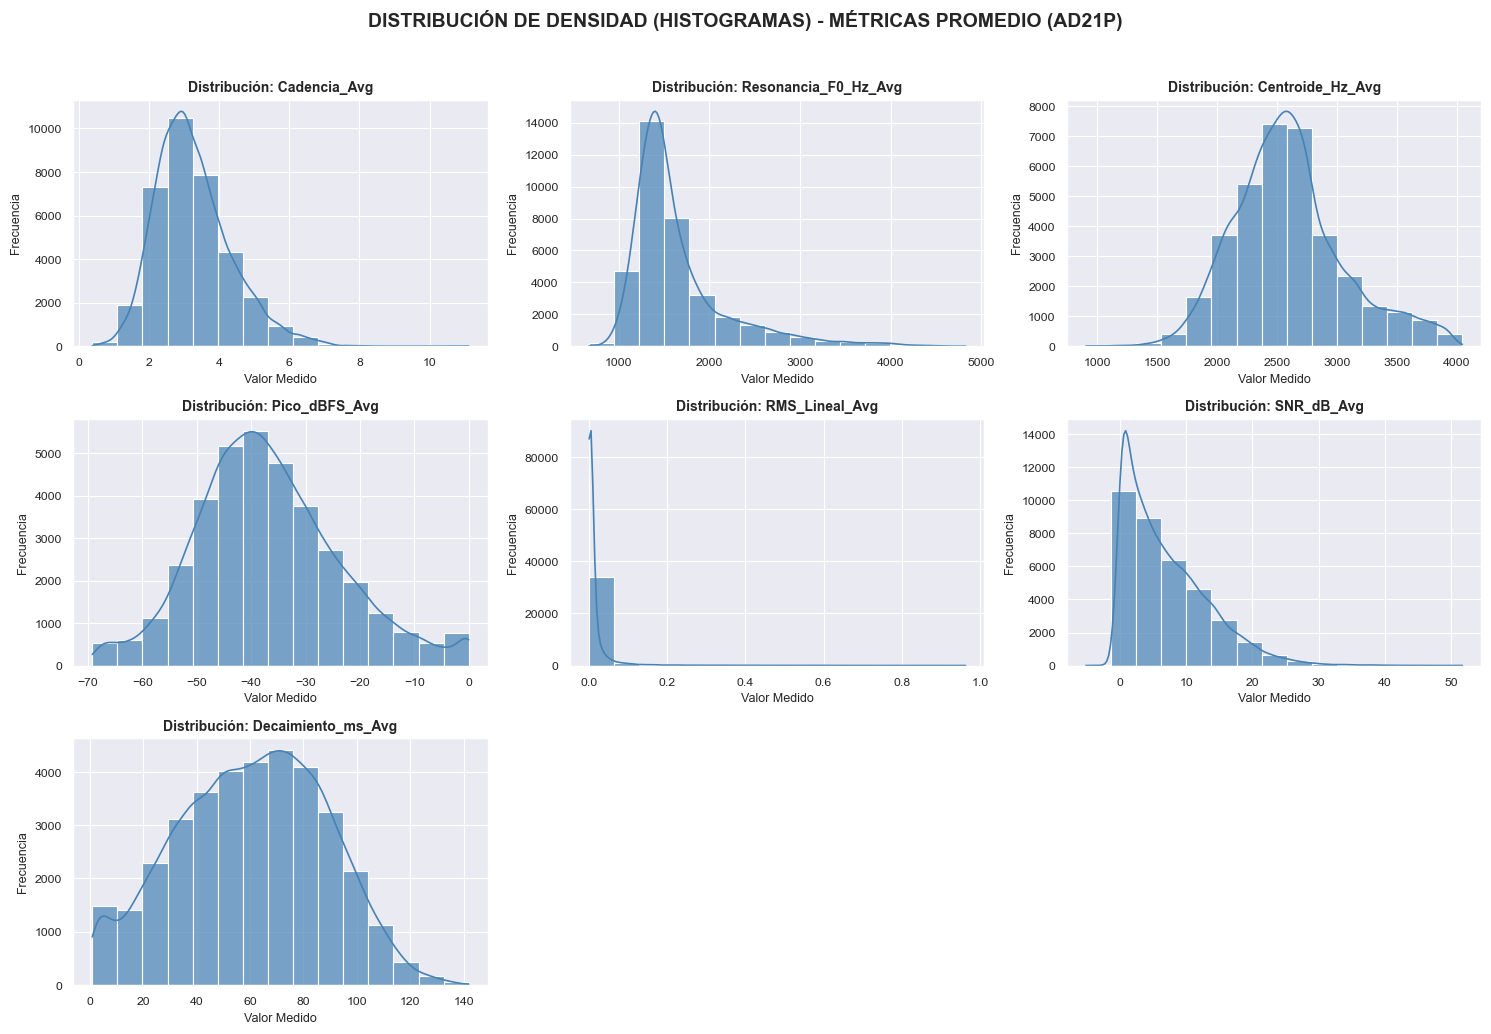

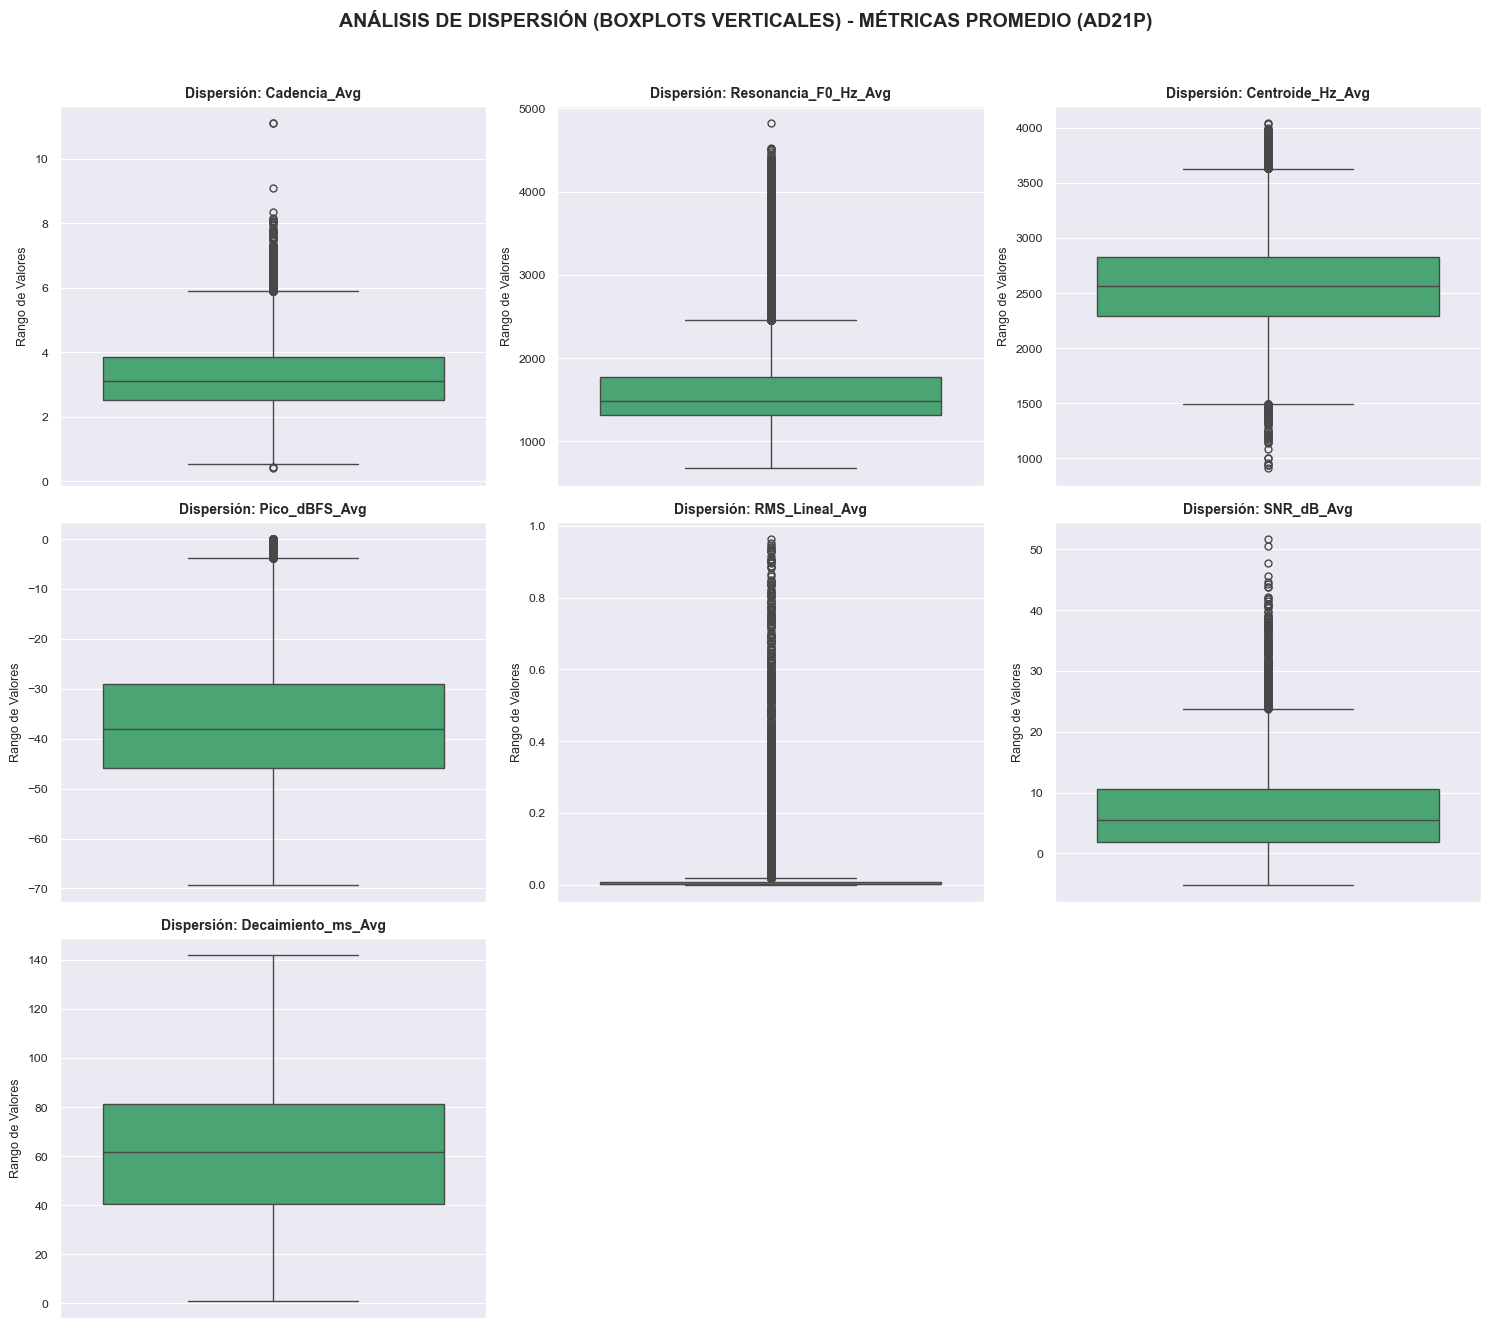

[INFO] Renderizado matricial de lienzos estadísticos completado.


In [27]:
graficar_distribuciones_verdad_base(df_verdad_base)

In [28]:
df_verdad_base

,Archivo,Cadencia_Min,Cadencia_Max,Cadencia_Avg,Resonancia_F0_Hz_Min,Resonancia_F0_Hz_Max,Resonancia_F0_Hz_Avg,Centroide_Hz_Min,Centroide_Hz_Max,Centroide_Hz_Avg,...,Pico_dBFS_Avg,RMS_Lineal_Min,RMS_Lineal_Max,RMS_Lineal_Avg,SNR_dB_Min,SNR_dB_Max,SNR_dB_Avg,Decaimiento_ms_Min,Decaimiento_ms_Max,Decaimiento_ms_Avg
0,sintetico_morse_train_HELP_00001.wav,1.333333,9.090909,3.773630,666.518729,2027.011854,1439.886006,1869.993866,4111.584999,3130.117505,...,-45.880721,0.000263,0.002502,0.000775,-0.912287,17.121492,5.661589,1.7500,149.7500,45.239583
1,sintetico_morse_train_HELP_00004.wav,0.961538,7.692308,3.501273,1146.144106,2078.446792,1561.336787,2557.696110,2973.490407,2730.847643,...,-16.372802,0.039128,0.042351,0.041268,-0.465678,0.675977,0.135360,24.3750,134.0625,89.381250
2,sintetico_morse_train_HELP_00006.wav,1.282051,5.555556,2.751480,746.986627,1715.574188,1025.117574,1561.673539,2773.293832,2251.506249,...,-35.193263,0.001087,0.014341,0.003761,-0.553731,22.135826,6.057240,1.8125,149.7500,93.750000
3,sintetico_morse_train_HELP_00012.wav,0.943396,4.166667,2.207339,637.888221,1496.958059,1197.471304,1429.322846,2993.044008,2197.648748,...,-37.420098,0.000453,0.007357,0.002804,0.324420,24.487168,10.309132,1.5000,144.6250,63.526786
4,sintetico_morse_train_HELP_00017.wav,1.234568,8.333333,3.620702,1198.362902,1962.989094,1466.408117,1107.530061,2594.355122,1968.319609,...,-40.215168,0.000455,0.010362,0.002660,0.346776,25.975647,8.311576,2.1875,133.4375,49.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35766,sintetico_morse_train_V_23930.wav,1.960784,8.333333,4.473039,1122.328534,2155.220655,1463.505121,1563.207991,3621.309874,2414.710587,...,-42.474449,0.000131,0.007153,0.002103,0.055544,35.005609,15.258348,1.6875,14.8750,5.171875
35767,sintetico_morse_train_V_23934.wav,1.785714,11.111111,5.046457,1277.503177,2097.484772,1631.568472,1558.405901,2602.099143,2199.482264,...,-46.263178,0.000525,0.001411,0.000768,-2.181805,8.331167,1.970247,2.5000,143.0625,86.200000
35768,sintetico_morse_train_V_23937.wav,2.325581,9.090909,4.845588,1392.859872,4656.862828,2560.293435,1379.570993,3897.138948,2294.107073,...,-36.683050,0.000109,0.011782,0.004687,-0.069927,36.161232,19.965845,17.6875,86.2500,32.637500
35769,sintetico_morse_train_V_23949.wav,2.500000,3.571429,3.059603,888.159803,1308.499539,1101.216131,1578.866360,2728.654045,2153.244489,...,-18.224565,0.009184,0.072608,0.037730,-0.160837,18.867724,9.818253,33.2500,144.5625,89.575000


In [29]:
df_resumen_global

,Cadencia (Golpes/s),Resonancia F0 (Hz),Centroide Espectral (Hz),Pico (dBFS),RMS Lineal,SNR (dB),Decaimiento (ms)
min,0.296736,162.039314,644.771619,-7.122415e+01,0.000096,-42.901524,0.000000
max,12.500000,8000.000000,5052.360386,8.685890e-10,0.966810,63.313166,149.937500
avg,3.259568,1643.023322,2598.651390,-3.685044e+01,0.016881,6.994867,60.617449


### **Analisis de los datos reales en zona_cero Ritmos objetivos**

In [30]:
# 1. Definición de rutas y estructuras
ruta_carpeta_ritmo = Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_original\zona_cero\Target_Rhythmic")
datos_consolidados = []

print("[INFO] Iniciando extracción de la Verdad Base Acústica...")

# 2. Bucle Iterativo: Extracción granular archivo por archivo
for archivo_wav in ruta_carpeta_ritmo.rglob('*.wav'):
    metricas = analizar_y_extraer_verdad_base_impactos(ruta_audio=archivo_wav)

    # Validación de existencia de impactos
    if metricas["ritmo_impactos_por_segundo"]["promedio"] > 0:
        fila = {
            "Archivo": archivo_wav.name,

            # Cadencia
            "Cadencia_Min": metricas["ritmo_impactos_por_segundo"]["min"],
            "Cadencia_Max": metricas["ritmo_impactos_por_segundo"]["max"],
            "Cadencia_Avg": metricas["ritmo_impactos_por_segundo"]["promedio"],

            # Resonancia Estructural
            "Resonancia_F0_Hz_Min": metricas["resonancia_f0_hz"]["min"],
            "Resonancia_F0_Hz_Max": metricas["resonancia_f0_hz"]["max"],
            "Resonancia_F0_Hz_Avg": metricas["resonancia_f0_hz"]["promedio"],

            # Centroide Espectral
            "Centroide_Hz_Min": metricas["centroide_espectral_hz"]["min"],
            "Centroide_Hz_Max": metricas["centroide_espectral_hz"]["max"],
            "Centroide_Hz_Avg": metricas["centroide_espectral_hz"]["promedio"],

            # Dinámica Pico
            "Pico_dBFS_Min": metricas["dinamica_pico_dbfs"]["min"],
            "Pico_dBFS_Max": metricas["dinamica_pico_dbfs"]["max"],
            "Pico_dBFS_Avg": metricas["dinamica_pico_dbfs"]["promedio"],

            # Dinámica RMS
            "RMS_Lineal_Min": metricas["dinamica_rms_lineal"]["min"],
            "RMS_Lineal_Max": metricas["dinamica_rms_lineal"]["max"],
            "RMS_Lineal_Avg": metricas["dinamica_rms_lineal"]["promedio"],

            # Relación Señal/Ruido (SNR)
            "SNR_dB_Min": metricas["relacion_senal_ruido_snr_db"]["min"],
            "SNR_dB_Max": metricas["relacion_senal_ruido_snr_db"]["max"],
            "SNR_dB_Avg": metricas["relacion_senal_ruido_snr_db"]["promedio"],

            # Morfología Temporal
            "Decaimiento_ms_Min": metricas["morfologia_decaimiento_ms"]["min"],
            "Decaimiento_ms_Max": metricas["morfologia_decaimiento_ms"]["max"],
            "Decaimiento_ms_Avg": metricas["morfologia_decaimiento_ms"]["promedio"],
        }
        datos_consolidados.append(fila)

# 3. Construcción del DataFrame Detallado
df_verdad_base = pd.DataFrame(datos_consolidados)

if not df_verdad_base.empty:
    print("[INFO] Extracción completada con éxito. Calculando matrices globales...")

    # 4. Construcción del DataFrame Resumen Global (Límites Absolutos y Promedios)
    # Se utiliza un diccionario orientado a índices para generar la matriz final
    data_resumen = {
        "min": {},
        "max": {},
        "avg": {}
    }

    # Mapeo de columnas para facilitar las operaciones estadísticas
    mapa_columnas = {
        "Cadencia (Golpes/s)": ("Cadencia_Min", "Cadencia_Max", "Cadencia_Avg"),
        "Resonancia F0 (Hz)": ("Resonancia_F0_Hz_Min", "Resonancia_F0_Hz_Max", "Resonancia_F0_Hz_Avg"),
        "Centroide Espectral (Hz)": ("Centroide_Hz_Min", "Centroide_Hz_Max", "Centroide_Hz_Avg"),
        "Pico (dBFS)": ("Pico_dBFS_Min", "Pico_dBFS_Max", "Pico_dBFS_Avg"),
        "RMS Lineal": ("RMS_Lineal_Min", "RMS_Lineal_Max", "RMS_Lineal_Avg"),
        "SNR (dB)": ("SNR_dB_Min", "SNR_dB_Max", "SNR_dB_Avg"),
        "Decaimiento (ms)": ("Decaimiento_ms_Min", "Decaimiento_ms_Max", "Decaimiento_ms_Avg")
    }

    for caracteristica, (col_min, col_max, col_avg) in mapa_columnas.items():
        # Cálculo de los límites físicos absolutos y la "Gran Media"
        data_resumen["min"][caracteristica] = df_verdad_base[col_min].min()
        data_resumen["max"][caracteristica] = df_verdad_base[col_max].max()
        data_resumen["avg"][caracteristica] = df_verdad_base[col_avg].mean()

    df_resumen_global = pd.DataFrame(data_resumen).T


else:
    print("[ERROR] No se pudieron extraer datos válidos. Revise la ruta especificada.")

[INFO] Iniciando extracción de la Verdad Base Acústica...


C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1600
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1261
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1275
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=1365
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=2048 is too large for input signal of length=914
  warnings.warn(
C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\librosa\core\spectrum.py:257: UserWarning: n_fft=

[INFO] Extracción completada con éxito. Calculando matrices globales...


In [31]:
print(df_resumen_global.to_json())
df_resumen_global.head()

{"Cadencia (Golpes\/s)":{"min":0.1453488372,"max":12.5,"avg":4.4250376909},"Resonancia F0 (Hz)":{"min":754.1862344169,"max":8000.0,"avg":1883.2413179253},"Centroide Espectral (Hz)":{"min":1659.0021501793,"max":6410.8290421895,"avg":3167.2093693787},"Pico (dBFS)":{"min":-76.3295929201,"max":0.0000000009,"avg":-26.2507833336},"RMS Lineal":{"min":0.0000602804,"max":0.210357177,"avg":0.0179561821},"SNR (dB)":{"min":-50.0861847151,"max":64.1619542951,"avg":4.6038035716},"Decaimiento (ms)":{"min":0.4375,"max":149.875,"avg":67.7303586541}}


,Cadencia (Golpes/s),Resonancia F0 (Hz),Centroide Espectral (Hz),Pico (dBFS),RMS Lineal,SNR (dB),Decaimiento (ms)
min,0.145349,754.186234,1659.002150,-7.632959e+01,0.000060,-50.086185,0.437500
max,12.500000,8000.000000,6410.829042,8.685890e-10,0.210357,64.161954,149.875000
avg,4.425038,1883.241318,3167.209369,-2.625078e+01,0.017956,4.603804,67.730359


In [32]:
df_verdad_base.head()

,Archivo,Cadencia_Min,Cadencia_Max,Cadencia_Avg,Resonancia_F0_Hz_Min,Resonancia_F0_Hz_Max,Resonancia_F0_Hz_Avg,Centroide_Hz_Min,Centroide_Hz_Max,Centroide_Hz_Avg,...,Pico_dBFS_Avg,RMS_Lineal_Min,RMS_Lineal_Max,RMS_Lineal_Avg,SNR_dB_Min,SNR_dB_Max,SNR_dB_Avg,Decaimiento_ms_Min,Decaimiento_ms_Max,Decaimiento_ms_Avg
0,aHM20260705012705_10_process.wav,2.083333,7.692308,4.812012,1500.764489,3520.336025,2315.464459,3249.111448,3982.681385,3371.702195,...,-23.624279,0.007867,0.112458,0.024058,-1.555004,6.851448,1.214143,2.7500,148.8125,94.758929
1,asdsdaHM20260704050719_9_process.wav,1.000000,3.571429,2.476190,1245.369863,3142.930332,2180.444648,3182.739699,3673.665812,3510.873279,...,-21.091444,0.001385,0.057841,0.019787,0.020198,24.109482,14.043449,3.3750,129.1875,46.662500
2,HM202607031240a43_9_process.wav,3.333333,8.333333,6.470588,1296.904035,2005.647973,1663.894500,2660.506538,2959.141259,2784.790708,...,-30.776768,0.004564,0.005845,0.005232,-0.328461,1.460268,0.595954,22.3125,147.5000,103.800000
3,HM20260703124423_9_process.wav,2.777778,10.000000,5.400090,754.567015,1770.532530,1350.924393,2275.546688,2782.485600,2590.032231,...,-33.241977,0.004727,0.009263,0.005531,-0.453282,5.819002,1.006971,14.0625,149.6875,80.072917
4,HM202607031a25514_10_process.wav,2.777778,12.500000,6.099061,1041.458528,1828.528836,1404.409370,2637.728845,3221.022606,2812.409540,...,-31.257670,0.005313,0.009419,0.006627,-0.429901,3.434049,0.713340,14.5000,144.8750,98.726562


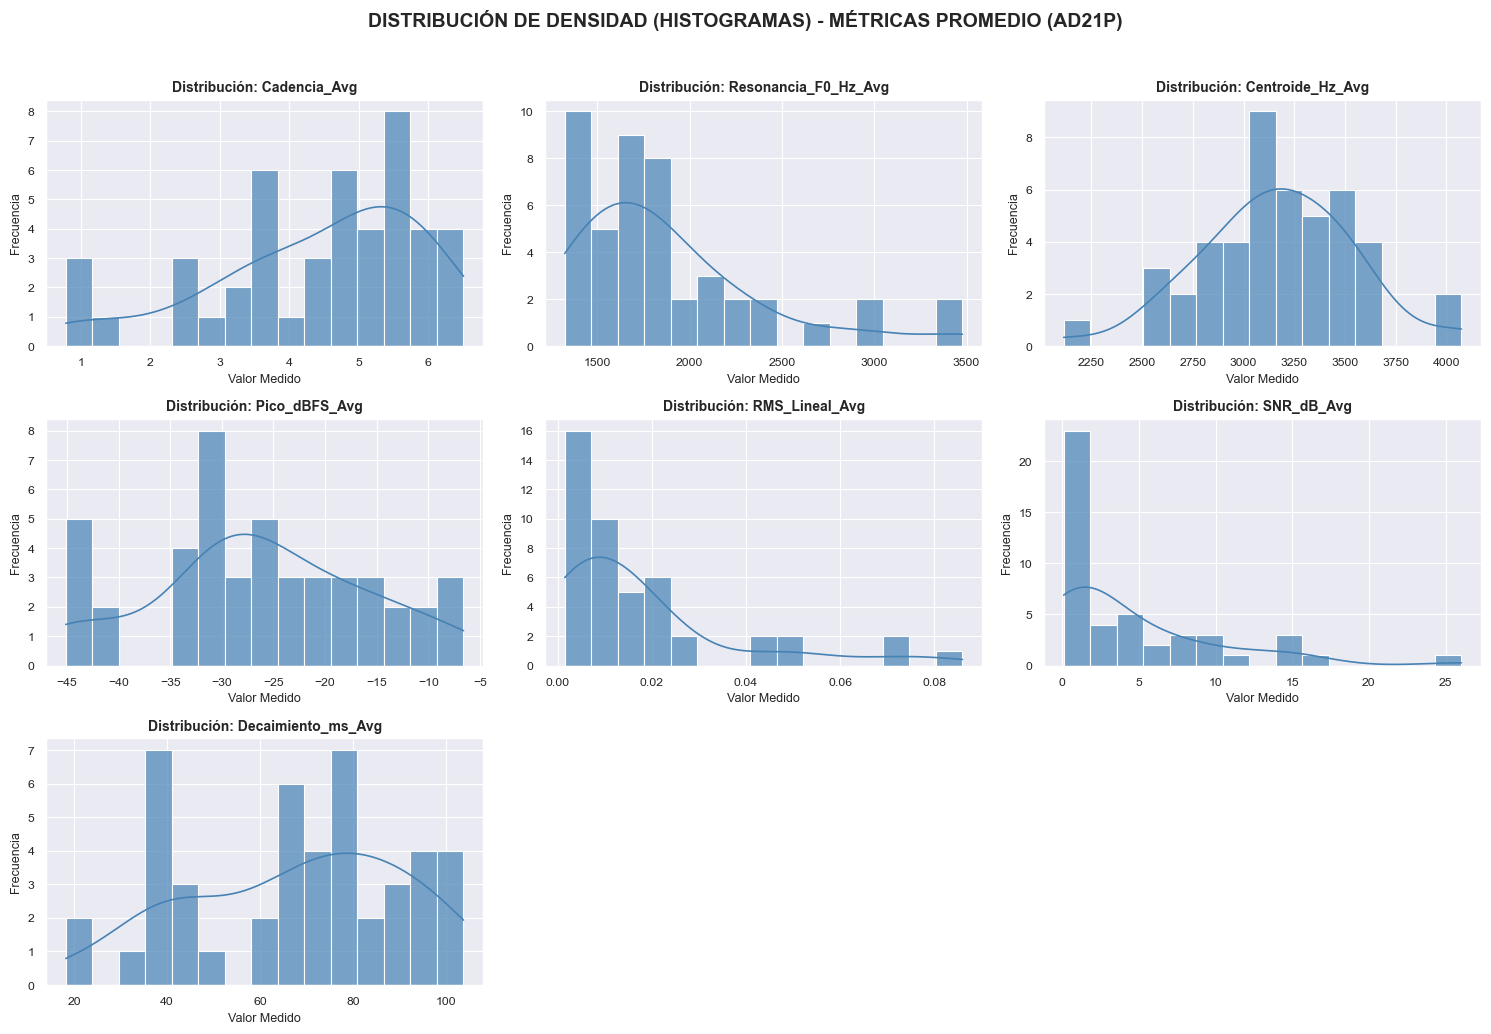

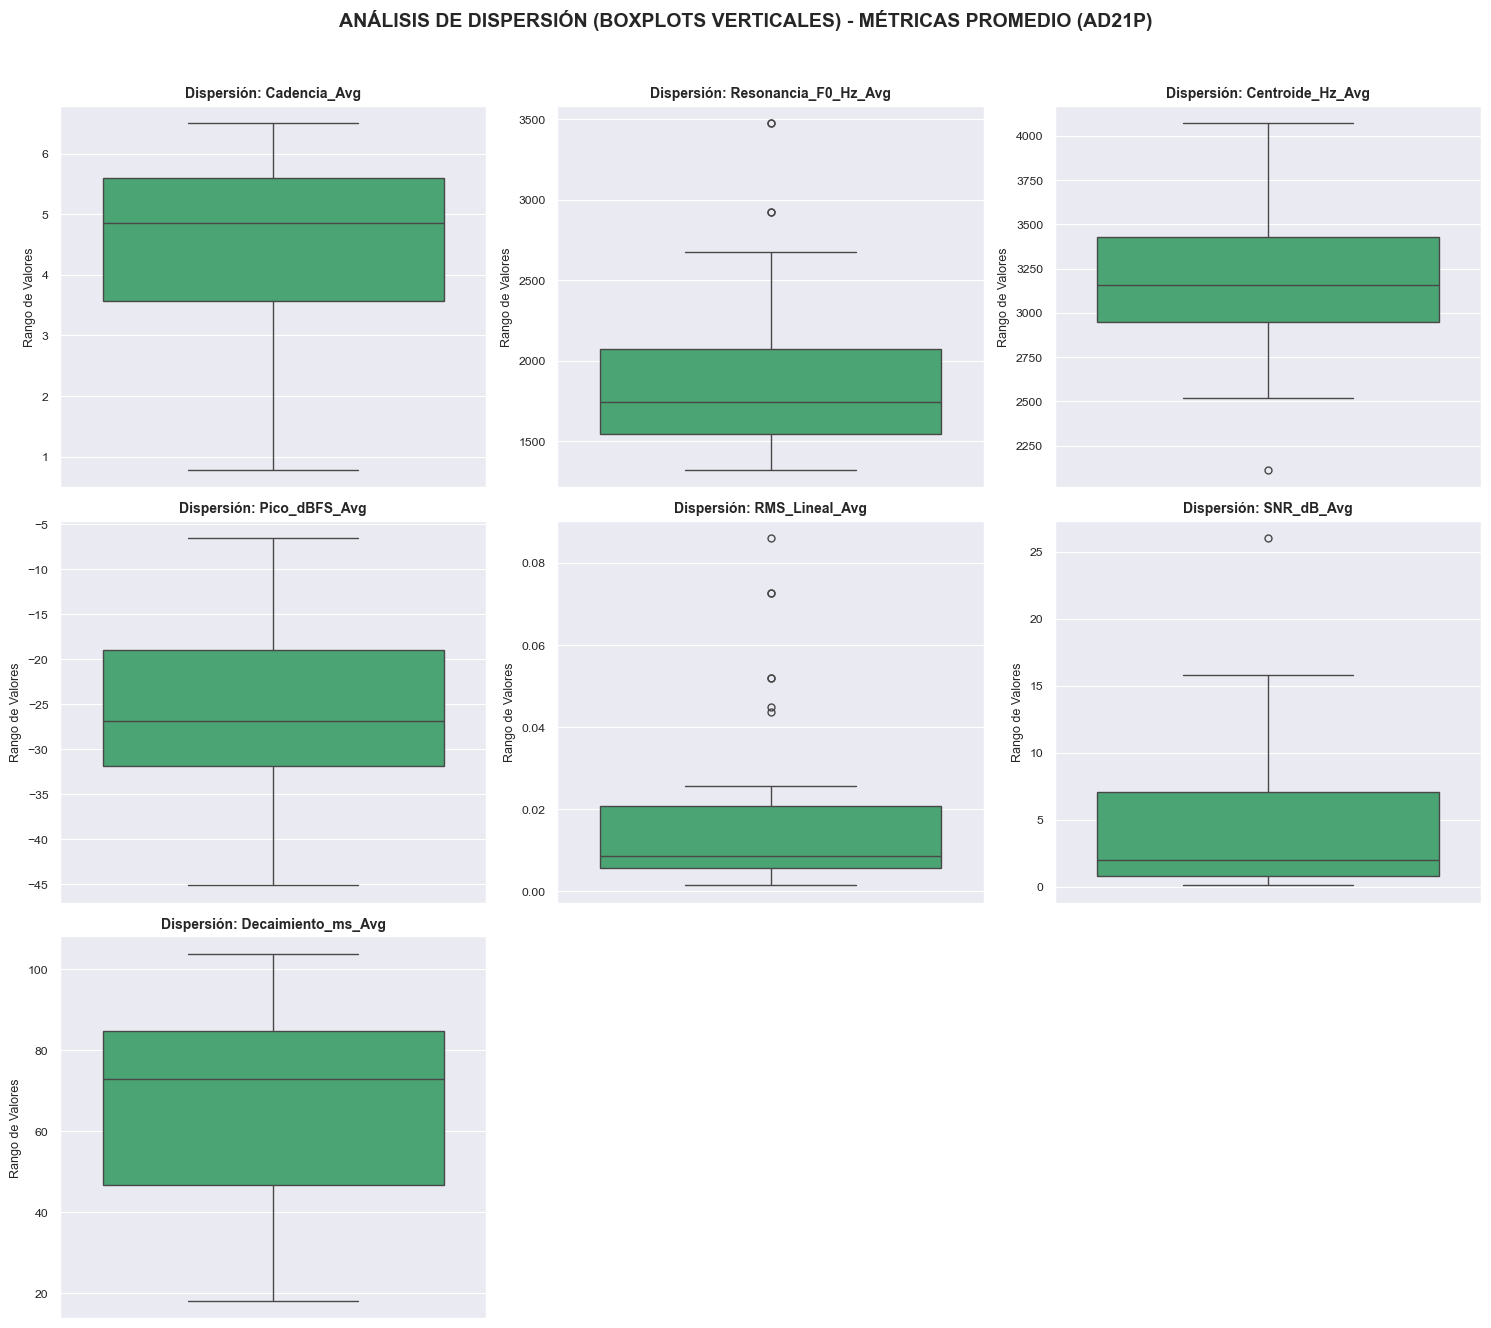

[INFO] Renderizado matricial de lienzos estadísticos completado.


In [33]:
graficar_distribuciones_verdad_base(df_verdad_base)


 FASE 0: ANÁLISIS EXPLORATORIO DE LÍNEA BASE (CRUDO)
[INFO] Se indexaron 20222 audios crudos. Extrayendo descriptores...
[INFO] Renderizando Dashboards de Línea Base...


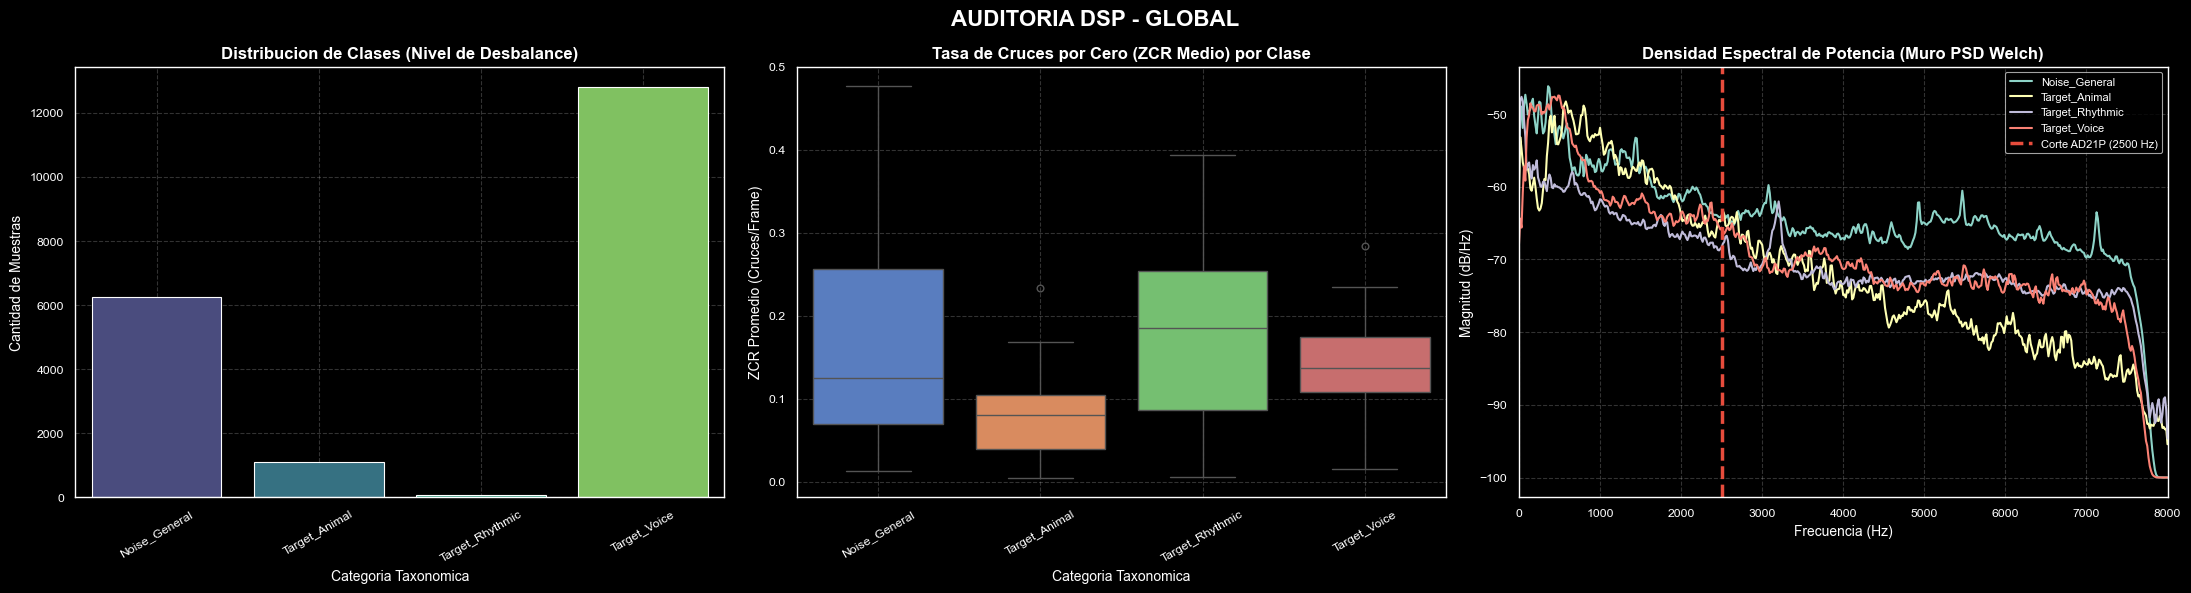

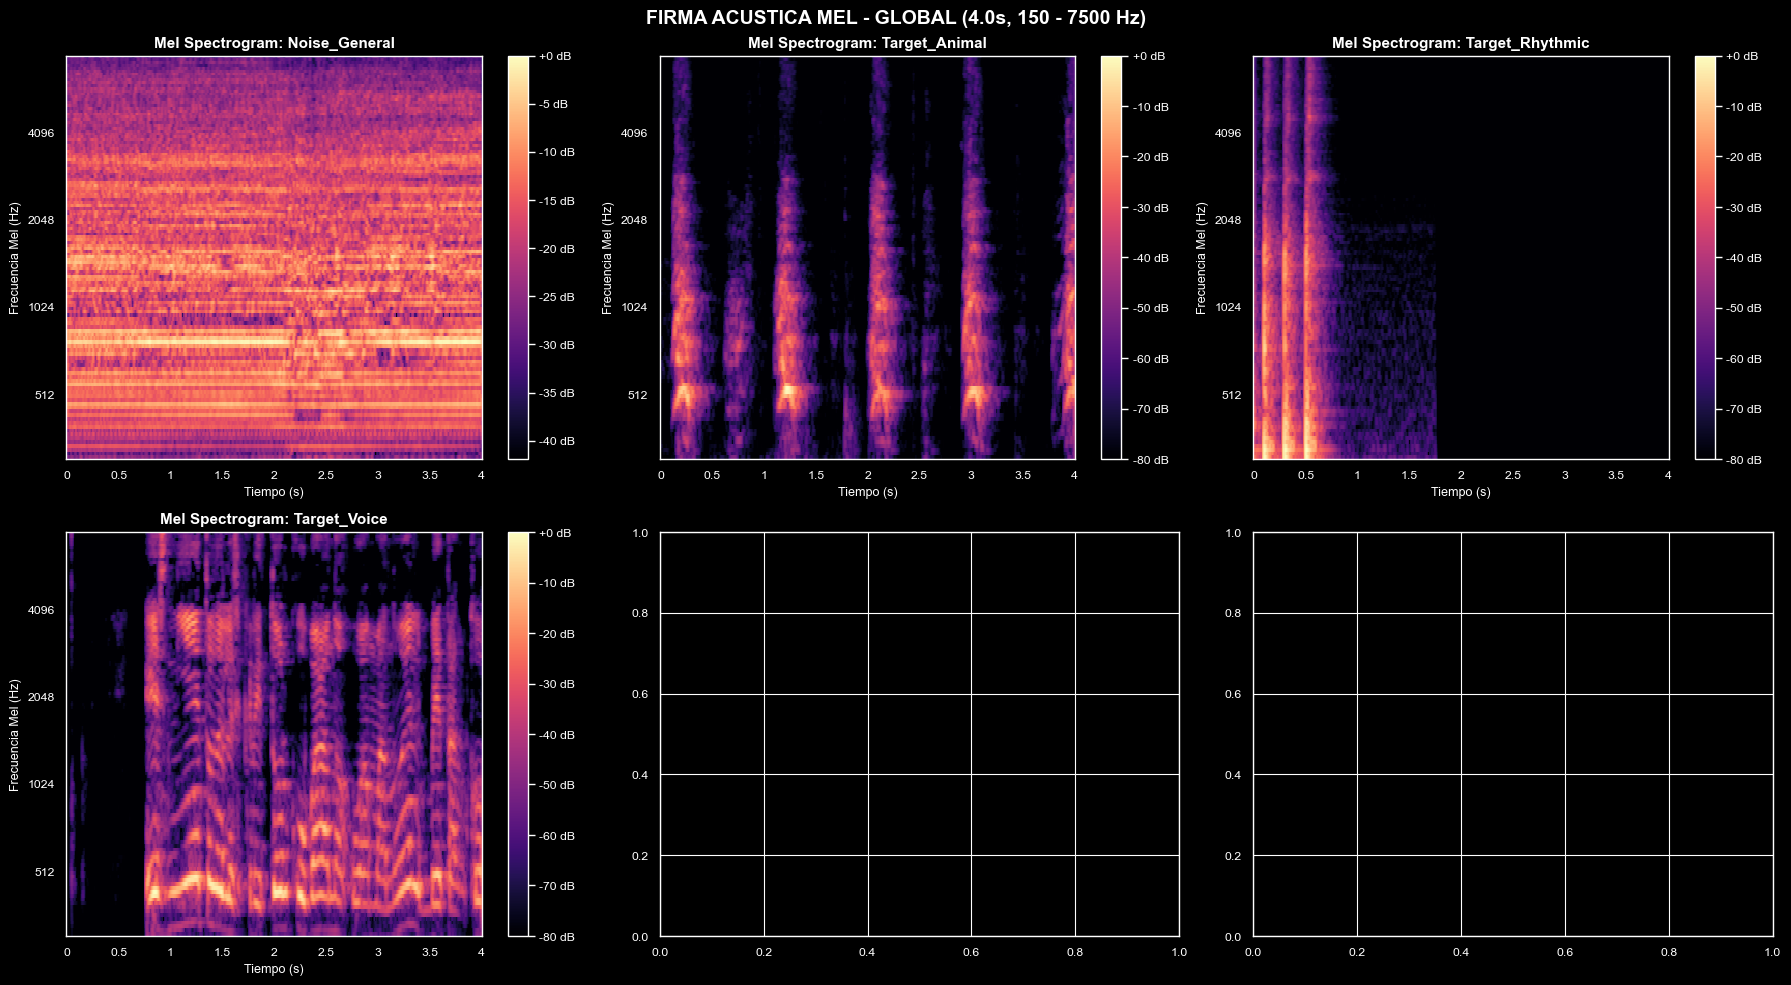


[EDA] Iniciando exploración granular para 6 datasets: ['esc_50' 'gritos' 'sonidos_perros_gatos' 'urban_sound' 'voces_espanol'
 'zona_cero']
Extrayendo y renderizando vistas para Dataset: [ESC_50]...


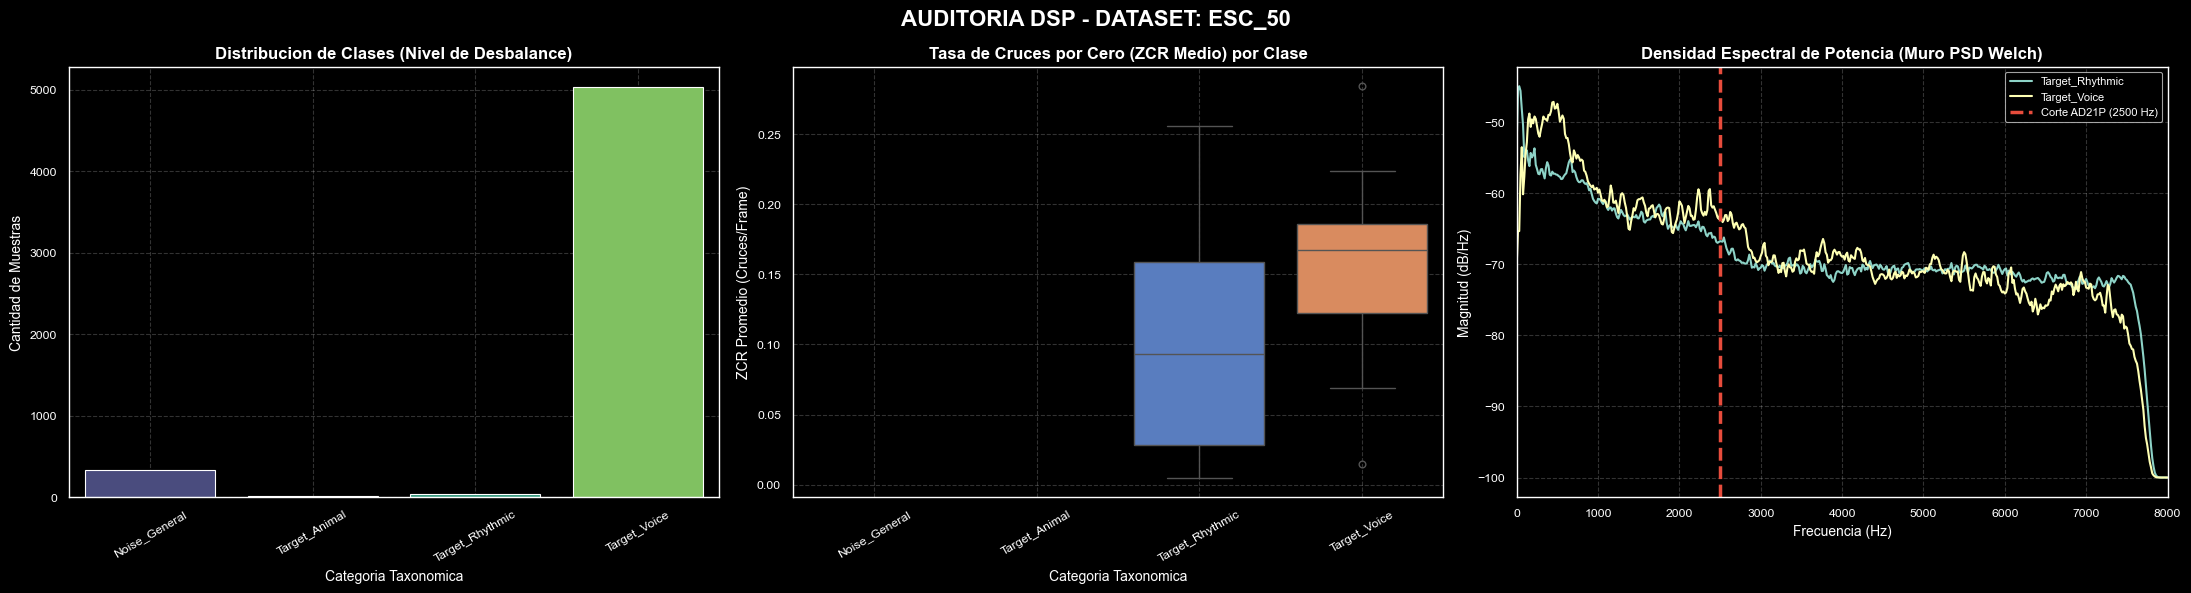

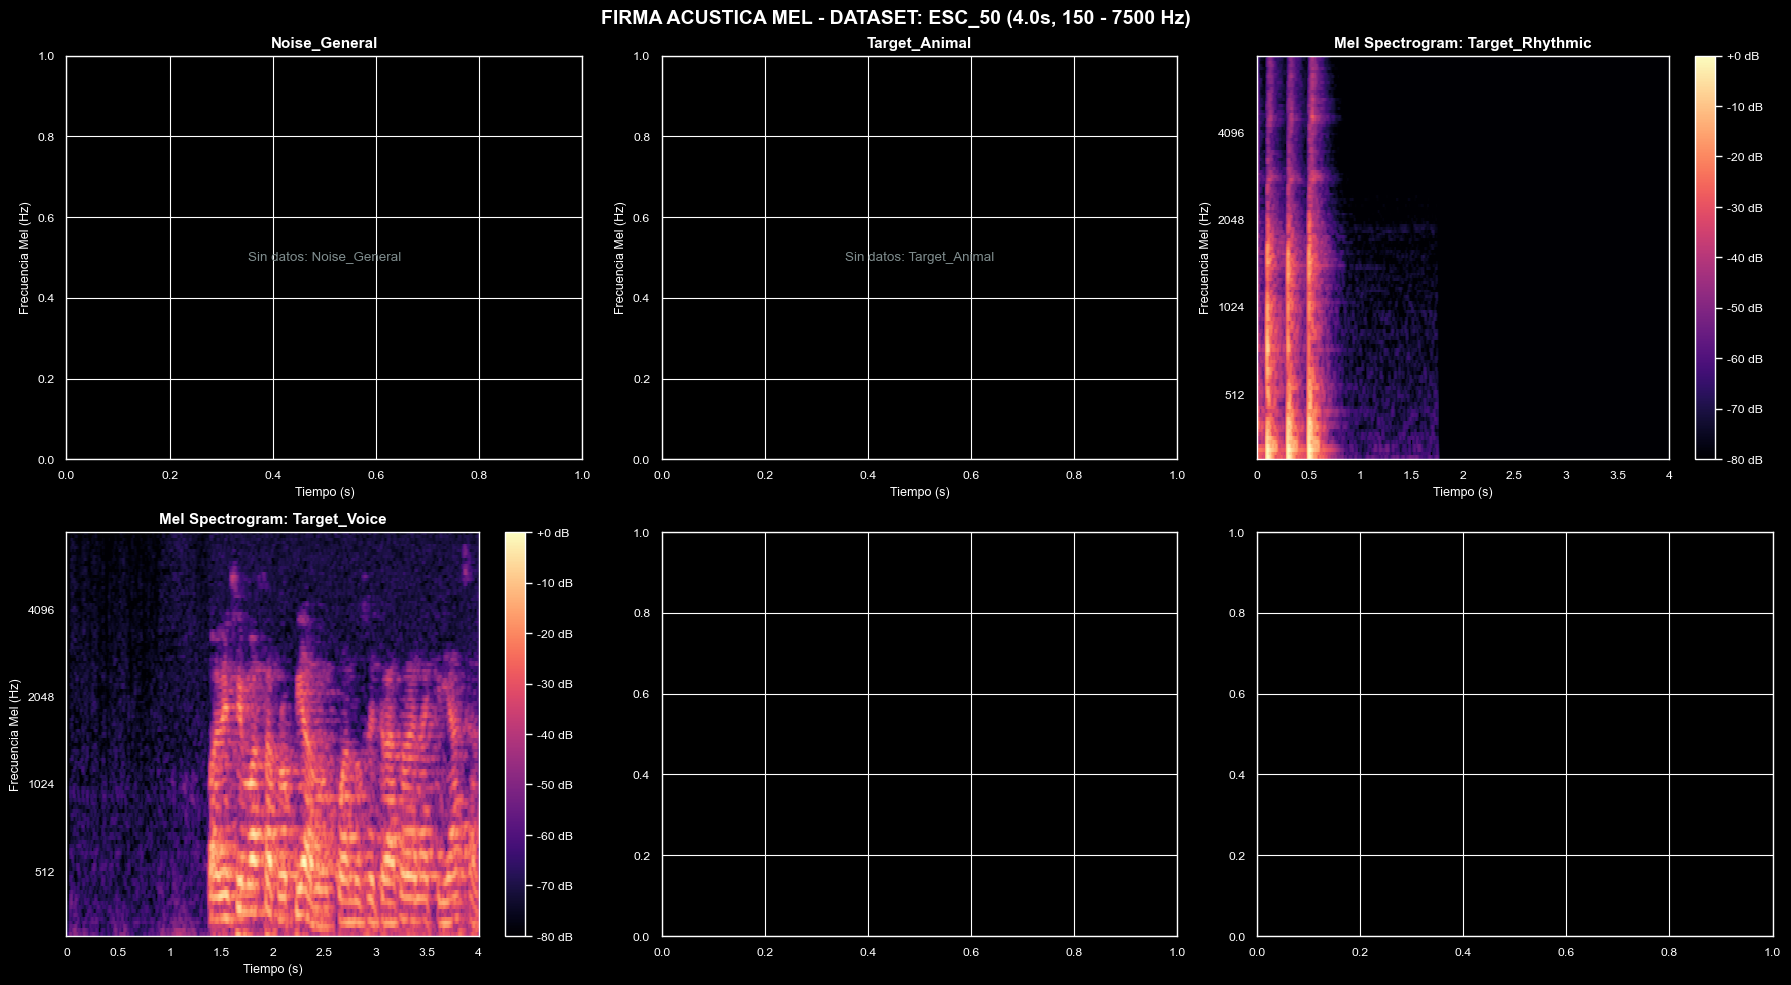

Extrayendo y renderizando vistas para Dataset: [GRITOS]...


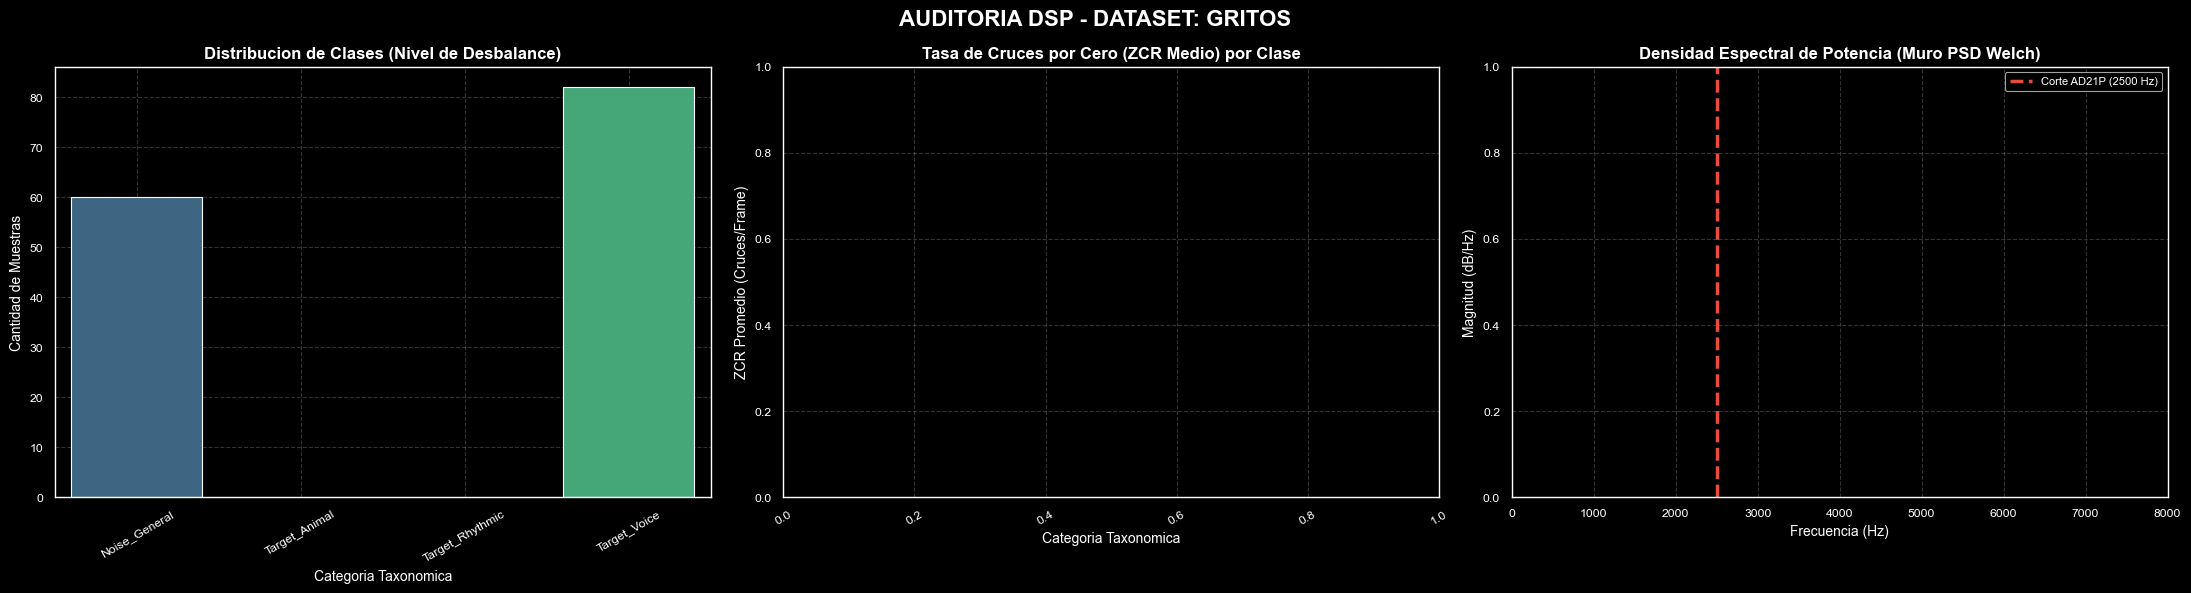

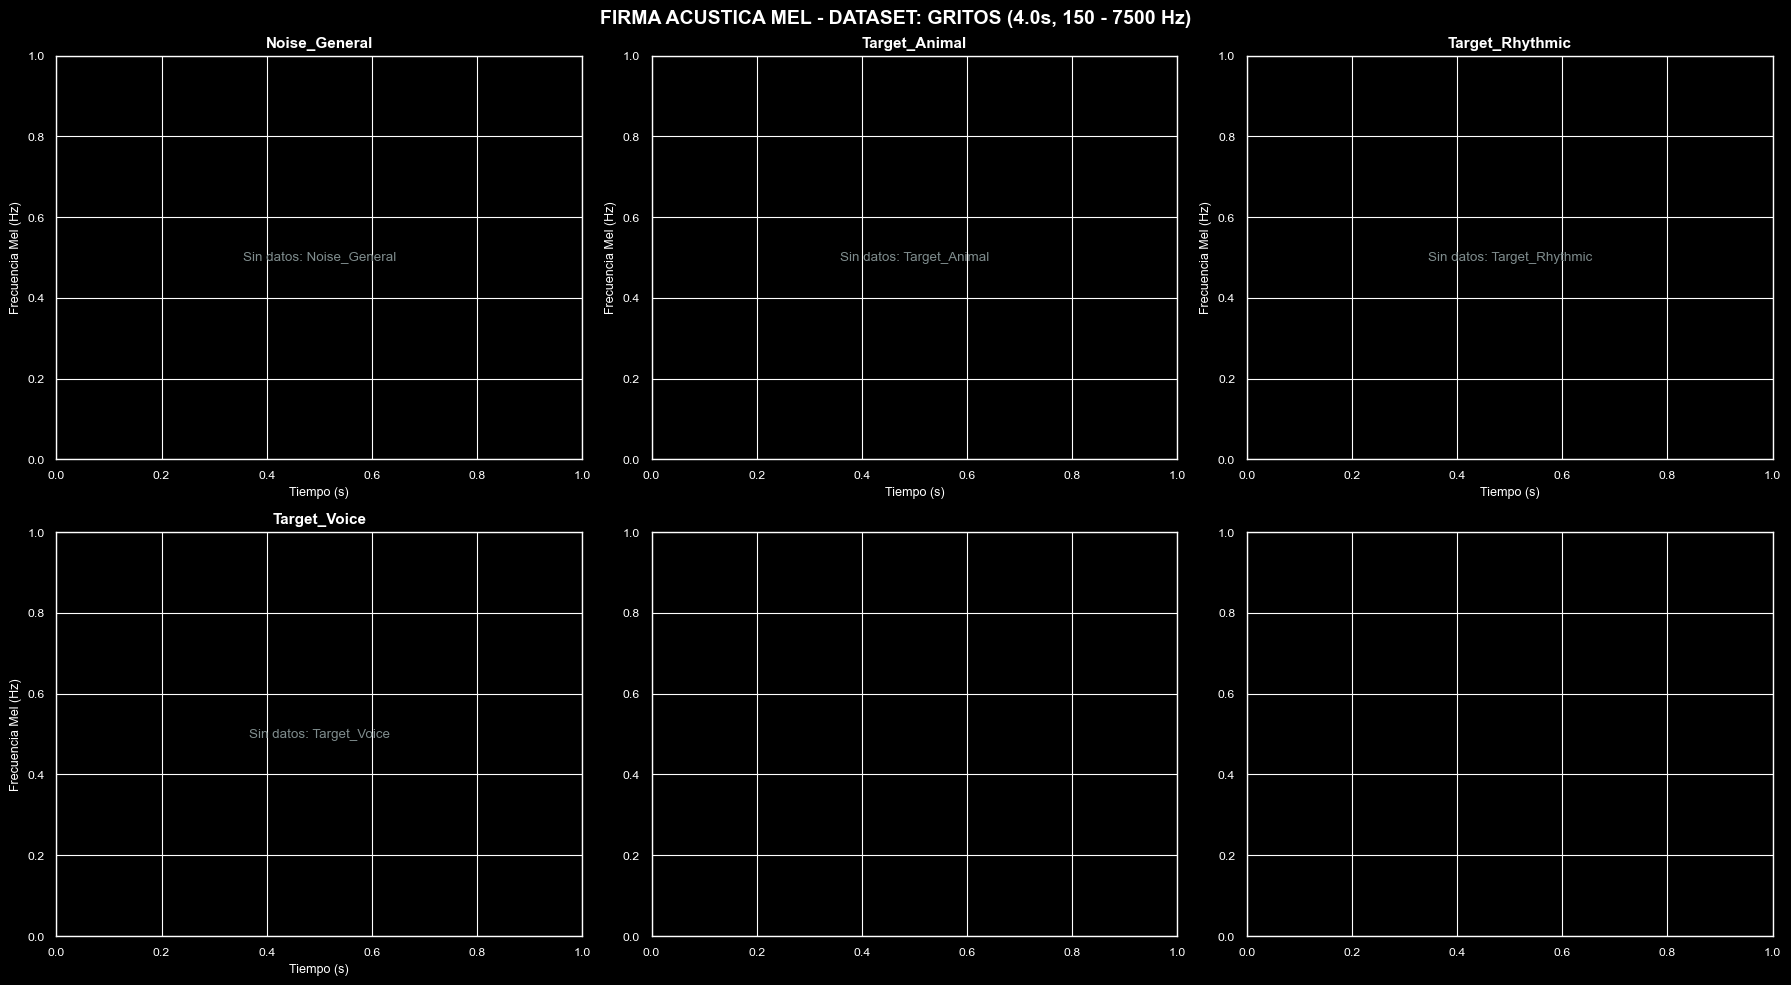

Extrayendo y renderizando vistas para Dataset: [SONIDOS_PERROS_GATOS]...


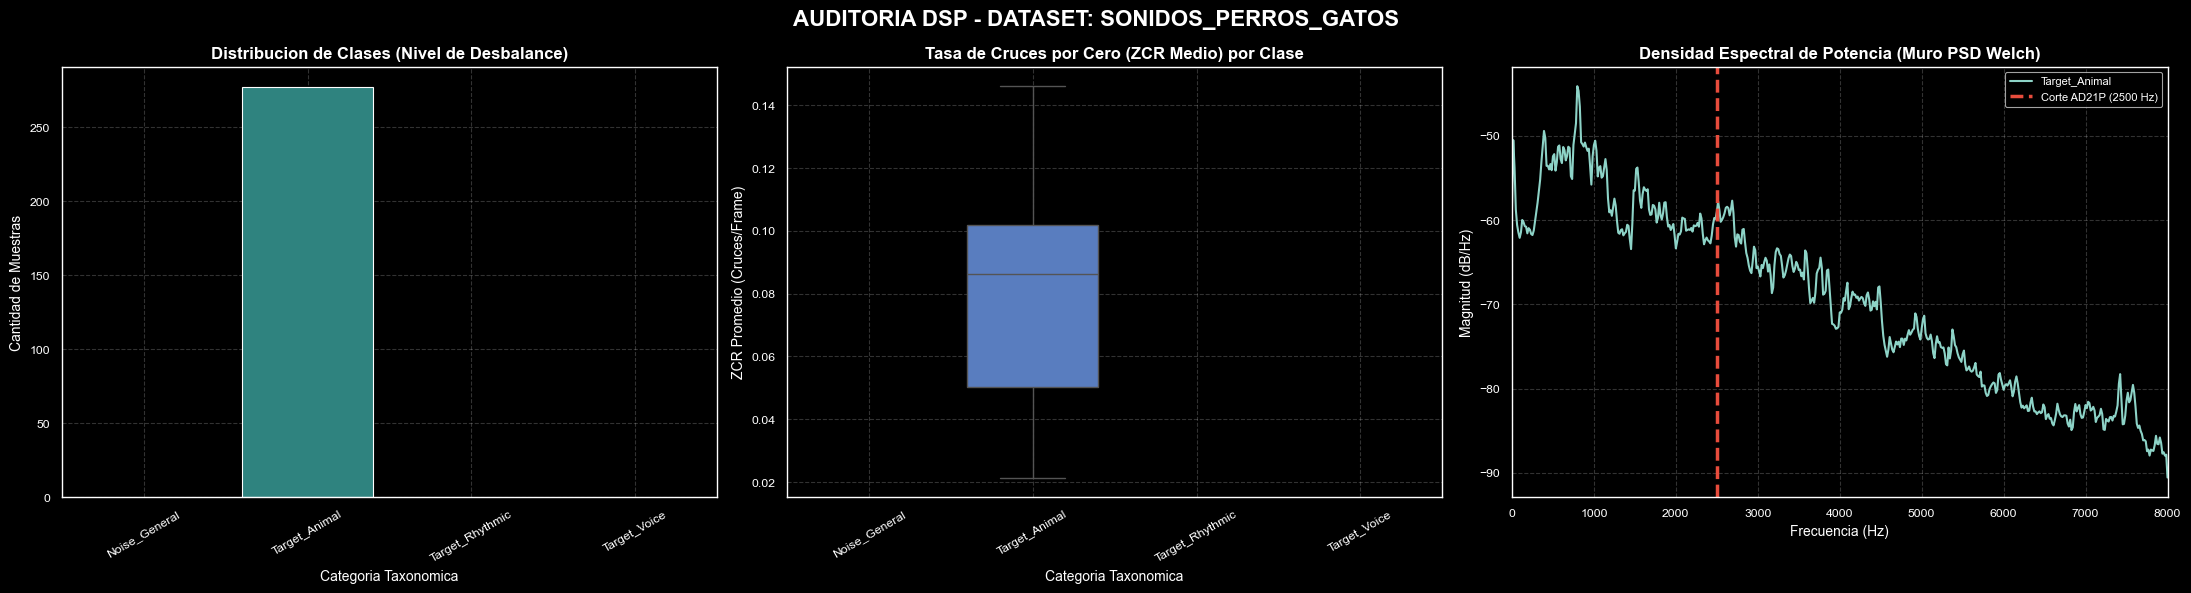

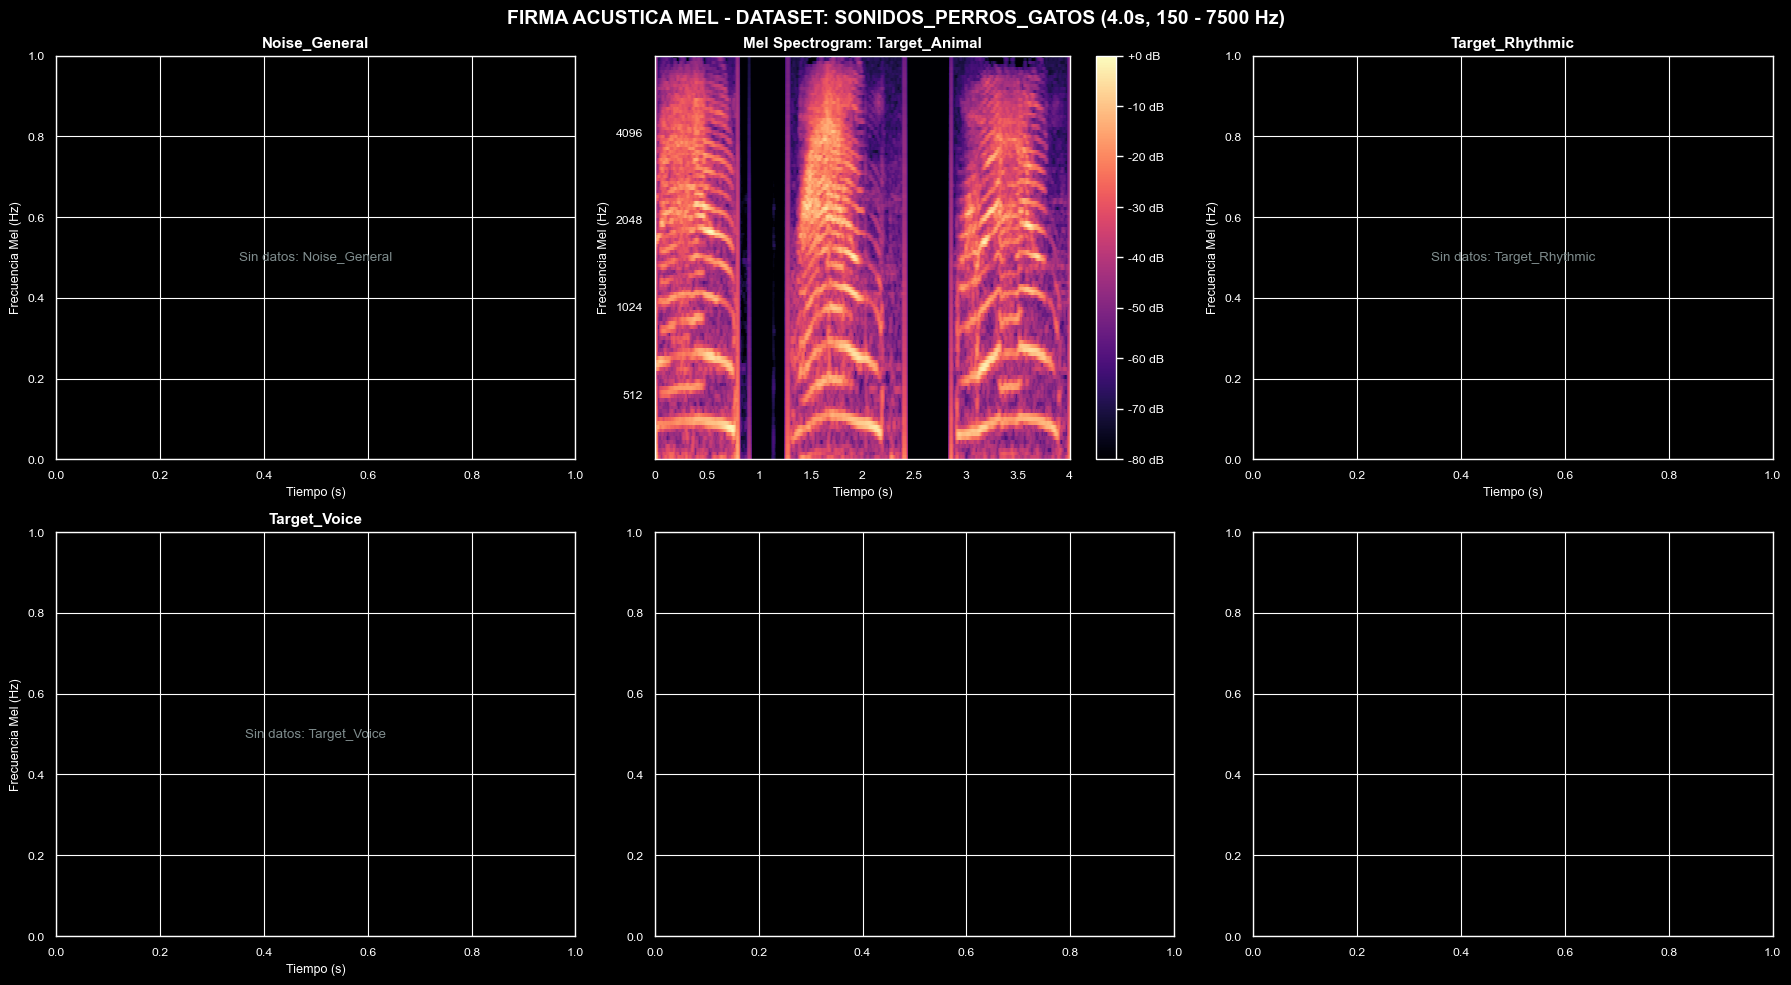

Extrayendo y renderizando vistas para Dataset: [URBAN_SOUND]...


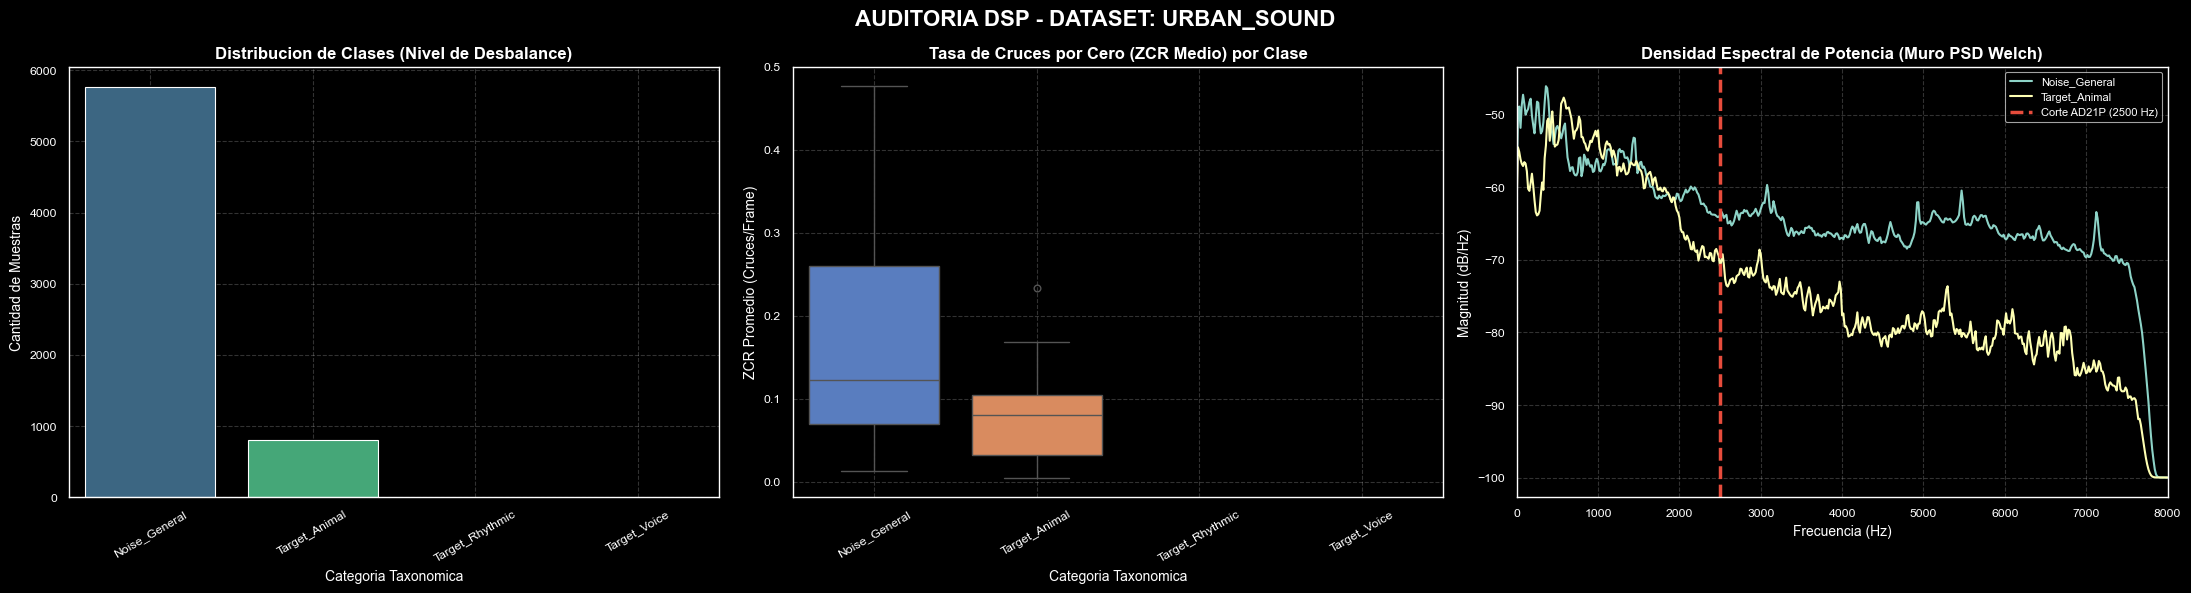

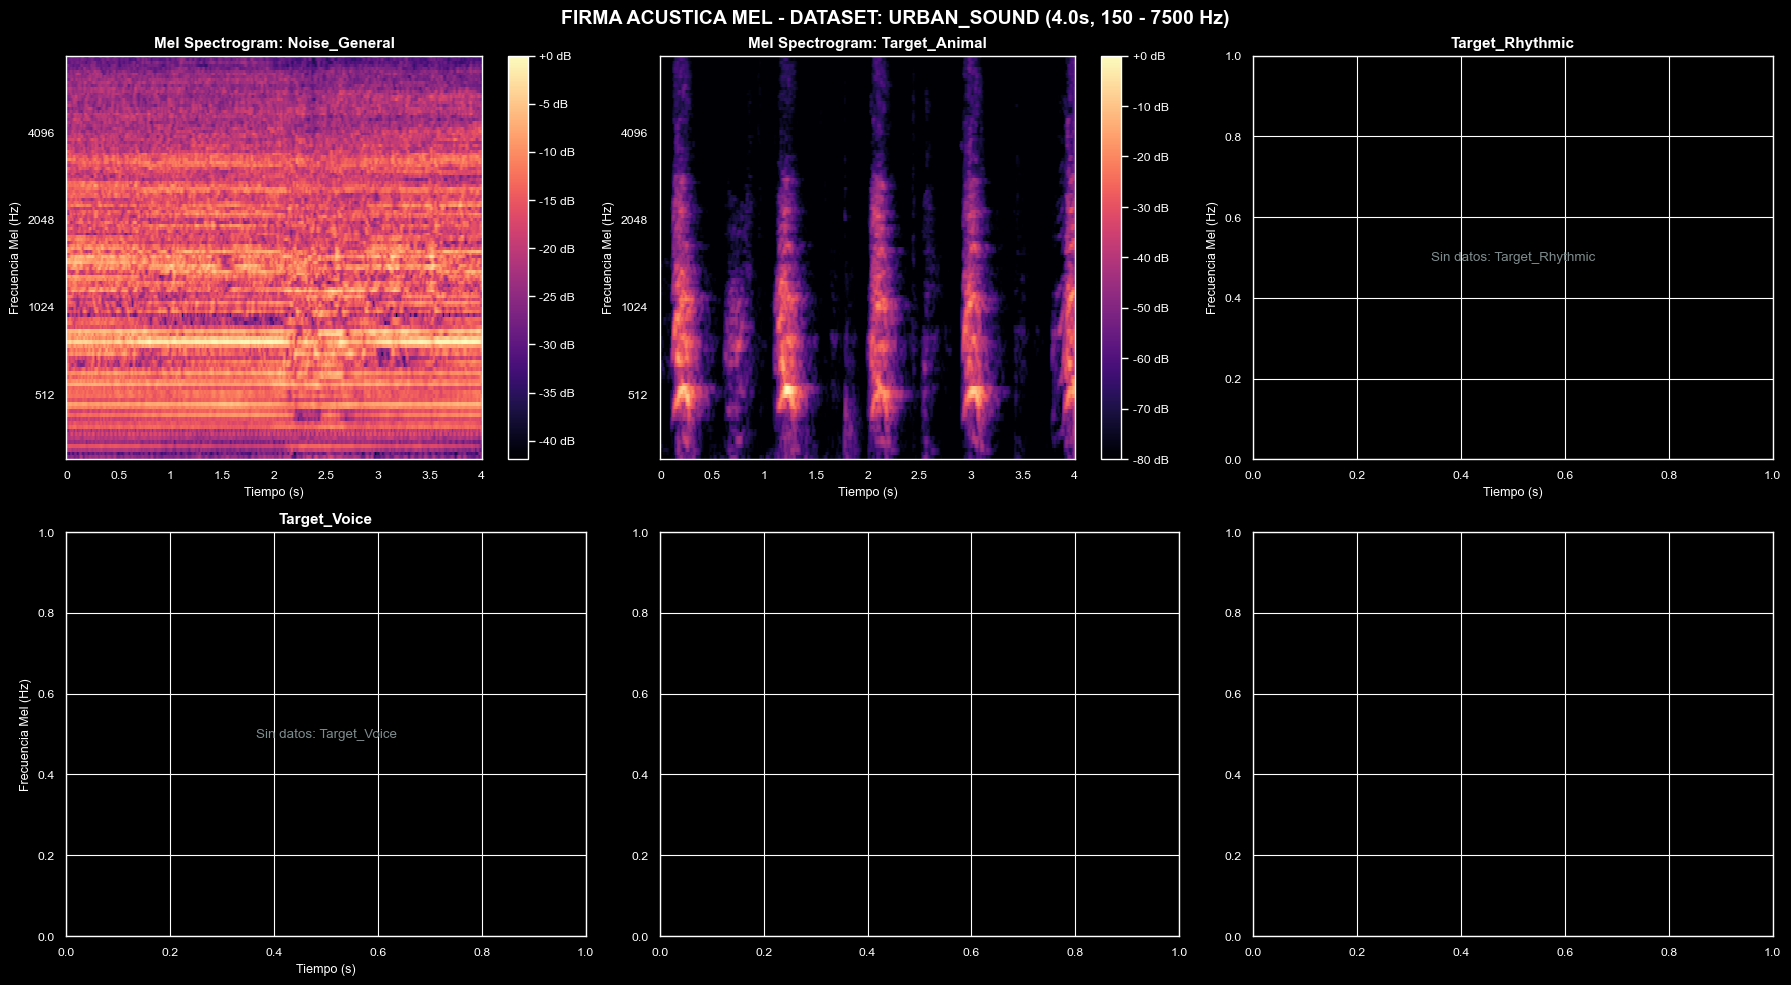

Extrayendo y renderizando vistas para Dataset: [VOCES_ESPANOL]...


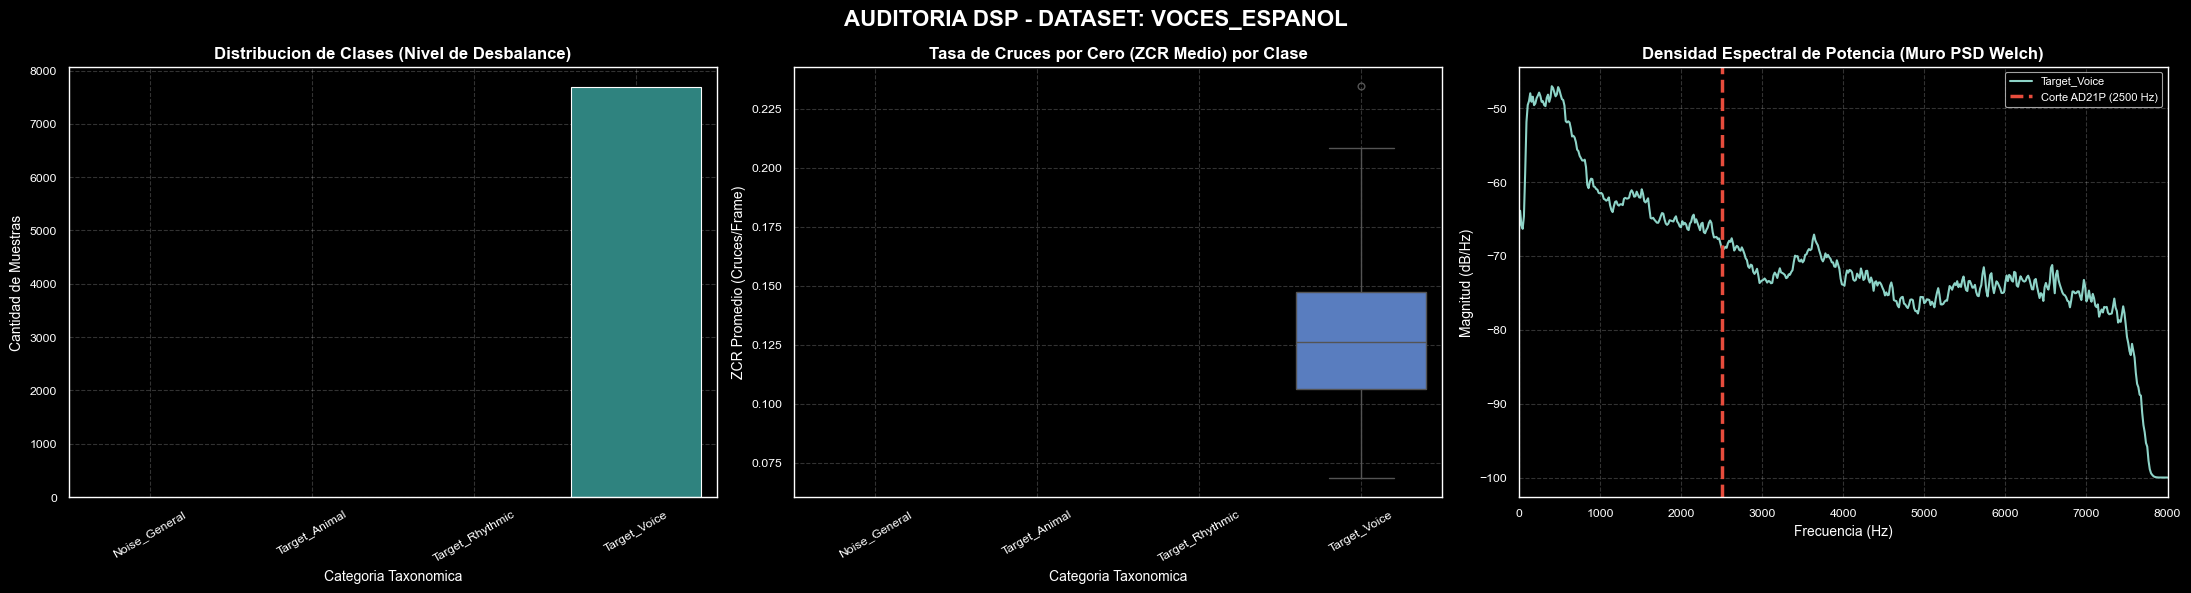

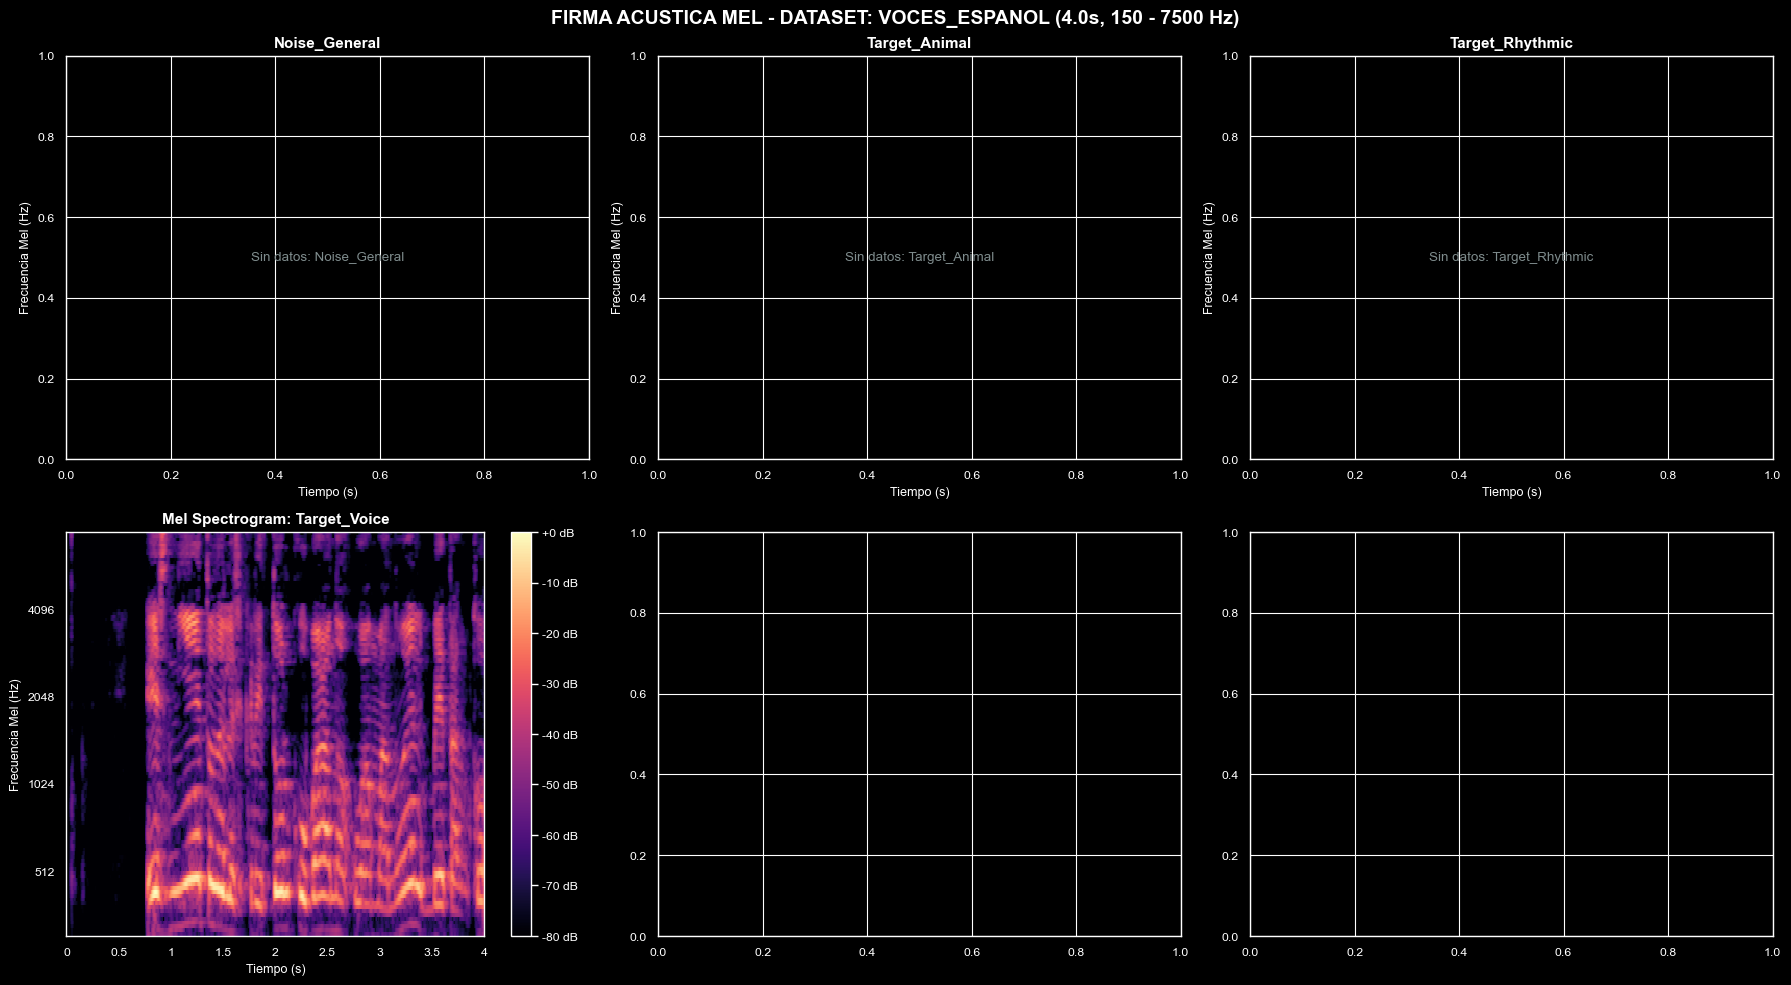

Extrayendo y renderizando vistas para Dataset: [ZONA_CERO]...


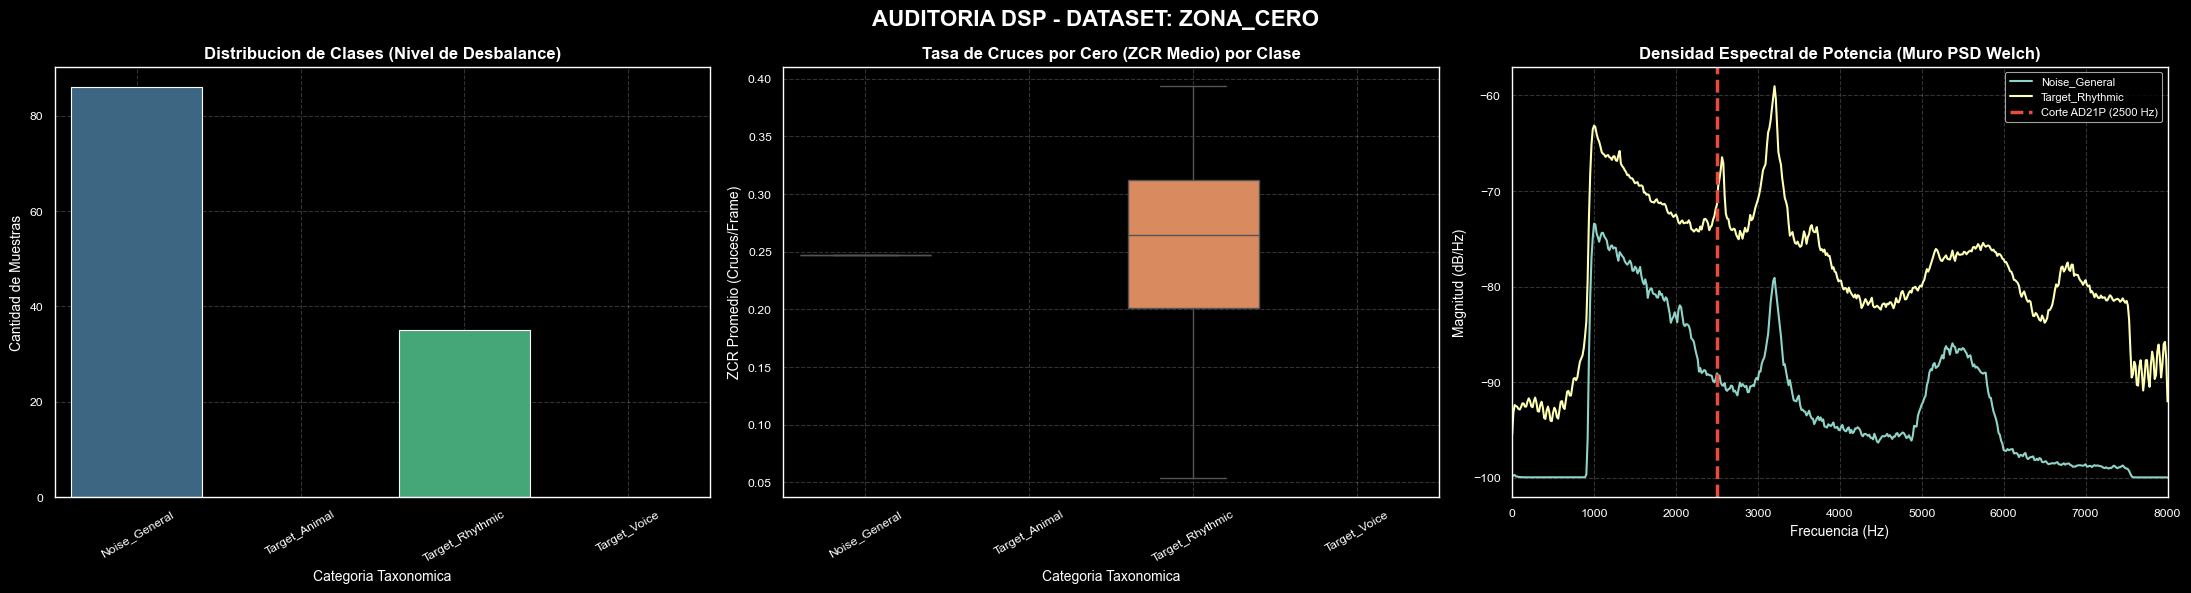

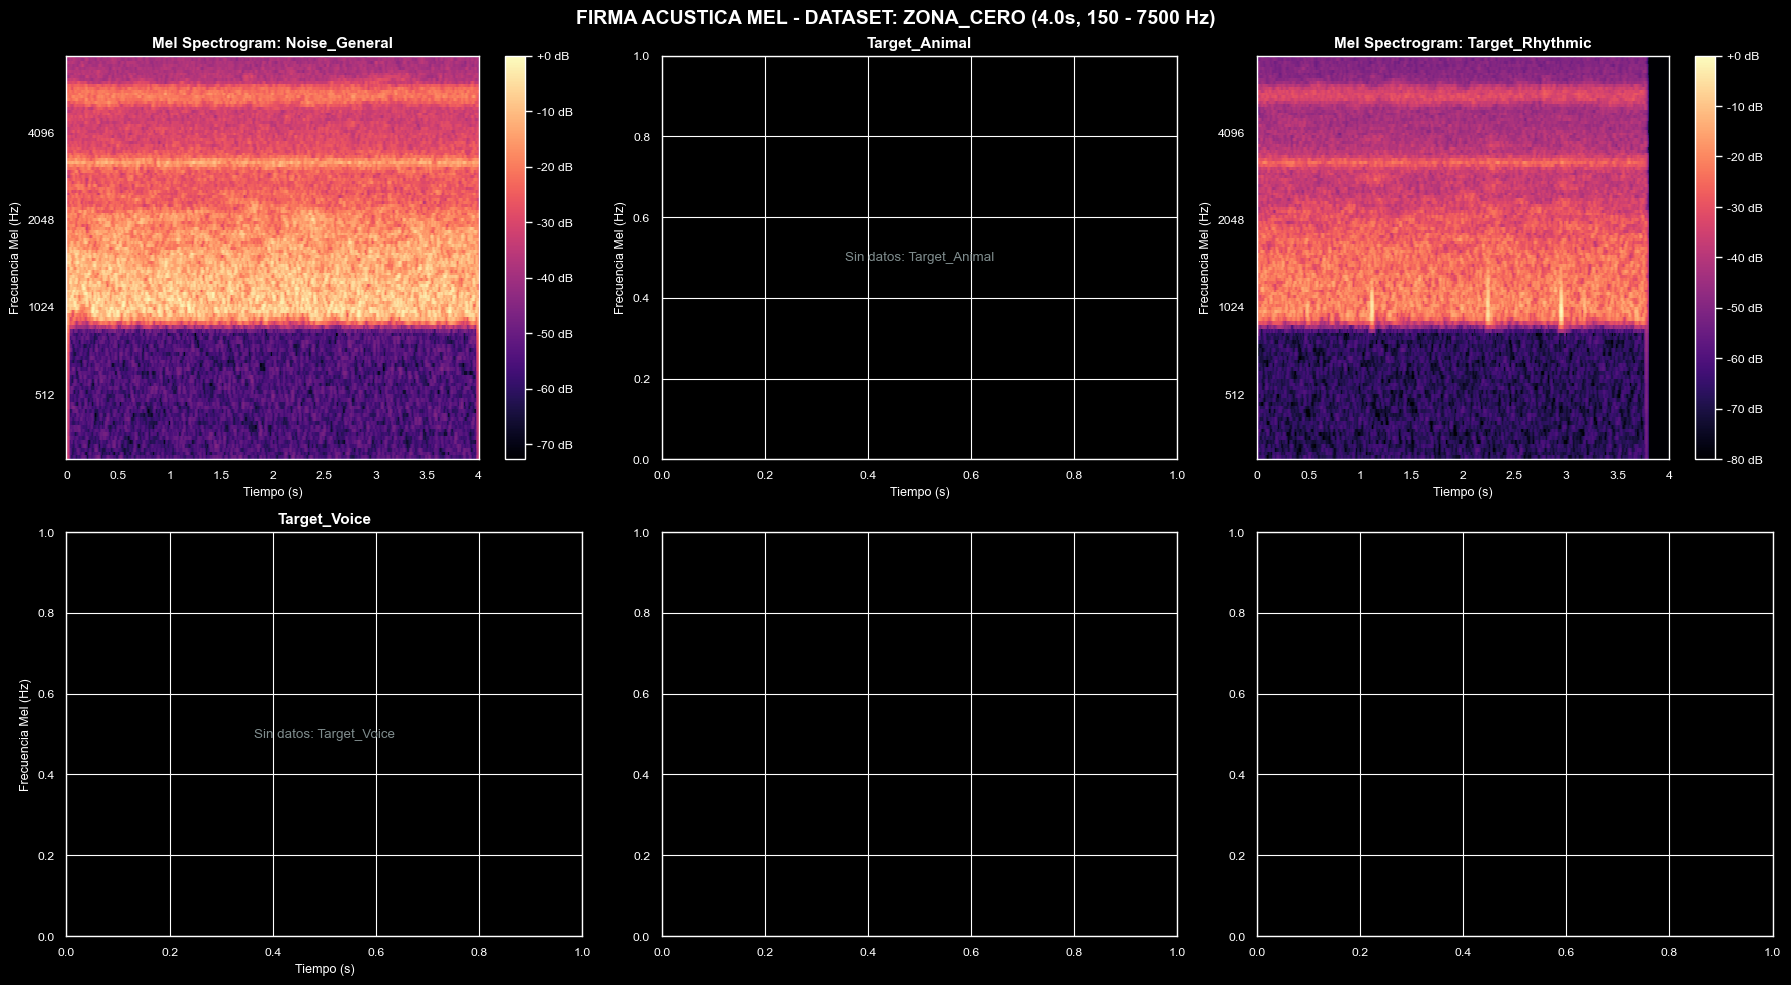

[ÉXITO] EDA de Línea Base completado. Proceda con la Fase 1 de Preprocesamiento.
 INICIANDO FASE 2: PARSEO, EDA Y HUMAN-IN-THE-LOOP

[1/4] Ejecutando Parseo y Unificacion de Datasets...
[ADVERTENCIA] Categoria anomala 'train' detectada en test_EN2002a_1630_1640_knoxx_3_3_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en test_EN2002a_1630_1640_knoxx_3_3_part1.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en test_EN2002a_1630_1640_knoxx_3_3_part2.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en test_EN2002a_1750_1760_pnoxx_4_3_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en test_EN2002a_1750_1760_pnoxx_4_3_part1.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en test_EN2002a_1750_1760_pnoxx_4_3_part2.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en test_EN2002a_1830_1840_dpoxx_3_3_part0.wav. Archivo ignorado.
[ADVERTEN

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



[ADVERTENCIA] Categoria anomala 'train' detectada en 173993-3-0-25_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173993-3-0-51_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173993-3-0-52_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173994-3-0-14_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173994-3-0-3_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173994-3-0-44_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173994-3-0-45_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173995-3-0-27_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 173995-3-0-3_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' detectada en 174026-3-1-1_part0.wav. Archivo ignorado.
[ADVERTENCIA] Categoria anomala 'train' det

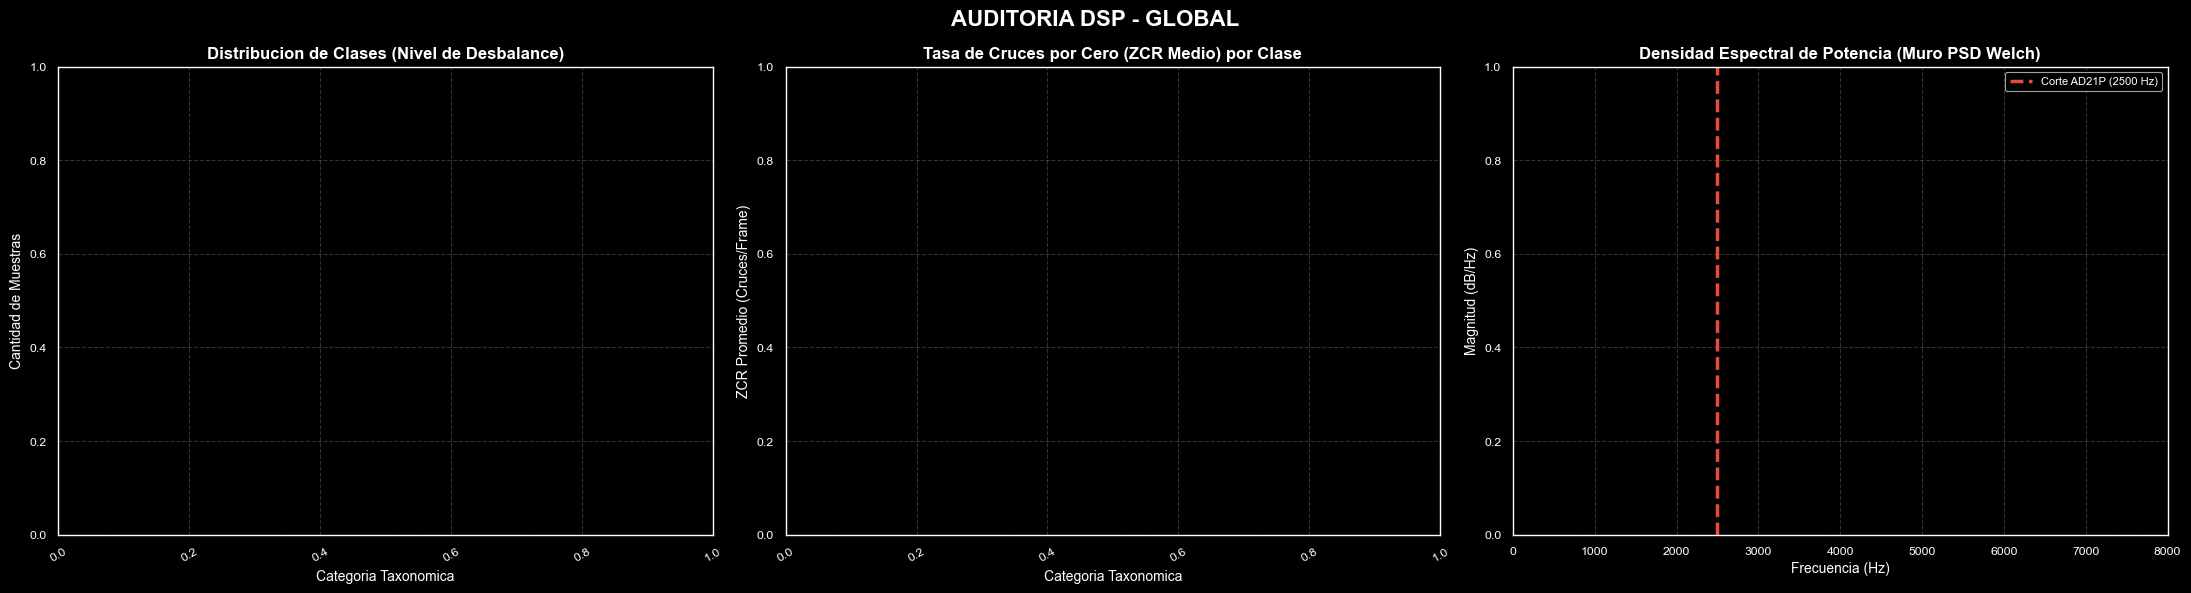

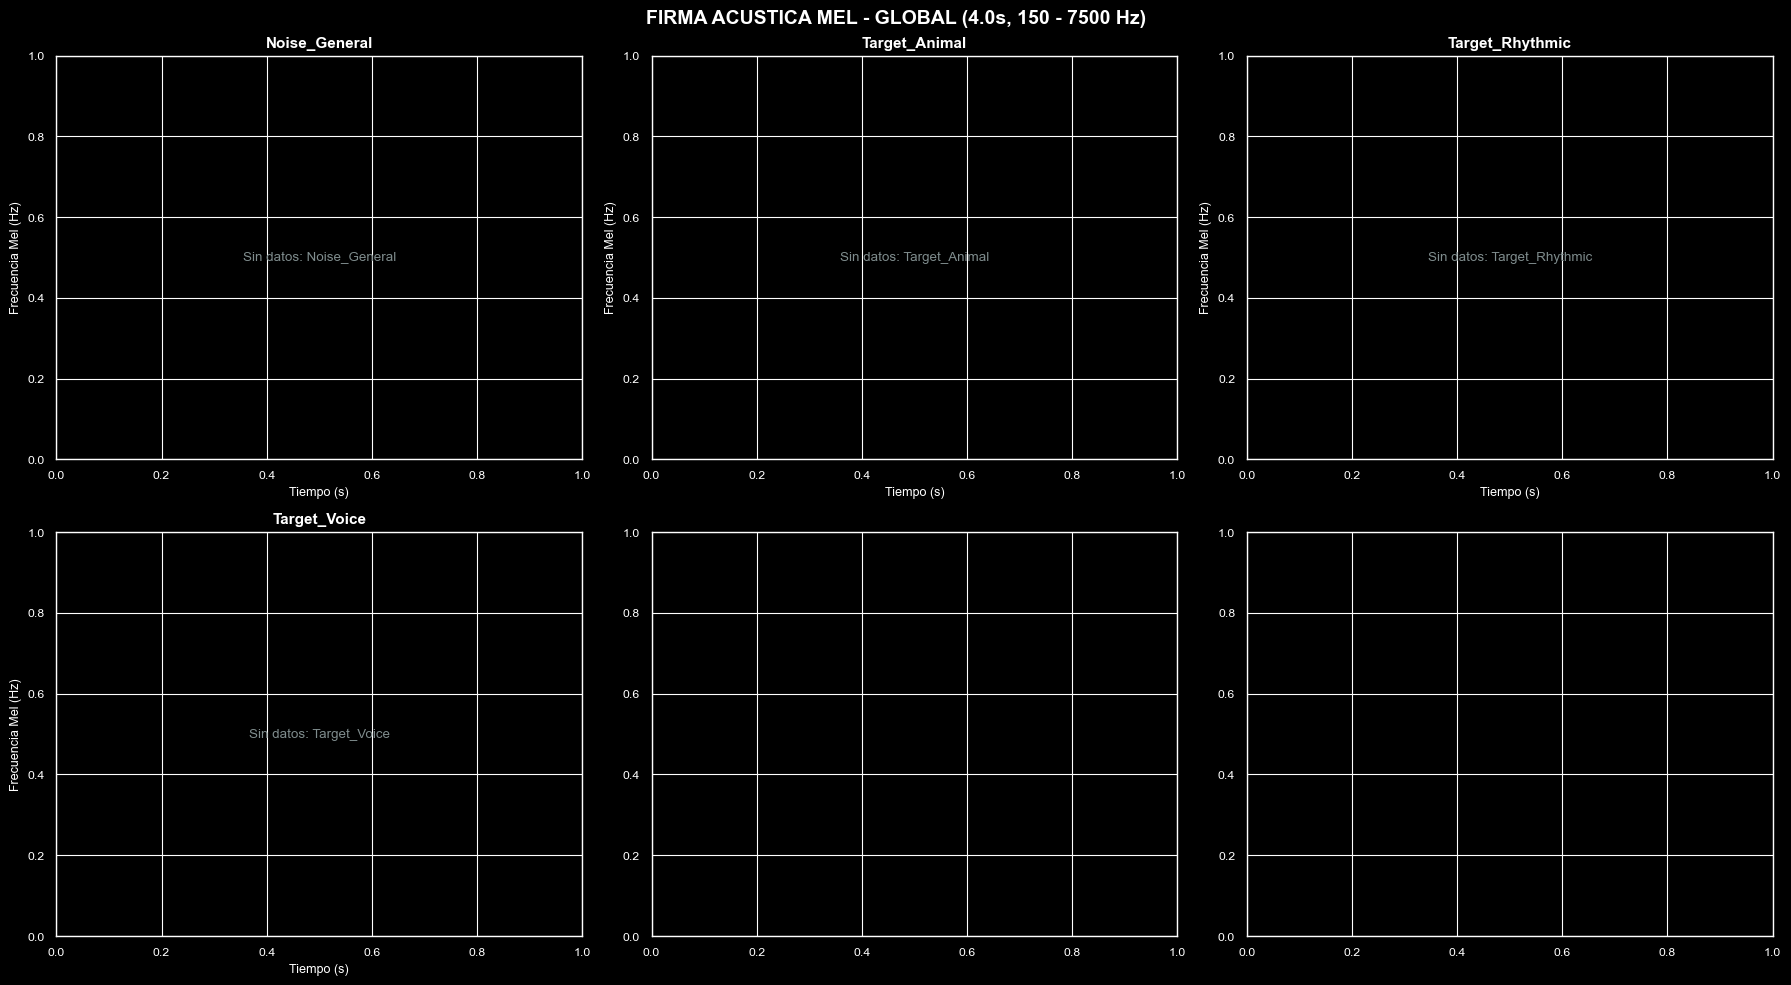


[EDA] Iniciando exploración granular para 0 datasets: []

[4/4] Esperando validacion del Ingeniero (Human-in-the-Loop)...

PAUSA DE SEGURIDAD: CONTROL DE INTEGRIDAD ACOUSTICA (HUMAN-IN-THE-LOOP)
Los dashboards de analisis han sido renderizados y guardados en su espacio de trabajo:
  1. 'dashboard_estadisticas_globales.png' (Balance de datos, ZCR y Filtro PSD)
  2. 'dashboard_malla_espectrogramas.png' (Firmas tiempo-frecuencia de 4s)
--------------------------------------------------------------------------------
Por favor, revise las visualizaciones antes de proceder.


¿El ingeniero valida la integridad fisica y espectral del dataset? (S/N):  n


[ALERTA] Integridad del dataset rechazada por el ingeniero. Abortando operacion.


SystemExit: Entrenamiento abortado por decision del ingeniero de campo.

C:\Users\carlo\anaconda30\envs\usar_gpu_env\lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [34]:
def ejecutar_inicio_fase2(rutas_raiz: List[Path], n_muestras_eda: int = 50) -> None:
    """Ejecuta la primera mitad de la Fase 2 del pipeline.

    Orquesta el parseo de los datasets distribuidos, la extraccion en RAM de los
    descriptores acusticos para el Analisis Exploratorio de Datos (EDA), el
    renderizado del dashboard visual y la validacion 'Human-in-the-Loop'.

    Parameters
    ----------
    rutas_raiz : List[Path]
        Lista de rutas absolutas hacia los directorios raiz que contienen
        los audios preprocesados listos para la ingesta.
    n_muestras_eda : int, optional
        Numero de muestras a extraer aleatoriamente por categoria para el EDA.
        Por defecto es 50.

    Raises
    ------
    SystemExit
        Si el ingeniero rechaza la validacion en el Human-in-the-Loop o
        si ocurre un error critico durante el renderizado.
    """
    print("======================================================")
    print(" INICIANDO FASE 2: PARSEO, EDA Y HUMAN-IN-THE-LOOP")
    print("======================================================\n")

    # 1. Parseo y Unificacion
    print("[1/4] Ejecutando Parseo y Unificacion de Datasets...")
    try:
        df_unificado = parsear_y_unificar_datasets(rutas_raiz)
        print(f"      Total de muestras indexadas en el DataFrame: {len(df_unificado)}")
    except Exception as e:
        print(f"[ERROR CRITICO] Fallo durante el parseo de directorios: {e}")
        sys.exit(1)

    # 2. Extraccion Estadistica (DSP en RAM)
    print(f"\n[2/4] Extrayendo descriptores DSP en paralelo (N={n_muestras_eda} por clase)...")
    try:
        reporte_eda = extraer_muestra_estadistica_eda(
            df_unificado=df_unificado,
            n_muestras_por_clase=n_muestras_eda
        )
    except Exception as e:
        print(f"[ERROR CRITICO] Fallo en la extraccion DSP multinucleo: {e}")
        sys.exit(1)

    # 3. Renderizado del Dashboard Acustico por Dataset y Global
    print("\n[3/4] Renderizando Dashboards por Origen de Datos...")
    try:
        # Primero: Mostrar la vista global de todo el proyecto
        renderizar_dashboard_eda(df_unificado, reporte_eda, titulo_contexto="GLOBAL", tag_fase="PROCESADO")

        # Segundo: Iterar y mostrar la vista granular por cada dataset
        explorar_dashboards_por_dataset(df_unificado, reporte_eda, tag_fase="PROCESADO")
    except Exception as e:
        print(f"[ERROR CRITICO] Fallo al generar las graficas Matplotlib/Seaborn: {e}")
        sys.exit(1)

    # 4. Validacion Human-in-the-Loop
    print("\n[4/4] Esperando validacion del Ingeniero (Human-in-the-Loop)...")
    aprobado = validar_human_in_the_loop()

    if not aprobado:
        print("\n[ABORTADO] El ingeniero ha rechazado la integridad del dataset.")
        print("Accion requerida: Revisar parametros de atenuacion en la Fase 1 o auditar datos base.")
        sys.exit(1)

    print("\n[APROBADO] Integridad del dataset confirmada.")
    print("El sistema esta listo para proceder al bloque: Split 80/20 y DataLoaders.")


if __name__ == "__main__":
    # Definicion de las rutas absolutas del entorno local
    rutas_ingesta = [
        Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_preprocesado"),
        Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\Dataset_Feedback_Humano")
    ]

    rutas_crudas = [
        Path(r"C:\Users\carlo\Documents\detector_vida_acustico\detector_vida_acustico\dataset_original")
    ]
    ejecutar_eda_linea_base(rutas_crudas)
    # Ejecucion del bloque
    ejecutar_inicio_fase2(rutas_raiz=rutas_ingesta)